In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pyexpat import features
from tqdm import tqdm

In [2]:
data = pd.read_pickle('./curves_all_models.pkl')

In [3]:
df_full = pd.read_parquet('../sorted_data.parquet')

In [4]:
times = np.linspace(1654041600, 1661990376, 500)

In [5]:
# from sklearn import metrics
#
# def curve_mean(values):
#     return np.mean(values)
#
# def curve_std(values):
#     return np.std(values)
#
# def curve_range(values):
#     return np.max(values) - np.min(values)
#
# def curve_auc(times, values):
#     return metrics.auc(times, values)
#     # output = 0.0
#     # for i, t in enumerate(times[:-1]):
#     #     output = output + (values[i] + values[i+1])*(times[i+1]-times[i])/2
#
# def curve_get_slope(times, values):
#     return np.polyfit(times, values, 1)[1]
#     # t = np.asarray(times)
#     # s0 = np.asarray(values)
#     # dt = t - t.mean()
#     # return np.dot(dt, s0 - s0.mean()) / np.dot(dt, dt)
#
#
# def curve_roughness_1(values):
#     s = np.asarray(values)
#     return np.abs(np.diff(s)).mean()
#
#
# def curve_roughness_2(values):
#     np.asarray(values)
#     return np.abs(np.diff(values, n=2)).mean()
#
#
# def curve_score_prob_corr(score, prob):
#     return np.corrcoef(score, prob)[0, 1]
#


In [6]:
# import copy
#
# times = np.linspace(1654041600, 1661990376, 500)
#
# features = {}
#
# for model, x in tqdm(data.items()):
#     df = copy.deepcopy(x)
#
#     df_features = df.join(df.apply(
#     lambda r: pd.Series({
#         "score_mean": curve_mean(r.score),
#         "score_std": curve_std(r.score),
#         "score_range": curve_range(r.score),
#         "score_auc": curve_auc(times, r.score),
#         "score_slope": curve_get_slope(times, r.score),
#         "score_r1": curve_roughness_1(r.score),
#         "score_r2": curve_roughness_2(r.score),
#
#         "prob_mean": curve_mean(r.prob),
#         "prob_std": curve_std(r.prob),
#         "prob_range": curve_range(r.prob),
#         "prob_auc": curve_auc(times, r.prob),
#         "prob_slope": curve_get_slope(times, r.prob),
#         "prob_r1": curve_roughness_1(r.prob),
#         "prob_r2": curve_roughness_2(r.prob),
#
#         "score_prob_corr": curve_score_prob_corr(r.score, r.prob),
#     }), axis=1)).drop(columns=['score', 'prob'])
#
#     features[model] = df_features
#


In [7]:
# def get_user_extremes(group):
#     # Get the row indices for the maximum and minimum slopes in this group
#     idx_max = group['prob_slope'].idxmax()
#     idx_min = group['prob_slope'].idxmin()
#
#     # Extract the actual values
#     max_slope = group.loc[idx_max, 'prob_slope']
#     min_slope = group.loc[idx_min, 'prob_slope']
#     item_max = group.loc[idx_max, 'item']
#     item_min = group.loc[idx_min, 'item']
#
#     # Calculate the algebraic difference
#     diff = max_slope - min_slope
#
#     return pd.Series({
#         'diff': diff,
#         'item_max': item_max,
#         'slope_max': max_slope,
#         'item_min': item_min,
#         'slope_min': min_slope
#     })

In [8]:
# user_differences = features['extended_doublemlp_loss'].groupby('user').apply(get_user_extremes).reset_index()
#
# # 3. Find the single user with the absolute largest difference overall
# target_row = user_differences.loc[user_differences['diff'].idxmax()]

In [9]:
# df = features['extended_doublemlp_loss']

In [10]:
# target_user = target_row['user']
# item_max = target_row['item_max']
# item_min = target_row['item_min']
# max_diff = target_row['diff']
#
# print(f"User with the largest slope difference: {target_user}")
# print(f"Item 1 (Max Slope): {item_max} (Slope: {target_row['slope_max']:.4f})")
# print(f"Item 2 (Min Slope): {item_min} (Slope: {target_row['slope_min']:.4f})")
# print(f"Difference in Steepness: {max_diff:.4f}")
#
# # ---------------------------------------------------------
# # 4. Optional: Visualize that specific user's items
# # ---------------------------------------------------------
# user_data = df[df['user'] == target_user].sort_values(by='prob_slope')
#
# plt.figure(figsize=(10, 6))
#
# # Highlight the two extreme items
# colors = ['green' if item == item_max else 'red' if item == item_min else 'lightgray' for item in user_data['item']]
# bars = plt.bar(user_data['item'], user_data['prob_slope'], color=colors, edgecolor='black')
#
# plt.axhline(0, color='black', linewidth=1, linestyle='--')
# plt.title(f"Largest Slope Difference Found for User: {target_user}\n(Gap: {max_diff:.2f})", fontsize=14)
# plt.xlabel("Items")
# plt.ylabel("Calculated Slope")
#
# # Add the values onto the bars
# for bar in bars:
#     yval = bar.get_height()
#     offset = 0.05 * df['prob_slope'].abs().max()
#     y_pos = yval + offset if yval > 0 else yval - offset
#     plt.text(bar.get_x() + bar.get_width()/2, y_pos, f'{yval:.2f}',
#              ha='center', va='bottom' if yval > 0 else 'top')
#
# plt.tight_layout()
# plt.show()

In [11]:
import math
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# =========================
# Helpers
# =========================

def sanitize_name(name: str) -> str:
    """Make model names safe for column / feature names."""
    s = re.sub(r"\W+", "_", str(name)).strip("_")
    if not s:
        s = "model"
    if s[0].isdigit():
        s = f"m_{s}"
    return s


def to_1d_float_array(x):
    """Convert a list-like cell to a 1D float array."""
    arr = np.asarray(x, dtype=float).reshape(-1)
    return arr


def trapz_auc(y, x):
    """Trapezoidal AUC; works for negative values too."""
    return float(np.trapezoid(y, x))


def linear_slope(values, t, prefix=""):
    """Slope of least-squares linear fit."""
    return  np.polyfit(t, values, 1)[1]
    # x_mean = x.mean()
    # y_mean = y.mean()
    # denom = np.sum((x - x_mean) ** 2)
    # if np.isclose(denom, 0):
    #     return np.nan
    # return float(np.sum((x - x_mean) * (y - y_mean)) / denom)


def total_variation(y):
    """Mean absolute first difference."""
    if len(y) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(y))))


def second_diff_roughness(y):
    """Mean absolute second difference."""
    if len(y) < 3:
        return 0.0
    return float(np.mean(np.abs(np.diff(y, n=2))))


def safe_corr(a, b):
    """Correlation guarded against constant vectors."""
    if len(a) != len(b) or len(a) < 2:
        return np.nan
    if np.allclose(a, a[0]) or np.allclose(b, b[0]):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def l2_distance(a, b):
    """Root mean squared distance."""
    return float(np.sqrt(np.mean((a - b) ** 2)))


def l1_distance(a, b):
    """Mean absolute distance."""
    return float(np.mean(np.abs(a - b)))


def curve_summary(y, x, prefix=""):
    """Basic per-curve summaries."""
    return {
        f"{prefix}mean": float(np.mean(y)),
        f"{prefix}std": float(np.std(y)),
        f"{prefix}min": float(np.min(y)),
        f"{prefix}max": float(np.max(y)),
        f"{prefix}range": float(np.max(y) - np.min(y)),
        f"{prefix}auc": trapz_auc(y, x),
        f"{prefix}slope": linear_slope(y, x),
        f"{prefix}tv": total_variation(y),
        f"{prefix}rough2": second_diff_roughness(y),
    }


def summarize_values(values, prefix):
    """Aggregate a list of scalar values."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return {
            f"{prefix}mean": np.nan,
            f"{prefix}std": np.nan,
            f"{prefix}min": np.nan,
            f"{prefix}max": np.nan,
            f"{prefix}range": np.nan,
        }
    return {
        f"{prefix}mean": float(np.nanmean(values)),
        f"{prefix}std": float(np.nanstd(values)),
        f"{prefix}min": float(np.nanmin(values)),
        f"{prefix}max": float(np.nanmax(values)),
        f"{prefix}range": float(np.nanmax(values) - np.nanmin(values)),
    }


# =========================
# Data preparation
# =========================

def prepare_model_dataframe(df, times, user_col="user", item_col="item", score_col="score", prob_col="prob"):
    """Clean a single model dataframe and keep only valid rows."""
    n_times = len(times)

    out = df[[user_col, item_col, score_col, prob_col]].copy()
    out = out.rename(columns={
        user_col: "user",
        item_col: "item",
        score_col: "score",
        prob_col: "prob",
    })

    out["score"] = out["score"].map(to_1d_float_array)
    out["prob"] = out["prob"].map(to_1d_float_array)

    score_len = out["score"].map(len)
    prob_len = out["prob"].map(len)

    valid = (score_len == n_times) & (prob_len == n_times)
    out = out.loc[valid].copy()

    out = out.drop_duplicates(subset=["user", "item"], keep="first").reset_index(drop=True)
    return out


def build_aligned_table(
    model_dfs,
    base_model,
    times,
    user_col="user",
    item_col="item",
    score_col="score",
    prob_col="prob",
    require_all_extensions=False,
):
    """
    Build one wide table with:
      user, item, score__<safe_model>, prob__<safe_model>
    Keeps rows where base exists and at least one extension exists,
    unless require_all_extensions=True.
    """
    if base_model not in model_dfs:
        raise ValueError(f"base_model '{base_model}' not found in model_dfs")

    model_name_map = {name: sanitize_name(name) for name in model_dfs.keys()}
    safe_to_original = {safe: original for original, safe in model_name_map.items()}

    cleaned = {}
    for name, df in model_dfs.items():
        clean_df = prepare_model_dataframe(
            df=df,
            times=times,
            user_col=user_col,
            item_col=item_col,
            score_col=score_col,
            prob_col=prob_col,
        )
        safe = model_name_map[name]
        clean_df = clean_df.rename(columns={
            "score": f"score__{safe}",
            "prob": f"prob__{safe}",
        })
        cleaned[name] = clean_df

    base_safe = model_name_map[base_model]
    aligned = cleaned[base_model].copy()

    extension_models = [m for m in model_dfs.keys() if m != base_model]
    extension_safes = [model_name_map[m] for m in extension_models]

    for ext_name in extension_models:
        ext_df = cleaned[ext_name]
        aligned = aligned.merge(ext_df, on=["user", "item"], how="left")

    ext_score_cols = [f"score__{safe}" for safe in extension_safes]
    present_counts = aligned[ext_score_cols].notna().sum(axis=1)

    if require_all_extensions:
        aligned = aligned.loc[present_counts == len(extension_safes)].copy()
    else:
        aligned = aligned.loc[present_counts >= 1].copy()

    aligned = aligned.reset_index(drop=True)

    return {
        "aligned_df": aligned,
        "model_name_map": model_name_map,
        "safe_to_original": safe_to_original,
        "base_safe": base_safe,
        "extension_safes": extension_safes,
    }


# =========================
# Feature extraction
# =========================

def extract_features_from_aligned_row(row, times, base_safe, extension_safes):
    """Extract base-vs-extension features for a single (user, item)."""
    x = times
    feats = {
        "user": row["user"],
        "item": row["item"],
    }

    base_score = row[f"score__{base_safe}"]
    base_prob = row[f"prob__{base_safe}"]

    base_score = to_1d_float_array(base_score)
    base_prob = to_1d_float_array(base_prob)

    feats.update(curve_summary(base_score, x, prefix="base_score_"))
    feats.update(curve_summary(base_prob, x, prefix="base_prob_"))

    # base_gap = base_score - base_prob
    # feats["base_sp_gap_mean"] = float(np.mean(base_gap))
    # feats["base_sp_gap_abs_mean"] = float(np.mean(np.abs(base_gap)))
    feats["base_sp_corr"] = safe_corr(base_score, base_prob)
    # feats["base_sp_auc_gap"] = trapz_auc(base_score, x) - trapz_auc(base_prob, x)

    ext_score_l2 = []
    ext_prob_l2 = []
    ext_score_l1 = []
    ext_prob_l1 = []

    ext_score_auc_delta = []
    ext_prob_auc_delta = []
    ext_score_mean_delta = []
    ext_prob_mean_delta = []
    ext_score_slope_delta = []
    ext_prob_slope_delta = []
    ext_score_tv_delta = []
    ext_prob_tv_delta = []
    ext_score_rough2_delta = []
    ext_prob_rough2_delta = []
    ext_gap_abs_delta = []

    ext_score_corr_to_base = []
    ext_prob_corr_to_base = []

    score_auc_above_base = []
    prob_auc_above_base = []

    available_exts = []

    base_score_stats = curve_summary(base_score, x)
    base_prob_stats = curve_summary(base_prob, x)
    # base_gap_abs = float(np.mean(np.abs(base_gap)))

    for ext_safe in extension_safes:
        score_key = f"score__{ext_safe}"
        prob_key = f"prob__{ext_safe}"

        if score_key not in row or prob_key not in row:
            continue
        if not isinstance(row[score_key], np.ndarray) or not isinstance(row[prob_key], np.ndarray):
            continue

        ext_score = to_1d_float_array(row[score_key])
        ext_prob = to_1d_float_array(row[prob_key])

        if len(ext_score) != len(base_score) or len(ext_prob) != len(base_prob):
            continue

        available_exts.append(ext_safe)

        ext_score_stats = curve_summary(ext_score, x, prefix=f"{ext_safe}_score_")
        ext_prob_stats = curve_summary(ext_prob, x, prefix=f"{ext_safe}_prob_")
        feats.update(ext_score_stats)
        feats.update(ext_prob_stats)

        # ext_gap = ext_score - ext_prob
        # feats[f"{ext_safe}_sp_gap_mean"] = float(np.mean(ext_gap))
        # feats[f"{ext_safe}_sp_gap_abs_mean"] = float(np.mean(np.abs(ext_gap)))
        feats[f"{ext_safe}_sp_corr"] = safe_corr(ext_score, ext_prob)
        # feats[f"{ext_safe}_sp_auc_gap"] = trapz_auc(ext_score, x) - trapz_auc(ext_prob, x)

        # feats[f"{ext_safe}_vs_base_score_l2"] = l2_distance(ext_score, base_score)
        # feats[f"{ext_safe}_vs_base_score_l1"] = l1_distance(ext_score, base_score)
        # feats[f"{ext_safe}_vs_base_prob_l2"] = l2_distance(ext_prob, base_prob)
        # feats[f"{ext_safe}_vs_base_prob_l1"] = l1_distance(ext_prob, base_prob)

        feats[f"{ext_safe}_vs_base_score_corr"] = safe_corr(ext_score, base_score)
        feats[f"{ext_safe}_vs_base_prob_corr"] = safe_corr(ext_prob, base_prob)

        feats[f"{ext_safe}_vs_base_score_auc_delta"] = ext_score_stats[f"{ext_safe}_score_auc"] - base_score_stats["auc"]
        feats[f"{ext_safe}_vs_base_prob_auc_delta"] = ext_prob_stats[f"{ext_safe}_prob_auc"] - base_prob_stats["auc"]

        feats[f"{ext_safe}_vs_base_score_mean_delta"] = ext_score_stats[f"{ext_safe}_score_mean"] - base_score_stats["mean"]
        feats[f"{ext_safe}_vs_base_prob_mean_delta"] = ext_prob_stats[f"{ext_safe}_prob_mean"] - base_prob_stats["mean"]

        feats[f"{ext_safe}_vs_base_score_slope_delta"] = ext_score_stats[f"{ext_safe}_score_slope"] - base_score_stats["slope"]
        feats[f"{ext_safe}_vs_base_prob_slope_delta"] = ext_prob_stats[f"{ext_safe}_prob_slope"] - base_prob_stats["slope"]

        feats[f"{ext_safe}_vs_base_score_tv_delta"] = ext_score_stats[f"{ext_safe}_score_tv"] - base_score_stats["tv"]
        feats[f"{ext_safe}_vs_base_prob_tv_delta"] = ext_prob_stats[f"{ext_safe}_prob_tv"] - base_prob_stats["tv"]

        feats[f"{ext_safe}_vs_base_score_rough2_delta"] = ext_score_stats[f"{ext_safe}_score_rough2"] - base_score_stats["rough2"]
        feats[f"{ext_safe}_vs_base_prob_rough2_delta"] = ext_prob_stats[f"{ext_safe}_prob_rough2"] - base_prob_stats["rough2"]

        # ext_gap_abs = float(np.mean(np.abs(ext_gap)))
        # feats[f"{ext_safe}_vs_base_sp_gap_abs_delta"] = ext_gap_abs - base_gap_abs

        score_diff = ext_score - base_score
        prob_diff = ext_prob - base_prob

        feats[f"{ext_safe}_vs_base_score_diff_mean"] = float(np.mean(score_diff))
        feats[f"{ext_safe}_vs_base_prob_diff_mean"] = float(np.mean(prob_diff))
        feats[f"{ext_safe}_vs_base_score_frac_above"] = float(np.mean(score_diff > 0))
        feats[f"{ext_safe}_vs_base_prob_frac_above"] = float(np.mean(prob_diff > 0))

        # ext_score_l2.append(feats[f"{ext_safe}_vs_base_score_l2"])
        # ext_prob_l2.append(feats[f"{ext_safe}_vs_base_prob_l2"])
        # ext_score_l1.append(feats[f"{ext_safe}_vs_base_score_l1"])
        # ext_prob_l1.append(feats[f"{ext_safe}_vs_base_prob_l1"])

        ext_score_auc_delta.append(feats[f"{ext_safe}_vs_base_score_auc_delta"])
        ext_prob_auc_delta.append(feats[f"{ext_safe}_vs_base_prob_auc_delta"])
        ext_score_mean_delta.append(feats[f"{ext_safe}_vs_base_score_mean_delta"])
        ext_prob_mean_delta.append(feats[f"{ext_safe}_vs_base_prob_mean_delta"])
        ext_score_slope_delta.append(feats[f"{ext_safe}_vs_base_score_slope_delta"])
        ext_prob_slope_delta.append(feats[f"{ext_safe}_vs_base_prob_slope_delta"])
        ext_score_tv_delta.append(feats[f"{ext_safe}_vs_base_score_tv_delta"])
        ext_prob_tv_delta.append(feats[f"{ext_safe}_vs_base_prob_tv_delta"])
        ext_score_rough2_delta.append(feats[f"{ext_safe}_vs_base_score_rough2_delta"])
        ext_prob_rough2_delta.append(feats[f"{ext_safe}_vs_base_prob_rough2_delta"])
        # ext_gap_abs_delta.append(feats[f"{ext_safe}_vs_base_sp_gap_abs_delta"])

        ext_score_corr_to_base.append(feats[f"{ext_safe}_vs_base_score_corr"])
        ext_prob_corr_to_base.append(feats[f"{ext_safe}_vs_base_prob_corr"])

        score_auc_above_base.append(float(feats[f"{ext_safe}_vs_base_score_auc_delta"] > 0))
        prob_auc_above_base.append(float(feats[f"{ext_safe}_vs_base_prob_auc_delta"] > 0))

    feats["n_available_extensions"] = len(available_exts)

    # feats.update(summarize_values(ext_score_l2, "ext_vs_base_score_l2_"))
    # feats.update(summarize_values(ext_prob_l2, "ext_vs_base_prob_l2_"))
    # feats.update(summarize_values(ext_score_l1, "ext_vs_base_score_l1_"))
    # feats.update(summarize_values(ext_prob_l1, "ext_vs_base_prob_l1_"))

    feats.update(summarize_values(ext_score_auc_delta, "ext_vs_base_score_auc_delta_"))
    feats.update(summarize_values(ext_prob_auc_delta, "ext_vs_base_prob_auc_delta_"))
    feats.update(summarize_values(ext_score_mean_delta, "ext_vs_base_score_mean_delta_"))
    feats.update(summarize_values(ext_prob_mean_delta, "ext_vs_base_prob_mean_delta_"))
    feats.update(summarize_values(ext_score_slope_delta, "ext_vs_base_score_slope_delta_"))
    feats.update(summarize_values(ext_prob_slope_delta, "ext_vs_base_prob_slope_delta_"))
    feats.update(summarize_values(ext_score_tv_delta, "ext_vs_base_score_tv_delta_"))
    feats.update(summarize_values(ext_prob_tv_delta, "ext_vs_base_prob_tv_delta_"))
    feats.update(summarize_values(ext_score_rough2_delta, "ext_vs_base_score_rough2_delta_"))
    feats.update(summarize_values(ext_prob_rough2_delta, "ext_vs_base_prob_rough2_delta_"))
    feats.update(summarize_values(ext_gap_abs_delta, "ext_vs_base_sp_gap_abs_delta_"))

    feats.update(summarize_values(ext_score_corr_to_base, "ext_vs_base_score_corr_"))
    feats.update(summarize_values(ext_prob_corr_to_base, "ext_vs_base_prob_corr_"))

    feats["n_ext_score_auc_above_base"] = float(np.sum(score_auc_above_base)) if len(score_auc_above_base) else np.nan
    feats["n_ext_prob_auc_above_base"] = float(np.sum(prob_auc_above_base)) if len(prob_auc_above_base) else np.nan
    feats["frac_ext_score_auc_above_base"] = float(np.mean(score_auc_above_base)) if len(score_auc_above_base) else np.nan
    feats["frac_ext_prob_auc_above_base"] = float(np.mean(prob_auc_above_base)) if len(prob_auc_above_base) else np.nan

    if len(available_exts) >= 2:
        # pair_score_l2 = []
        # pair_prob_l2 = []
        pair_score_corr = []
        pair_prob_corr = []

        for a, b in combinations(available_exts, 2):
            sa = to_1d_float_array(row[f"score__{a}"])
            sb = to_1d_float_array(row[f"score__{b}"])
            pa = to_1d_float_array(row[f"prob__{a}"])
            pb = to_1d_float_array(row[f"prob__{b}"])

            # pair_score_l2.append(l2_distance(sa, sb))
            # pair_prob_l2.append(l2_distance(pa, pb))
            pair_score_corr.append(safe_corr(sa, sb))
            pair_prob_corr.append(safe_corr(pa, pb))

        # feats.update(summarize_values(pair_score_l2, "ext_pairwise_score_l2_"))
        # feats.update(summarize_values(pair_prob_l2, "ext_pairwise_prob_l2_"))
        feats.update(summarize_values(pair_score_corr, "ext_pairwise_score_corr_"))
        feats.update(summarize_values(pair_prob_corr, "ext_pairwise_prob_corr_"))

    return feats


def extract_feature_table(aligned_df, times, base_safe, extension_safes):
    """Extract all features for the aligned table."""
    rows = []
    records = aligned_df.to_dict(orient="records")
    for row in records:
        rows.append(extract_features_from_aligned_row(row, times, base_safe, extension_safes))
    return pd.DataFrame(rows)


# =========================
# Feature selection / clustering
# =========================

def build_default_feature_columns(feature_df, extension_safes):
    """Feature set centered on base vs extension differences."""
    cols = [
        "base_score_auc",
        "base_prob_auc",
        "base_score_slope",
        "base_prob_slope",
        "base_score_tv",
        "base_prob_tv",
        # "base_sp_gap_abs_mean",
        # "ext_vs_base_score_l2_mean",
        # "ext_vs_base_score_l2_std",
        # "ext_vs_base_prob_l2_mean",
        # "ext_vs_base_prob_l2_std",
        "ext_vs_base_score_auc_delta_mean",
        "ext_vs_base_score_auc_delta_std",
        "ext_vs_base_prob_auc_delta_mean",
        "ext_vs_base_prob_auc_delta_std",
        "ext_vs_base_score_slope_delta_mean",
        "ext_vs_base_score_slope_delta_std",
        "ext_vs_base_prob_slope_delta_mean",
        "ext_vs_base_prob_slope_delta_std",
        "ext_vs_base_score_tv_delta_mean",
        "ext_vs_base_prob_tv_delta_mean",
        "ext_vs_base_score_rough2_delta_mean",
        "ext_vs_base_prob_rough2_delta_mean",
        # "ext_vs_base_sp_gap_abs_delta_mean",
        # "ext_vs_base_sp_gap_abs_delta_std",
        "ext_vs_base_score_corr_mean",
        "ext_vs_base_prob_corr_mean",
        "frac_ext_score_auc_above_base",
        "frac_ext_prob_auc_above_base",
        "n_available_extensions",
        # "ext_pairwise_score_l2_mean",
        # "ext_pairwise_prob_l2_mean",
        "ext_pairwise_score_corr_mean",
        "ext_pairwise_prob_corr_mean",
    ]

    for ext_safe in extension_safes:
        cols.extend([
            # f"{ext_safe}_vs_base_score_l2",
            # f"{ext_safe}_vs_base_prob_l2",
            f"{ext_safe}_vs_base_score_corr",
            f"{ext_safe}_vs_base_prob_corr",
            f"{ext_safe}_vs_base_score_auc_delta",
            f"{ext_safe}_vs_base_prob_auc_delta",
            f"{ext_safe}_vs_base_score_mean_delta",
            f"{ext_safe}_vs_base_prob_mean_delta",
            f"{ext_safe}_vs_base_score_slope_delta",
            f"{ext_safe}_vs_base_prob_slope_delta",
            f"{ext_safe}_vs_base_score_tv_delta",
            f"{ext_safe}_vs_base_prob_tv_delta",
            f"{ext_safe}_vs_base_score_rough2_delta",
            f"{ext_safe}_vs_base_prob_rough2_delta",
            # f"{ext_safe}_vs_base_sp_gap_abs_delta",
            f"{ext_safe}_vs_base_score_frac_above",
            f"{ext_safe}_vs_base_prob_frac_above",
        ])

    cols = [c for c in cols if c in feature_df.columns]
    return cols


def prepare_clustering_matrix(feature_df, feature_cols):
    """Impute, remove constant columns, standardize."""
    X = feature_df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()

    non_all_nan_cols = [c for c in X.columns if not X[c].isna().all()]
    X = X[non_all_nan_cols]

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    col_var = np.nanvar(X_imputed, axis=0)
    keep_mask = col_var > 0
    kept_cols = [c for c, keep in zip(non_all_nan_cols, keep_mask) if keep]
    X_imputed = X_imputed[:, keep_mask]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    return {
        "X_scaled": X_scaled,
        "kept_feature_cols": kept_cols,
        "imputer": imputer,
        "scaler": scaler,
    }


def choose_k_by_silhouette(X_scaled, k_min=3, k_max=8, random_state=42, max_sample=10000):
    """Choose k quickly using silhouette on a sample if needed."""
    n = X_scaled.shape[0]
    if n < 3:
        return 1

    k_min = max(2, k_min)
    k_max = min(k_max, n - 1)
    if k_min > k_max:
        return max(2, min(3, n - 1))

    if n > max_sample:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n, size=max_sample, replace=False)
        X_eval = X_scaled[idx]
    else:
        X_eval = X_scaled

    best_k = k_min
    best_score = -np.inf

    for k in range(k_min, k_max + 1):
        if X_eval.shape[0] <= k:
            continue
        model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(X_eval)
        if len(np.unique(labels)) < 2:
            continue
        score = silhouette_score(X_eval, labels)
        if score > best_score:
            best_score = score
            best_k = k

    return best_k


def cluster_features(X_scaled, n_clusters=None, random_state=42):
    """Run KMeans or MiniBatchKMeans depending on dataset size."""
    n = X_scaled.shape[0]

    if n_clusters is None:
        n_clusters = choose_k_by_silhouette(X_scaled, k_min=3, k_max=8, random_state=random_state)

    if n > 30000:
        model = MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            batch_size=4096,
            n_init=20,
        )
    else:
        model = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=20,
        )

    labels = model.fit_predict(X_scaled)
    return model, labels, n_clusters


# =========================
# Visualisations
# =========================

def plot_cluster_sizes(feature_df, cluster_col="cluster", figsize=(8, 4)):
    """Bar chart of cluster sizes."""
    counts = feature_df[cluster_col].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title("Cluster sizes")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    plt.tight_layout()
    return fig


def plot_pca_scatter(X_scaled, labels, figsize=(7, 6)):
    """2D PCA view of clustered points with legend."""
    if X_scaled.shape[1] < 2:
        pca_coords = np.column_stack([X_scaled[:, 0], np.zeros(X_scaled.shape[0])])
        explained = [1.0, 0.0]
    else:
        pca = PCA(n_components=2, random_state=42)
        pca_coords = pca.fit_transform(X_scaled)
        explained = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(
        pca_coords[:, 0],
        pca_coords[:, 1],
        c=labels,
        s=12,
        alpha=0.8,
    )

    ax.set_title("Clusters in PCA space")
    ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}%)")

    unique_labels = np.unique(labels)
    handles, _ = scatter.legend_elements()
    ax.legend(
        handles,
        [f"Cluster {label}" for label in unique_labels],
        title="Clusters",
        loc="best",
    )

    plt.tight_layout()
    return fig


def plot_cluster_feature_heatmap(feature_df, feature_cols, cluster_col="cluster", top_n=25, figsize=(12, 7)):
    """Heatmap of cluster means, z-scored by overall feature stats."""
    cluster_means = feature_df.groupby(cluster_col)[feature_cols].mean(numeric_only=True)

    separation = cluster_means.var(axis=0).sort_values(ascending=False)
    top_features = separation.head(min(top_n, len(separation))).index.tolist()

    overall_mean = feature_df[top_features].mean(numeric_only=True)
    overall_std = feature_df[top_features].std(numeric_only=True).replace(0, np.nan)

    z = (cluster_means[top_features] - overall_mean) / overall_std
    z = z.fillna(0.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(z.values, aspect="auto")
    ax.set_title("Cluster feature heatmap (z-scored cluster means)")
    ax.set_yticks(np.arange(len(z.index)))
    ax.set_yticklabels([str(c) for c in z.index])
    ax.set_xticks(np.arange(len(top_features)))
    ax.set_xticklabels(top_features, rotation=90)
    ax.set_xlabel("Features")
    ax.set_ylabel("Cluster")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    return fig


def _mean_curve(series):
    """Mean curve from a Series of arrays."""
    if len(series) == 0:
        return None
    stacked = np.vstack(series.to_numpy())
    return stacked.mean(axis=0)


def _mean_delta_curve(ext_series, base_series):
    """Mean delta curve from paired Series of arrays."""
    if len(ext_series) == 0:
        return None
    ext_stack = np.vstack(ext_series.to_numpy())
    base_stack = np.vstack(base_series.to_numpy())
    return (ext_stack - base_stack).mean(axis=0)


def plot_cluster_curves_grid(
    aligned_df,
    times,
    base_safe,
    extension_safes,
    safe_to_original,
    cluster_col="cluster",
    curve_type="prob",
    delta=False,
    max_clusters=None,
    ncols=2,
    figsize_per_ax=(6, 4),
):
    """
    Plot mean curves per cluster.
    If delta=True, plot extension minus base curves.
    """
    clusters = sorted(aligned_df[cluster_col].dropna().unique().tolist())
    if max_clusters is not None:
        clusters = clusters[:max_clusters]

    n_clusters = len(clusters)
    nrows = math.ceil(n_clusters / ncols)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_ax[0] * ncols, figsize_per_ax[1] * nrows),
        squeeze=False,
    )

    base_col = f"{curve_type}__{base_safe}"

    for ax, cluster_id in zip(axes.flat, clusters):
        cluster_df = aligned_df.loc[aligned_df[cluster_col] == cluster_id]

        if not delta:
            base_mean = _mean_curve(cluster_df[base_col])
            if base_mean is not None:
                ax.plot(times, base_mean, label=safe_to_original[base_safe], linewidth=2.5)

            for ext_safe in extension_safes:
                ext_col = f"{curve_type}__{ext_safe}"
                ext_mask = cluster_df[ext_col].notna()
                if ext_mask.any():
                    ext_mean = _mean_curve(cluster_df.loc[ext_mask, ext_col])
                    ax.plot(times, ext_mean, label=safe_to_original[ext_safe])

            ax.set_title(f"Cluster {cluster_id} | mean {curve_type} curves | n={len(cluster_df)}")
            ax.set_xlabel("time")
            ax.set_ylabel(curve_type)
            ax.legend(fontsize=8)

        else:
            for ext_safe in extension_safes:
                ext_col = f"{curve_type}__{ext_safe}"
                ext_mask = cluster_df[ext_col].notna()
                if ext_mask.any():
                    delta_mean = _mean_delta_curve(
                        cluster_df.loc[ext_mask, ext_col],
                        cluster_df.loc[ext_mask, base_col],
                    )
                    ax.plot(times, delta_mean, label=f"{safe_to_original[ext_safe]} - {safe_to_original[base_safe]}")

            ax.axhline(0.0, linestyle="--", linewidth=1)
            ax.set_title(f"Cluster {cluster_id} | mean {curve_type} delta vs base | n={len(cluster_df)}")
            ax.set_xlabel("time")
            ax.set_ylabel(f"{curve_type} delta")
            ax.legend(fontsize=8)

    for ax in axes.flat[n_clusters:]:
        ax.axis("off")

    plt.tight_layout()
    return fig


def plot_prob_auc_improvement_by_cluster(
    feature_df,
    extension_safes,
    safe_to_original,
    cluster_col="cluster",
    figsize=(10, 5),
):
    """Grouped bars: fraction of rows where extension prob AUC > base, by cluster."""
    clusters = sorted(feature_df[cluster_col].dropna().unique().tolist())
    ext_cols = [f"{ext_safe}_vs_base_prob_auc_delta" for ext_safe in extension_safes if f"{ext_safe}_vs_base_prob_auc_delta" in feature_df.columns]

    if len(ext_cols) == 0:
        return None

    data = []
    labels = []
    for ext_col in ext_cols:
        ext_safe = ext_col.replace("_vs_base_prob_auc_delta", "")
        frac = feature_df.groupby(cluster_col)[ext_col].apply(lambda s: np.mean(s > 0))
        frac = frac.reindex(clusters)
        data.append(frac.values)
        labels.append(safe_to_original[ext_safe])

    data = np.asarray(data)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(clusters))
    width = 0.8 / max(1, len(labels))

    for i, label in enumerate(labels):
        ax.bar(x + i * width - 0.4 + width / 2, data[i], width=width, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in clusters])
    ax.set_ylim(0, 1)
    ax.set_title("Fraction of cases where extension prob AUC > base, by cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Fraction > base")
    ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


def plot_ext_distance_boxplots(feature_df, extension_safes, safe_to_original, figsize=(12, 5)):
    """Boxplots of per-extension distance-to-base features."""
    score_cols = [f"{ext}_vs_base_score_l2" for ext in extension_safes if f"{ext}_vs_base_score_l2" in feature_df.columns]
    prob_cols = [f"{ext}_vs_base_prob_l2" for ext in extension_safes if f"{ext}_vs_base_prob_l2" in feature_df.columns]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    if score_cols:
        score_data = [feature_df[c].dropna().values for c in score_cols]
        score_labels = [safe_to_original[c.replace("_vs_base_score_l2", "")] for c in score_cols]
        axes[0].boxplot(score_data, labels=score_labels, vert=True)
        axes[0].set_title("Score L2 distance to base")
        axes[0].tick_params(axis="x", rotation=45)

    if prob_cols:
        prob_data = [feature_df[c].dropna().values for c in prob_cols]
        prob_labels = [safe_to_original[c.replace("_vs_base_prob_l2", "")] for c in prob_cols]
        axes[1].boxplot(prob_data, labels=prob_labels, vert=True)
        axes[1].set_title("Prob L2 distance to base")
        axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    return fig


# =========================
# Main pipeline
# =========================

def run_model_difference_analysis(
    model_dfs,
    base_model,
    times,
    n_clusters=None,
    require_all_extensions=False,
    user_col="user",
    item_col="item",
    score_col="score",
    prob_col="prob",
    random_state=42,
    max_clusters_in_curve_plots=8,
    heatmap_top_n=25,
):
    """
    Full pipeline:
      1) align data
      2) extract base-vs-extension features
      3) cluster
      4) create figures
    """
    times = to_1d_float_array(times)

    aligned_info = build_aligned_table(
        model_dfs=model_dfs,
        base_model=base_model,
        times=times,
        user_col=user_col,
        item_col=item_col,
        score_col=score_col,
        prob_col=prob_col,
        require_all_extensions=require_all_extensions,
    )

    aligned_df = aligned_info["aligned_df"]
    model_name_map = aligned_info["model_name_map"]
    safe_to_original = aligned_info["safe_to_original"]
    base_safe = aligned_info["base_safe"]
    extension_safes = aligned_info["extension_safes"]

    feature_df = extract_feature_table(
        aligned_df=aligned_df,
        times=times,
        base_safe=base_safe,
        extension_safes=extension_safes,
    )

    feature_cols = build_default_feature_columns(feature_df, extension_safes)

    matrix_info = prepare_clustering_matrix(feature_df, feature_cols)
    X_scaled = matrix_info["X_scaled"]
    kept_feature_cols = matrix_info["kept_feature_cols"]

    cluster_model, labels, chosen_k = cluster_features(
        X_scaled=X_scaled,
        n_clusters=n_clusters,
        random_state=random_state,
    )

    feature_df = feature_df.copy()
    feature_df["cluster"] = labels

    aligned_df = aligned_df.copy()
    aligned_df["cluster"] = labels

    figures = {}
    figures["cluster_sizes"] = plot_cluster_sizes(feature_df, cluster_col="cluster")
    figures["pca_scatter"] = plot_pca_scatter(X_scaled, labels)
    figures["feature_heatmap"] = plot_cluster_feature_heatmap(
        feature_df=feature_df,
        feature_cols=kept_feature_cols,
        cluster_col="cluster",
        top_n=heatmap_top_n,
    )
    figures["prob_curves"] = plot_cluster_curves_grid(
        aligned_df=aligned_df,
        times=times,
        base_safe=base_safe,
        extension_safes=extension_safes,
        safe_to_original=safe_to_original,
        cluster_col="cluster",
        curve_type="prob",
        delta=False,
        max_clusters=max_clusters_in_curve_plots,
    )
    figures["score_curves"] = plot_cluster_curves_grid(
        aligned_df=aligned_df,
        times=times,
        base_safe=base_safe,
        extension_safes=extension_safes,
        safe_to_original=safe_to_original,
        cluster_col="cluster",
        curve_type="score",
        delta=False,
        max_clusters=max_clusters_in_curve_plots,
    )
    figures["prob_delta_curves"] = plot_cluster_curves_grid(
        aligned_df=aligned_df,
        times=times,
        base_safe=base_safe,
        extension_safes=extension_safes,
        safe_to_original=safe_to_original,
        cluster_col="cluster",
        curve_type="prob",
        delta=True,
        max_clusters=max_clusters_in_curve_plots,
    )
    figures["score_delta_curves"] = plot_cluster_curves_grid(
        aligned_df=aligned_df,
        times=times,
        base_safe=base_safe,
        extension_safes=extension_safes,
        safe_to_original=safe_to_original,
        cluster_col="cluster",
        curve_type="score",
        delta=True,
        max_clusters=max_clusters_in_curve_plots,
    )
    figures["prob_auc_improvement"] = plot_prob_auc_improvement_by_cluster(
        feature_df=feature_df,
        extension_safes=extension_safes,
        safe_to_original=safe_to_original,
        cluster_col="cluster",
    )
    figures["ext_distance_boxplots"] = plot_ext_distance_boxplots(
        feature_df=feature_df,
        extension_safes=extension_safes,
        safe_to_original=safe_to_original,
    )

    cluster_summary = feature_df.groupby("cluster")[kept_feature_cols].mean(numeric_only=True)

    return {
        "aligned_df": aligned_df,
        "feature_df": feature_df,
        "feature_cols_used": kept_feature_cols,
        "cluster_model": cluster_model,
        "n_clusters": chosen_k,
        "figures": figures,
        "cluster_summary": cluster_summary,
        "model_name_map": model_name_map,
        "safe_to_original": safe_to_original,
        "base_safe": base_safe,
        "extension_safes": extension_safes,
    }


# =========================
# Optional utility
# =========================

def save_figures(figures, out_dir):
    """Save all non-None figures."""
    import os
    os.makedirs(out_dir, exist_ok=True)

    for name, fig in figures.items():
        if fig is not None:
            fig.savefig(os.path.join(out_dir, f"{name}.png"), dpi=180, bbox_inches="tight")


# =========================
# Example usage
# =========================

# model_dfs = {
#     "base_model": df_base,
#     "extension_a": df_ext_a,
#     "extension_b": df_ext_b,
#     "extension_c": df_ext_c,
# }
#
# results = run_model_difference_analysis(
#     model_dfs=model_dfs,
#     base_model="base_model",
#     times=times,
#     n_clusters=None,                  # set an int to force k, or None to choose automatically
#     require_all_extensions=False,     # True if you only want rows present for every extension
#     user_col="user",
#     item_col="item",
#     score_col="score",
#     prob_col="prob",
#     random_state=42,
#     max_clusters_in_curve_plots=8,
#     heatmap_top_n=25,
# )
#
# feature_df = results["feature_df"]
# aligned_df = results["aligned_df"]
# cluster_summary = results["cluster_summary"]
#
# print("Chosen k:", results["n_clusters"])
# print(feature_df.head())
# print(cluster_summary.head())
#
# plt.show()
# # save_figures(results["figures"], "model_diff_outputs")

In [12]:
# =========================
# Behavioral description layer
# =========================

BEHAVIOR_METRIC_META = {
    "score_mean": {
        "category": "level",
        "higher": "keeps scores at a higher average level",
        "lower": "keeps scores at a lower average level",
    },
    "prob_mean": {
        "category": "level",
        "higher": "keeps probabilities at a higher average level",
        "lower": "keeps probabilities at a lower average level",
    },
    "score_auc": {
        "category": "level",
        "higher": "sustains more score mass over time",
        "lower": "sustains less score mass over time",
    },
    "prob_auc": {
        "category": "level",
        "higher": "sustains more probability mass over time",
        "lower": "sustains less probability mass over time",
    },
    "score_slope": {
        "category": "trend",
        "higher": "shows a stronger upward score trend",
        "lower": "shows a flatter or more downward score trend",
    },
    "prob_slope": {
        "category": "trend",
        "higher": "shows a stronger upward probability trend",
        "lower": "shows a flatter or more downward probability trend",
    },
    "score_std": {
        "category": "variability",
        "higher": "has more dispersed score values",
        "lower": "has tighter score dispersion",
    },
    "prob_std": {
        "category": "variability",
        "higher": "has more dispersed probability values",
        "lower": "has tighter probability dispersion",
    },
    "score_tv": {
        "category": "volatility",
        "higher": "changes more from one score timestep to the next",
        "lower": "moves more smoothly in score from step to step",
    },
    "prob_tv": {
        "category": "volatility",
        "higher": "changes more from one probability timestep to the next",
        "lower": "moves more smoothly in probability from step to step",
    },
    "score_rough2": {
        "category": "curvature",
        "higher": "has more score jaggedness and sharper bends",
        "lower": "has smoother second-order score dynamics",
    },
    "prob_rough2": {
        "category": "curvature",
        "higher": "has more probability jaggedness and sharper bends",
        "lower": "has smoother second-order probability dynamics",
    },
    # "sp_gap_abs_mean": {
    #     "category": "alignment",
    #     "higher": "keeps score and probability farther apart",
    #     "lower": "keeps score and probability more tightly aligned",
    # },
    "sp_corr": {
        "category": "alignment",
        "higher": "shows tighter score-probability co-movement",
        "lower": "shows weaker score-probability co-movement",
    },
    # "sp_auc_gap": {
    #     "category": "alignment",
    #     "higher": "maintains a larger integrated score-probability gap",
    #     "lower": "maintains a smaller integrated score-probability gap",
    # },
}

DEFAULT_BEHAVIOR_METRICS = list(BEHAVIOR_METRIC_META.keys())


def _resolve_safe_model_name(name, model_name_map):
    """
    Accept either original model name or sanitized safe name.
    Returns safe name.
    """
    if name in model_name_map:
        return model_name_map[name]
    if name in model_name_map.values():
        return name
    raise KeyError(f"Unknown model name: {name}")


def build_model_metric_table(aligned_df, times, model_name_map):
    """
    Long-format table:
      user, item, cluster, model_safe, model, <behavior metrics...>
    """
    times = to_1d_float_array(times)
    model_safes = list(model_name_map.values())
    safe_to_original = {safe: orig for orig, safe in model_name_map.items()}

    rows = []
    records = aligned_df.to_dict(orient="records")

    for row in records:
        cluster = row.get("cluster", np.nan)

        for model_safe in model_safes:
            score_key = f"score__{model_safe}"
            prob_key = f"prob__{model_safe}"

            if score_key not in row or prob_key not in row:
                continue

            score_val = row[score_key]
            prob_val = row[prob_key]

            if not isinstance(score_val, np.ndarray) or not isinstance(prob_val, np.ndarray):
                continue

            score = to_1d_float_array(score_val)
            prob = to_1d_float_array(prob_val)

            if len(score) != len(times) or len(prob) != len(times):
                continue

            rec = {
                "user": row["user"],
                "item": row["item"],
                "cluster": cluster,
                "model_safe": model_safe,
                "model": safe_to_original[model_safe],
            }
            rec.update(curve_summary(score, times, prefix="score_"))
            rec.update(curve_summary(prob, times, prefix="prob_"))

            # gap = score - prob
            # rec["sp_gap_mean"] = float(np.mean(gap))
            # rec["sp_gap_abs_mean"] = float(np.mean(np.abs(gap)))
            rec["sp_corr"] = safe_corr(score, prob)
            # rec["sp_auc_gap"] = trapz_auc(score, times) - trapz_auc(prob, times)

            rows.append(rec)

    return pd.DataFrame(rows)


def _safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float(np.std(x))


def _paired_fraction_positive(diff):
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    if diff.size == 0:
        return np.nan
    return float(np.mean(diff > 0))


def _global_metric_scales(metric_df, metrics):
    scales = {}
    for m in metrics:
        vals = pd.to_numeric(metric_df[m], errors="coerce").to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            scales[m] = np.nan
        else:
            s = np.std(vals)
            scales[m] = float(s) if s > 0 else np.nan
    return scales


def compare_model_behaviors(
    metric_df,
    left_model,
    right_model,
    model_name_map,
    metrics=None,
    cluster=None,
    min_pairs=25,
):
    """
    Paired comparison of left_model vs right_model on shared (user, item) rows.
    Positive delta means left_model > right_model on that metric.
    """
    if metrics is None:
        metrics = DEFAULT_BEHAVIOR_METRICS

    left_safe = _resolve_safe_model_name(left_model, model_name_map)
    right_safe = _resolve_safe_model_name(right_model, model_name_map)

    sub = metric_df.loc[metric_df["model_safe"].isin([left_safe, right_safe])].copy()
    if cluster is not None:
        sub = sub.loc[sub["cluster"] == cluster].copy()

    left = sub.loc[sub["model_safe"] == left_safe, ["user", "item"] + metrics].copy()
    right = sub.loc[sub["model_safe"] == right_safe, ["user", "item"] + metrics].copy()

    left = left.set_index(["user", "item"])
    right = right.set_index(["user", "item"])

    joined = left.join(right, how="inner", lsuffix="__left", rsuffix="__right")
    if joined.empty:
        return pd.DataFrame()

    global_scales = _global_metric_scales(sub, metrics)

    rows = []
    for metric in metrics:
        a = pd.to_numeric(joined[f"{metric}__left"], errors="coerce").to_numpy(dtype=float)
        b = pd.to_numeric(joined[f"{metric}__right"], errors="coerce").to_numpy(dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        if a.size < min_pairs:
            continue

        diff = a - b
        delta_mean = float(np.mean(diff))
        abs_delta_mean = float(np.mean(np.abs(diff)))
        left_mean = float(np.mean(a))
        right_mean = float(np.mean(b))
        diff_std = _safe_std(diff)
        frac_pos = _paired_fraction_positive(diff)
        frac_neg = _paired_fraction_positive(-diff)
        consistency = float(max(frac_pos, frac_neg)) if np.isfinite(frac_pos) and np.isfinite(frac_neg) else np.nan

        global_std = global_scales.get(metric, np.nan)
        standardized_delta = delta_mean / global_std if np.isfinite(global_std) and global_std > 0 else np.nan

        # Salience = standardized magnitude * consistency bonus
        if np.isfinite(standardized_delta) and np.isfinite(consistency):
            salience = abs(standardized_delta) * (0.5 + 0.5 * consistency)
        elif np.isfinite(standardized_delta):
            salience = abs(standardized_delta)
        else:
            salience = np.nan

        meta = BEHAVIOR_METRIC_META.get(metric, {})
        rows.append({
            "metric": metric,
            "category": meta.get("category", "other"),
            "left_model": left_model,
            "right_model": right_model,
            "cluster": cluster,
            "n_pairs": int(a.size),
            "left_mean": left_mean,
            "right_mean": right_mean,
            "delta_mean": delta_mean,
            "abs_delta_mean": abs_delta_mean,
            "diff_std": diff_std,
            "frac_left_gt_right": frac_pos,
            "frac_left_lt_right": frac_neg,
            "consistency": consistency,
            "global_std": global_std,
            "standardized_delta": standardized_delta,
            "salience": salience,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["salience", "abs_delta_mean"], ascending=[False, False]).reset_index(drop=True)
    return out


def _format_signed(x, digits=3):
    if not np.isfinite(x):
        return "nan"
    return f"{x:+.{digits}f}"


def _pick_representative_metrics(comparison_df, top_n=5, min_salience=0.20):
    """
    Pick one strong metric per category first, then fill remaining slots.
    """
    if comparison_df.empty:
        return comparison_df

    work = comparison_df.copy()
    work = work.loc[work["salience"].fillna(-np.inf) >= min_salience].copy()
    if work.empty:
        work = comparison_df.head(top_n).copy()

    selected_idx = []
    seen_categories = set()

    for idx, row in work.iterrows():
        cat = row["category"]
        if cat not in seen_categories:
            selected_idx.append(idx)
            seen_categories.add(cat)
        if len(selected_idx) >= top_n:
            break

    if len(selected_idx) < top_n:
        for idx in work.index:
            if idx not in selected_idx:
                selected_idx.append(idx)
            if len(selected_idx) >= top_n:
                break

    return work.loc[selected_idx].copy()


def _trait_summary_from_comparison(comparison_df):
    """
    Turn metric deltas into coarse model traits.
    """
    if comparison_df.empty:
        return []

    std = comparison_df.set_index("metric")["standardized_delta"].to_dict()

    def _avg(keys, signs=None):
        vals = []
        if signs is None:
            signs = [1.0] * len(keys)
        for k, s in zip(keys, signs):
            v = std.get(k, np.nan)
            if np.isfinite(v):
                vals.append(s * v)
        if not vals:
            return np.nan
        return float(np.mean(vals))

    assertiveness = _avg(["score_auc", "prob_auc", "score_mean", "prob_mean"])
    momentum = _avg(["score_slope", "prob_slope"])
    volatility = _avg(["score_tv", "prob_tv", "score_std", "prob_std"])
    curvature = _avg(["score_rough2", "prob_rough2"])
    alignment = _avg(["sp_corr"], signs=[1.0])

    traits = []

    if np.isfinite(assertiveness) and abs(assertiveness) >= 0.25:
        traits.append("more assertive overall" if assertiveness > 0 else "more conservative overall")

    if np.isfinite(momentum) and abs(momentum) >= 0.25:
        traits.append("more upward-trending" if momentum > 0 else "flatter or more downward-trending")

    if np.isfinite(volatility) and abs(volatility) >= 0.25:
        traits.append("more volatile" if volatility > 0 else "smoother step-to-step")

    if np.isfinite(curvature) and abs(curvature) >= 0.25:
        traits.append("more jagged in second-order shape" if curvature > 0 else "more curved-smooth")

    if np.isfinite(alignment) and abs(alignment) >= 0.25:
        traits.append("more tightly score-prob aligned" if alignment > 0 else "more score-prob decoupled")

    return traits


def summarize_behavior_comparison(
    comparison_df,
    top_n=5,
    min_salience=0.20,
):
    """
    Natural-language summary for one model-vs-model comparison.
    """
    if comparison_df.empty:
        return "No stable paired comparison could be computed for this model pair."

    left_model = comparison_df["left_model"].iloc[0]
    right_model = comparison_df["right_model"].iloc[0]
    cluster = comparison_df["cluster"].iloc[0]
    n_pairs = int(comparison_df["n_pairs"].max())

    top = _pick_representative_metrics(comparison_df, top_n=top_n, min_salience=min_salience)

    clauses = []
    for _, row in top.iterrows():
        meta = BEHAVIOR_METRIC_META.get(row["metric"], {})
        if row["delta_mean"] >= 0:
            action = meta.get("higher", f"has higher {row['metric']}")
        else:
            action = meta.get("lower", f"has lower {row['metric']}")

        clause = (
            f"{action} "
            f"({row['metric']} Δ={_format_signed(row['delta_mean'])}, "
            f"stdΔ={_format_signed(row['standardized_delta'])}, "
            f"{row['frac_left_gt_right'] * 100:.0f}% of shared cases above)"
        )
        clauses.append(clause)

    traits = _trait_summary_from_comparison(comparison_df)

    if cluster is None or (isinstance(cluster, float) and np.isnan(cluster)):
        intro = f"On {n_pairs:,} shared user-item pairs, {left_model} differs from {right_model} mainly in the following ways: "
    else:
        intro = f"In cluster {int(cluster)} on {n_pairs:,} shared user-item pairs, {left_model} differs from {right_model} mainly in the following ways: "

    body = "; ".join(clauses) + "."
    if traits:
        outro = " Overall, this makes it look " + ", ".join(traits[:-1] + [traits[-1]]) + f" relative to {right_model}."
    else:
        outro = ""

    return intro + body + outro


def build_generation_comparisons(generation_plan):
    """
    generation_plan example:
    {
        "baseline": "original",
        "gen1": ["extended_double", "extendedBase"],
        "gen2": ["extended_doublemlp_loss"],
    }

    Returns ordered comparison pairs:
      gen1 vs baseline
      gen2 vs baseline
      gen2 vs each gen1
    """
    baseline = generation_plan["baseline"]
    gen1 = list(generation_plan.get("gen1", []))
    gen2 = list(generation_plan.get("gen2", []))

    pairs = []

    for m in gen1:
        pairs.append((m, baseline))

    for m in gen2:
        pairs.append((m, baseline))

    for m2 in gen2:
        for m1 in gen1:
            pairs.append((m2, m1))

    return pairs


def generate_behavior_reports(
    results,
    times,
    generation_plan,
    metrics=None,
    top_n=5,
    min_salience=0.20,
    min_pairs=25,
    per_cluster=True,
    min_cluster_pairs=20,
):
    """
    Main entry point.

    Returns:
      {
        "metric_df": ...,
        "comparison_tables": {(left,right): df, ...},
        "overall_text": {(left,right): text, ...},
        "cluster_text": {(left,right): {cluster_id: text, ...}, ...},
      }
    """
    if metrics is None:
        metrics = DEFAULT_BEHAVIOR_METRICS

    aligned_df = results["aligned_df"]
    model_name_map = results["model_name_map"]

    metric_df = build_model_metric_table(
        aligned_df=aligned_df,
        times=times,
        model_name_map=model_name_map,
    )

    pairs = build_generation_comparisons(generation_plan)

    comparison_tables = {}
    overall_text = {}
    cluster_text = {}

    cluster_ids = []
    if per_cluster and "cluster" in metric_df.columns:
        cluster_ids = sorted([c for c in metric_df["cluster"].dropna().unique().tolist()])

    for left_model, right_model in pairs:
        comp = compare_model_behaviors(
            metric_df=metric_df,
            left_model=left_model,
            right_model=right_model,
            model_name_map=model_name_map,
            metrics=metrics,
            cluster=None,
            min_pairs=min_pairs,
        )
        comparison_tables[(left_model, right_model)] = comp
        overall_text[(left_model, right_model)] = summarize_behavior_comparison(
            comp,
            top_n=top_n,
            min_salience=min_salience,
        )

        cluster_text[(left_model, right_model)] = {}
        if per_cluster:
            for cluster_id in cluster_ids:
                comp_cluster = compare_model_behaviors(
                    metric_df=metric_df,
                    left_model=left_model,
                    right_model=right_model,
                    model_name_map=model_name_map,
                    metrics=metrics,
                    cluster=cluster_id,
                    min_pairs=min_cluster_pairs,
                )
                if not comp_cluster.empty:
                    cluster_text[(left_model, right_model)][cluster_id] = summarize_behavior_comparison(
                        comp_cluster,
                        top_n=min(3, top_n),
                        min_salience=min_salience,
                    )

    return {
        "metric_df": metric_df,
        "comparison_tables": comparison_tables,
        "overall_text": overall_text,
        "cluster_text": cluster_text,
    }


def print_behavior_reports(report):
    """
    Pretty printer for generated behavior text.
    """
    for pair, text in report["overall_text"].items():
        left_model, right_model = pair
        print("=" * 100)
        print(f"{left_model} vs {right_model}")
        print("-" * 100)
        print(text)

        cluster_map = report["cluster_text"].get(pair, {})
        if cluster_map:
            print("\nCluster-specific behavior:")
            for cluster_id, cluster_text in cluster_map.items():
                print(f"  - Cluster {cluster_id}: {cluster_text}")
        print()

In [13]:
data.keys()

dict_keys(['extended_double', 'extended_doublemlp', 'extended_doublemlp_loss', 'extendedBase', 'original'])

In [14]:
for key, item in data.items():
    item['model'] = key

In [15]:
data['original']

,user,item,score,prob,model
0,1.0,208.0,"[-3.0778417587280273, -3.0778417587280273, -3....","[0.0012907710624858737, 0.0012907710624858737,...",original
1,1.0,380.0,"[-6.9756178855896, -6.9756178855896, -6.975617...","[2.6185840397374704e-05, 2.6185840397374704e-0...",original
2,2.0,594.0,"[-5.504396915435791, -5.504396915435791, -5.50...","[0.00019638522644527256, 0.0001963852264452725...",original
3,2.0,673.0,"[-3.4202611446380615, -3.4202611446380615, -3....","[0.0015784741844981909, 0.0015784741844981909,...",original
4,3.0,71.0,"[-4.270654678344727, -4.270654678344727, -4.27...","[0.00039710846613161266, 0.0003971084661316126...",original
...,...,...,...,...,...
26413,13207.0,1055.0,"[-5.34928035736084, -5.34928035736084, -5.3492...","[0.0003548462700564414, 0.0003548462700564414,...",original
26414,13208.0,1311.0,"[-2.351283550262451, -2.351283550262451, -2.35...","[0.002085225423797965, 0.002085225423797965, 0...",original
26415,13208.0,1640.0,"[-3.248830795288086, -3.248830795288086, -3.24...","[0.0008498713141307235, 0.0008498713141307235,...",original
26416,13209.0,453.0,"[-4.462602615356445, -4.462602615356445, -4.46...","[0.00045869266614317894, 0.0004586926661431789...",original


C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2749133639.py:112: RuntimeWarning: Mean of empty slice
  f"{prefix}mean": float(np.nanmean(values)),
Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2749133639.py:114: RuntimeWarning: All-NaN slice encountered
  f"{prefix}min": float(np.nanmin(values)),
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2749133639.py:115: RuntimeWarning: All-NaN slice encountered
  f"{prefix}max": float(np.nanmax(values)),
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2749133639.py:116: RuntimeWarning: All-NaN slice encountered
  f"{prefix}range": float(np.nanmax(values) - np.nanmin(values)),


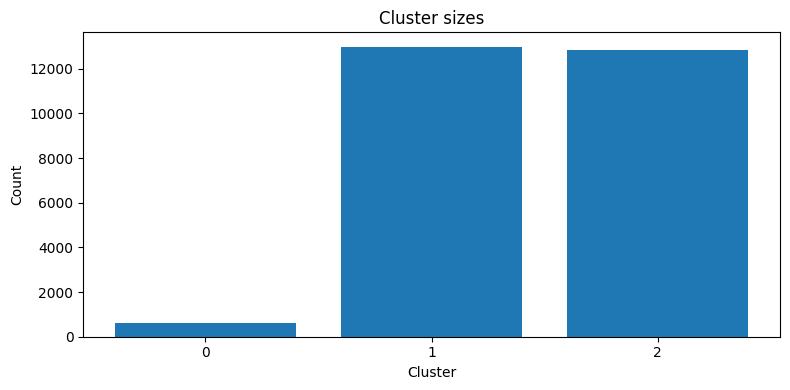

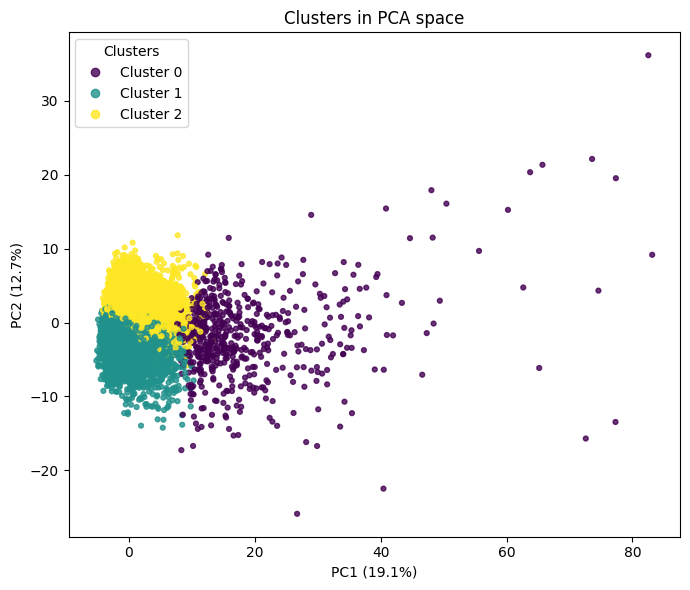

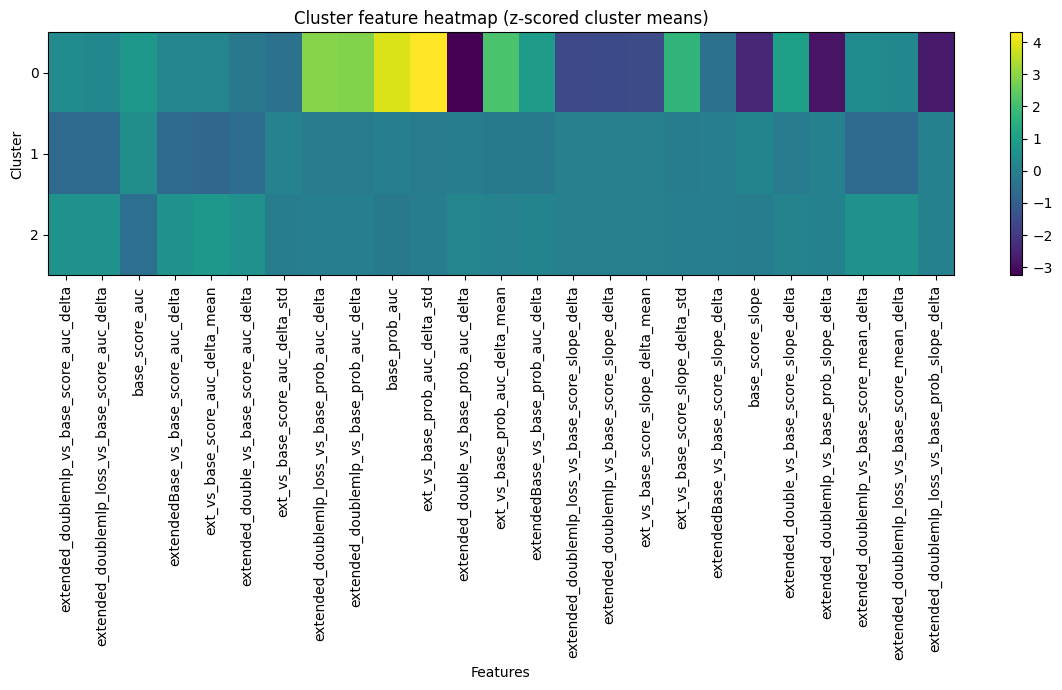

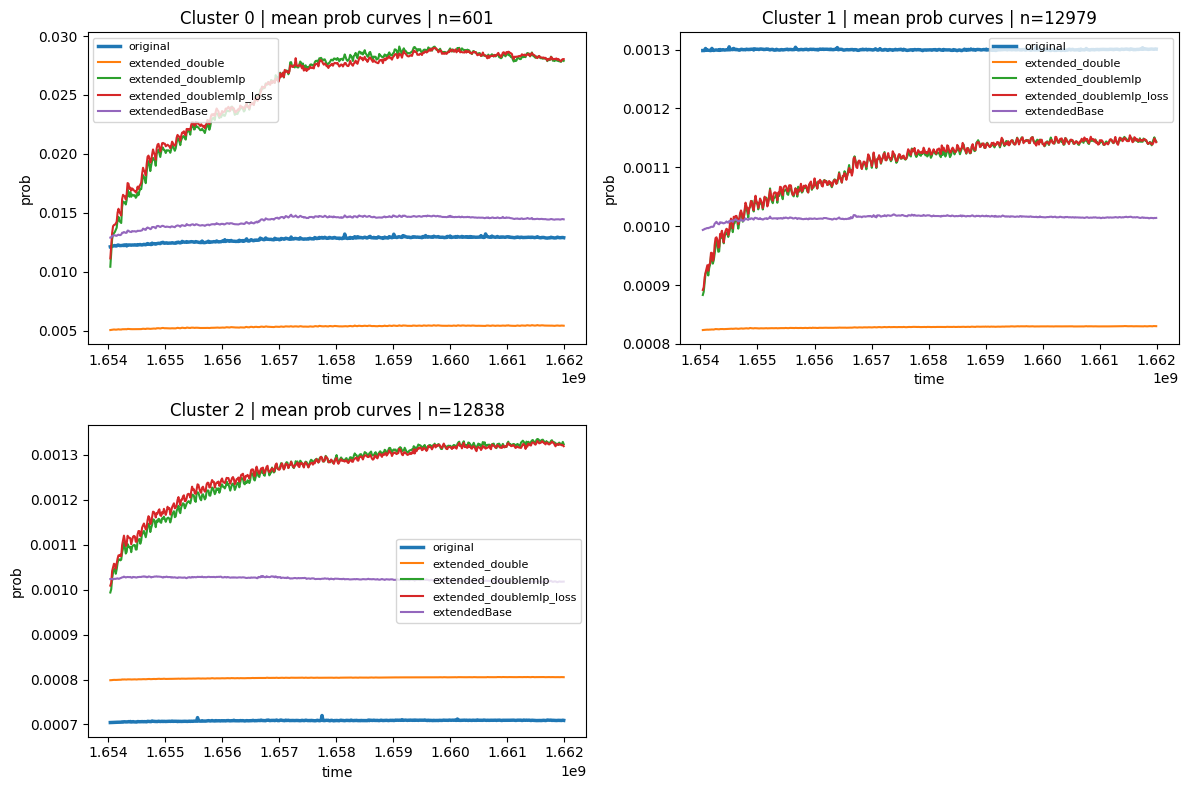

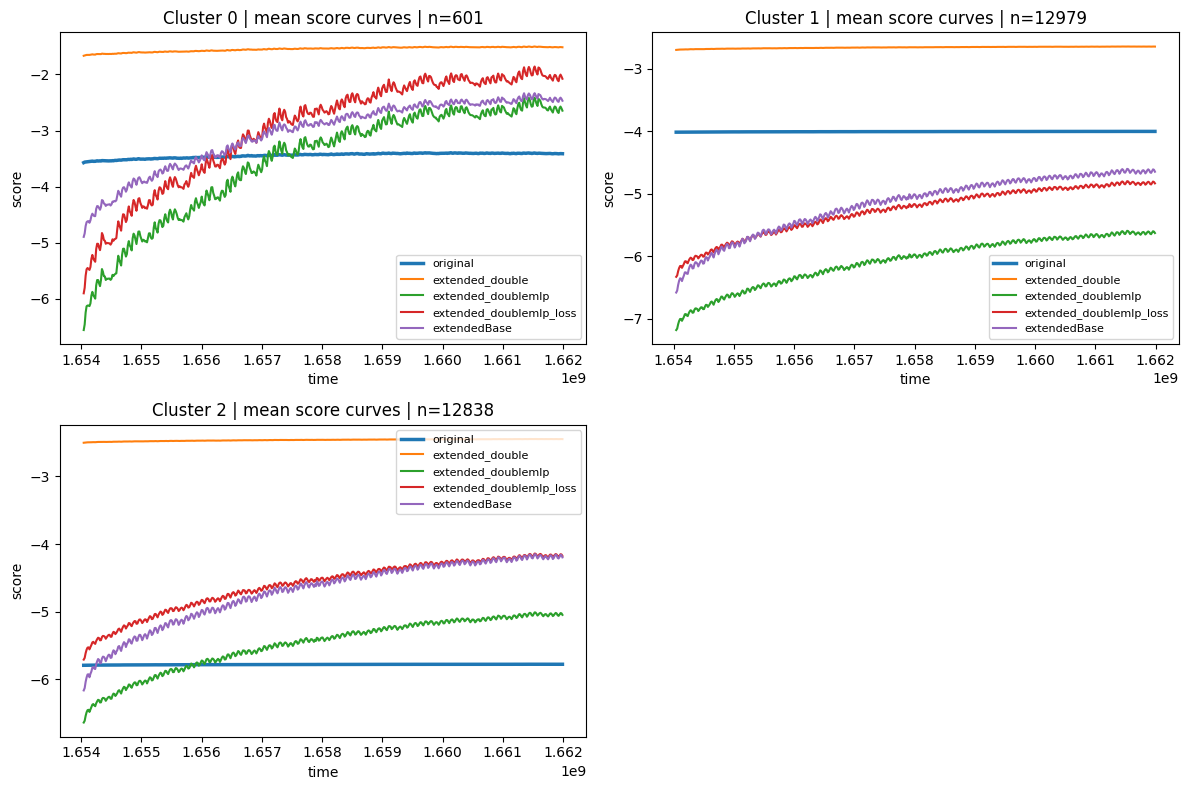

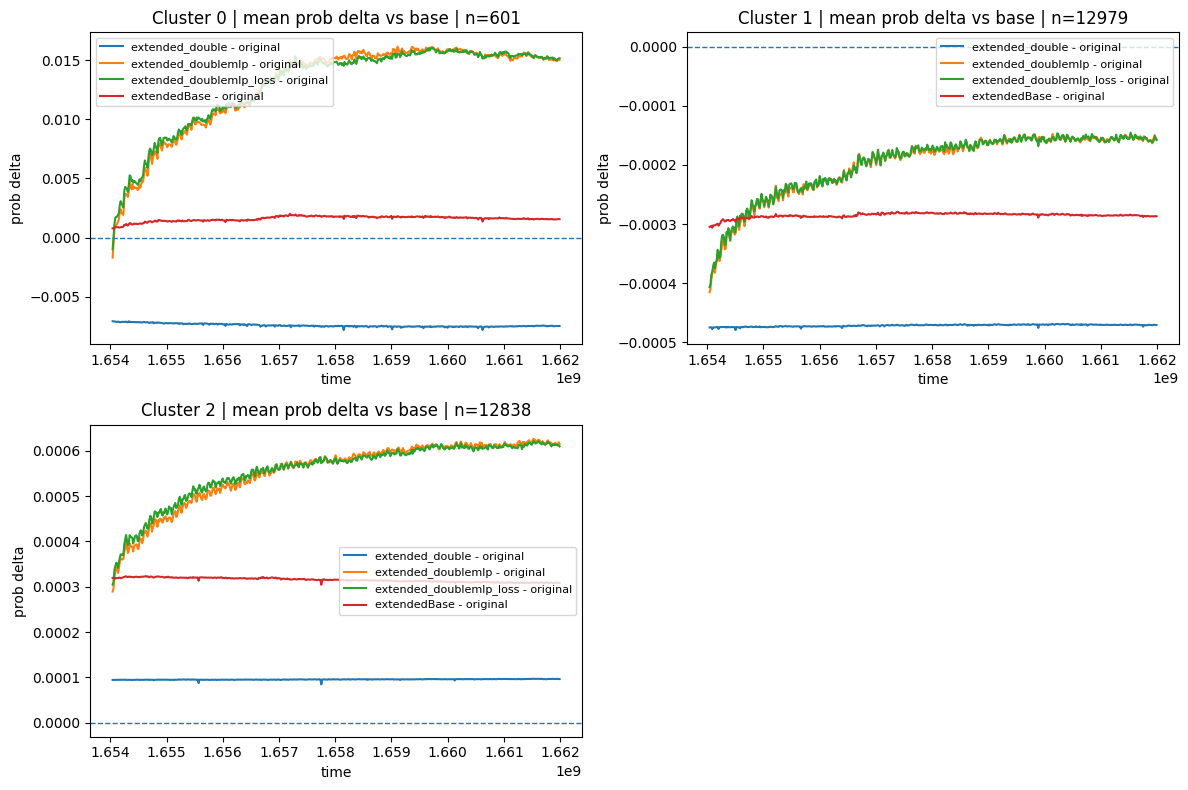

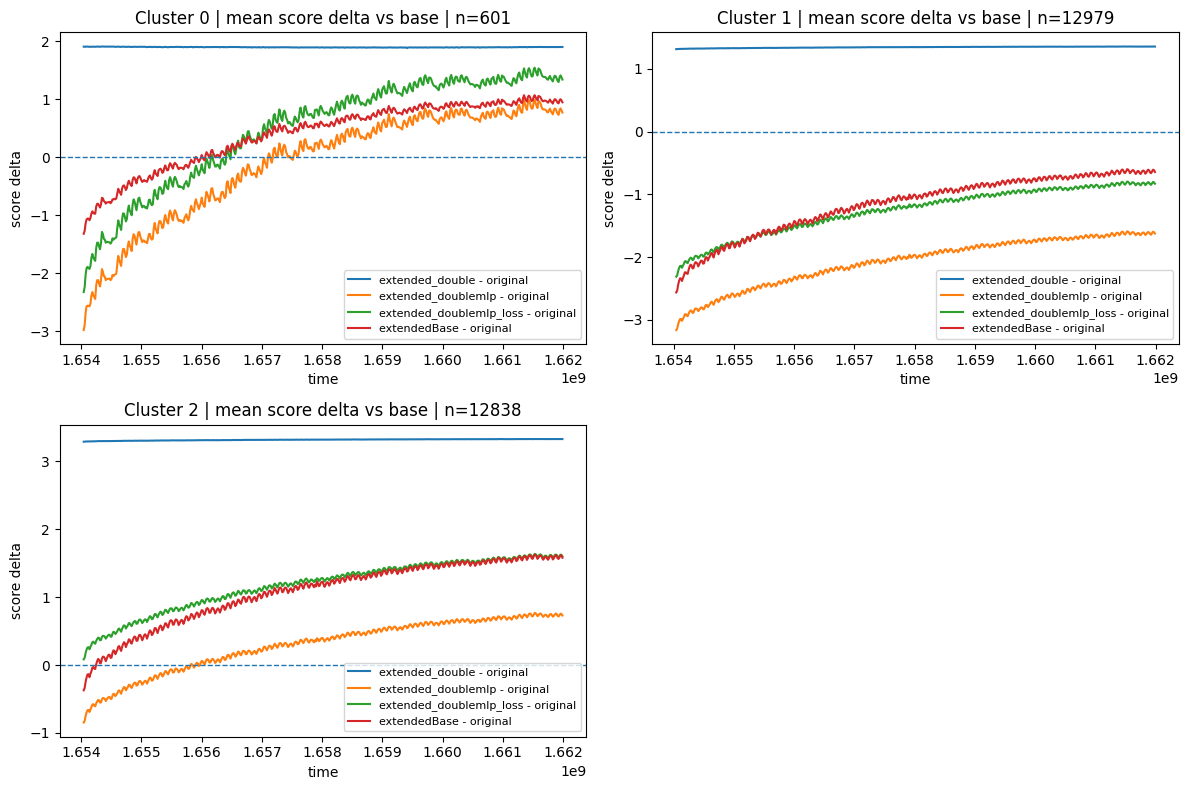

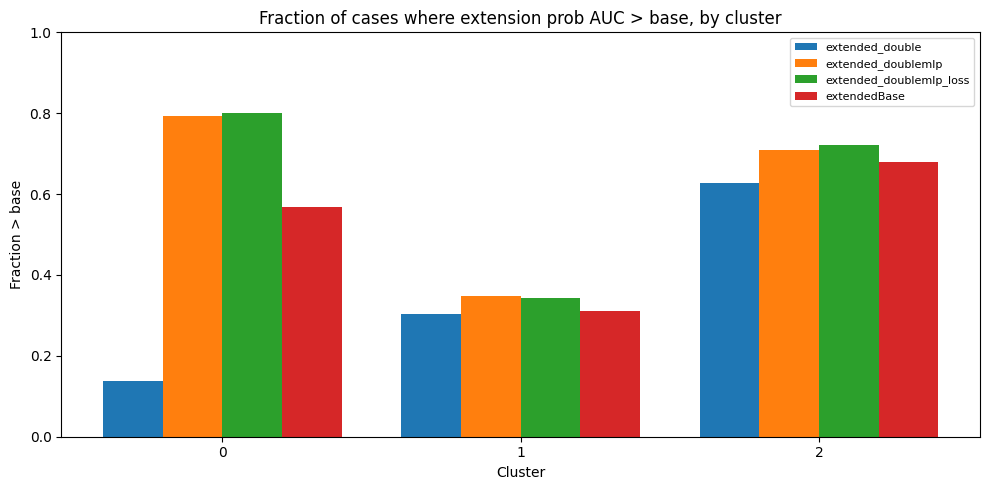

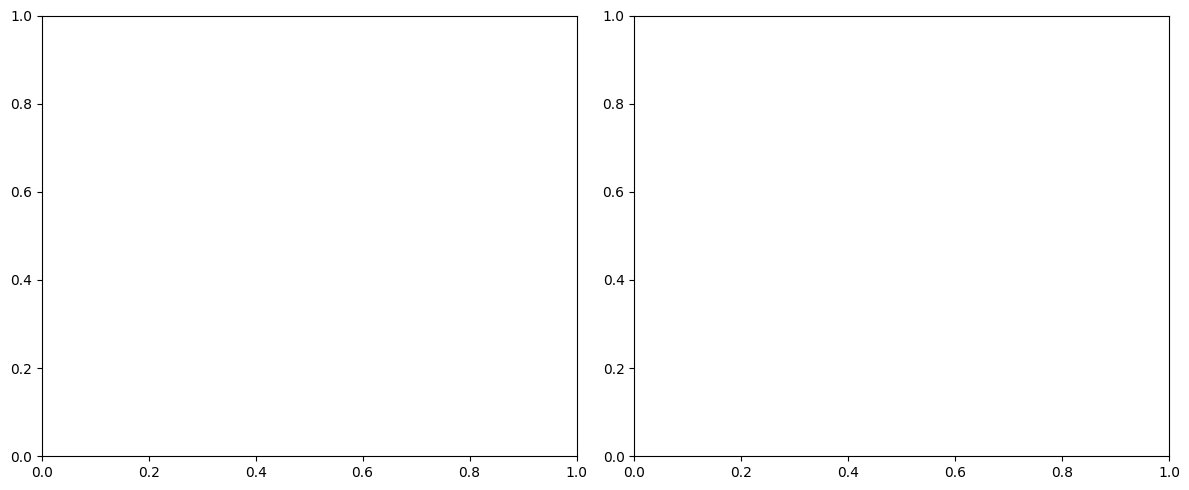

In [16]:
results = run_model_difference_analysis(
    model_dfs=data,
    base_model="original",
    times=times,
    n_clusters=None,                  # set an int to force k, or None to choose automatically
    require_all_extensions=False,     # True if you only want rows present for every extension
    user_col="user",
    item_col="item",
    score_col="score",
    prob_col="prob",
    random_state=42,
    max_clusters_in_curve_plots=8,
    heatmap_top_n=25,
)

In [17]:
generation_plan = {
    "baseline": "original",
    "gen1": ["extended_double", "extendedBase"],
    "gen2": ["extended_doublemlp_loss"],
}

# results = run_model_difference_analysis(
#     model_dfs=data,
#     base_model="original",
#     times=times,
#     n_clusters=None,
#     require_all_extensions=False,
#     user_col="user",
#     item_col="item",
#     score_col="score",
#     prob_col="prob",
#     random_state=42,
#     max_clusters_in_curve_plots=8,
#     heatmap_top_n=25,
# )

behavior_report = generate_behavior_reports(
    results=results,
    times=times,
    generation_plan=generation_plan,
    top_n=5,
    min_salience=0.20,
    min_pairs=25,
    per_cluster=True,
    min_cluster_pairs=20,
)

print_behavior_reports(behavior_report)

extended_double vs original
----------------------------------------------------------------------------------------------------
On 26,418 shared user-item pairs, extended_double differs from original mainly in the following ways: sustains more score mass over time (score_auc Δ=+18405091.790, stdΔ=+1.109, 90% of shared cases above); shows weaker score-probability co-movement (sp_corr Δ=-0.375, stdΔ=-0.887, 14% of shared cases above); changes more from one score timestep to the next (score_tv Δ=+0.002, stdΔ=+0.702, 91% of shared cases above); has more score jaggedness and sharper bends (score_rough2 Δ=+0.003, stdΔ=+0.688, 91% of shared cases above); shows a flatter or more downward score trend (score_slope Δ=-4.248, stdΔ=-0.433, 19% of shared cases above). Overall, this makes it look more assertive overall, more jagged in second-order shape, more score-prob decoupled relative to original.

Cluster-specific behavior:
  - Cluster 0: In cluster 0 on 601 shared user-item pairs, extended_dou

In [18]:
feature_df = results["feature_df"]
aligned_df = results["aligned_df"]
cluster_summary = results["cluster_summary"]

print("Chosen k:", results["n_clusters"])
print(feature_df.head())
print(cluster_summary.head())

plt.show()
save_figures(results["figures"], "model_diff_outputs")

Chosen k: 3
   user   item  base_score_mean  base_score_std  base_score_min  \
0   1.0  208.0        -3.074120        0.004577       -3.077842   
1   1.0  380.0        -6.971283        0.014714       -6.975618   
2   2.0  594.0        -5.499213        0.005677       -5.504397   
3   2.0  673.0        -3.389178        0.018019       -3.420261   
4   3.0   71.0        -4.260634        0.012846       -4.270655   

   base_score_max  base_score_range  base_score_auc  base_score_slope  \
0       -3.009756          0.068086   -2.443545e+07         -2.549025   
1       -6.662646          0.312972   -5.541312e+07         -7.878941   
2       -5.416781          0.087616   -4.371195e+07         -3.632664   
3       -3.261987          0.158274   -2.693963e+07         -8.134072   
4       -4.162538          0.108117   -3.386684e+07         -7.878926   

   base_score_tv  ...  ext_pairwise_score_corr_std  \
0       0.000268  ...                     0.032216   
1       0.001248  ...                 

In [19]:
results.keys()

dict_keys(['aligned_df', 'feature_df', 'feature_cols_used', 'cluster_model', 'n_clusters', 'figures', 'cluster_summary', 'model_name_map', 'safe_to_original', 'base_safe', 'extension_safes'])

In [20]:
results['feature_df']

,user,item,base_score_mean,base_score_std,base_score_min,base_score_max,base_score_range,base_score_auc,base_score_slope,base_score_tv,...,ext_pairwise_score_corr_std,ext_pairwise_score_corr_min,ext_pairwise_score_corr_max,ext_pairwise_score_corr_range,ext_pairwise_prob_corr_mean,ext_pairwise_prob_corr_std,ext_pairwise_prob_corr_min,ext_pairwise_prob_corr_max,ext_pairwise_prob_corr_range,cluster
0,1.0,208.0,-3.074120,0.004577,-3.077842,-3.009756,0.068086,-2.443545e+07,-2.549025,0.000268,...,0.032216,0.896647,0.978674,0.082026,0.438717,0.218470,0.217424,0.892837,0.675413,1
1,1.0,380.0,-6.971283,0.014714,-6.975618,-6.662646,0.312972,-5.541312e+07,-7.878941,0.001248,...,0.173787,0.521143,0.942515,0.421372,0.348095,0.327765,-0.064162,0.811793,0.875955,2
2,2.0,594.0,-5.499213,0.005677,-5.504397,-5.416781,0.087616,-4.371195e+07,-3.632664,0.000346,...,0.041542,0.870991,0.988120,0.117128,0.510813,0.222256,0.224351,0.941870,0.717519,2
3,2.0,673.0,-3.389178,0.018019,-3.420261,-3.261987,0.158274,-2.693963e+07,-8.134072,0.002328,...,0.025268,0.920581,0.993774,0.073193,0.654176,0.132257,0.529146,0.920859,0.391713,2
4,3.0,71.0,-4.260634,0.012846,-4.270655,-4.162538,0.108117,-3.386684e+07,-7.878926,0.000847,...,0.042804,0.877551,0.990903,0.113351,0.594101,0.171758,0.422414,0.937698,0.515284,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26413,13207.0,1055.0,-5.346987,0.005458,-5.349280,-5.283071,0.066210,-4.250201e+07,-7.260300,0.000256,...,0.010116,0.959429,0.987327,0.027897,0.462514,0.201679,0.304006,0.853979,0.549973,1
26414,13208.0,1311.0,-2.326126,0.016463,-2.351284,-2.189893,0.161391,-1.848969e+07,-6.885759,0.002626,...,0.055709,0.802212,0.968865,0.166653,0.101489,0.390585,-0.335658,0.826127,1.161786,1
26415,13208.0,1640.0,-3.225501,0.018756,-3.248831,-3.108622,0.140209,-2.563854e+07,-4.720179,0.002079,...,0.131682,0.648323,0.978413,0.330090,0.661167,0.230857,0.313844,0.970510,0.656666,1
26416,13209.0,453.0,-4.459645,0.003627,-4.462603,-4.417854,0.044748,-3.544869e+07,-4.612085,0.000175,...,0.051707,0.814295,0.957083,0.142787,0.203907,0.658747,-0.642111,0.939239,1.581350,1


In [21]:
save_figures(results["figures"], "model_diff_outputs")

In [22]:
# =========================
# Distribution visualizations for behavior metrics
# =========================

def _get_model_metric_subset(metric_df, model, metric, model_name_map, cluster_col="cluster"):
    """
    Filter long metric table to one model and one metric.
    Accepts either original model name or safe model name.
    """
    model_safe = _resolve_safe_model_name(model, model_name_map)

    if metric not in metric_df.columns:
        raise KeyError(f"Metric '{metric}' not found in metric_df")

    keep_cols = ["user", "item", "model", "model_safe", metric]
    if cluster_col in metric_df.columns:
        keep_cols.append(cluster_col)

    sub = metric_df.loc[metric_df["model_safe"] == model_safe, keep_cols].copy()
    sub[metric] = pd.to_numeric(sub[metric], errors="coerce")
    sub = sub.loc[np.isfinite(sub[metric])].copy()

    if cluster_col in sub.columns:
        sub = sub.loc[sub[cluster_col].notna()].copy()

    return sub


def _sorted_cluster_ids(values):
    vals = list(pd.Series(values).dropna().unique())
    try:
        return sorted(vals)
    except Exception:
        return vals


def compute_metric_cluster_separation(metric_df, model, metric, model_name_map, cluster_col="cluster"):
    """
    One-way ANOVA style effect size:
      eta^2 = between-cluster variance / total variance

    This is a useful scalar summary of whether the clusters "tell you anything"
    for a given metric of a given model.
    """
    sub = _get_model_metric_subset(metric_df, model, metric, model_name_map, cluster_col=cluster_col)

    if sub.empty or cluster_col not in sub.columns:
        return {
            "model": model,
            "metric": metric,
            "n": 0,
            "eta2": np.nan,
            "overall_mean": np.nan,
            "overall_std": np.nan,
            "cluster_stats": pd.DataFrame(),
        }

    x = sub[metric].to_numpy(dtype=float)
    grand_mean = float(np.mean(x))
    ss_total = float(np.sum((x - grand_mean) ** 2))

    cluster_rows = []
    ss_between = 0.0

    for cluster_id, g in sub.groupby(cluster_col):
        vals = g[metric].to_numpy(dtype=float)
        n = len(vals)
        if n == 0:
            continue

        mu = float(np.mean(vals))
        sd = float(np.std(vals))
        ss_between += n * (mu - grand_mean) ** 2

        cluster_rows.append({
            "cluster": cluster_id,
            "n": n,
            "mean": mu,
            "std": sd,
            "min": float(np.min(vals)),
            "max": float(np.max(vals)),
            "median": float(np.median(vals)),
        })

    eta2 = ss_between / ss_total if ss_total > 0 else np.nan
    cluster_stats = pd.DataFrame(cluster_rows).sort_values("cluster").reset_index(drop=True)

    return {
        "model": model,
        "metric": metric,
        "n": len(sub),
        "eta2": float(eta2) if np.isfinite(eta2) else np.nan,
        "overall_mean": grand_mean,
        "overall_std": float(np.std(x)),
        "cluster_stats": cluster_stats,
    }


def plot_metric_distribution_overall_and_clusters(
    metric_df,
    model,
    metric,
    model_name_map,
    cluster_col="cluster",
    bins=40,
    density=True,
    figsize=(18, 4.8),
):
    """
    For one model + one metric, show:
      1) overall distribution
      2) same distribution split by cluster
      3) cluster-level boxplot
    """
    sub = _get_model_metric_subset(metric_df, model, metric, model_name_map, cluster_col=cluster_col)
    if sub.empty:
        raise ValueError(f"No data available for model={model}, metric={metric}")

    sep = compute_metric_cluster_separation(
        metric_df=metric_df,
        model=model,
        metric=metric,
        model_name_map=model_name_map,
        cluster_col=cluster_col,
    )

    x = sub[metric].to_numpy(dtype=float)
    cluster_ids = _sorted_cluster_ids(sub[cluster_col])

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # --- Panel 1: overall distribution
    axes[0].hist(x, bins=bins, density=density, alpha=0.8)
    axes[0].axvline(np.mean(x), linestyle="--", linewidth=1.5)
    axes[0].set_title(f"{model} | {metric}\nOverall distribution (n={len(x)})")
    axes[0].set_xlabel(metric)
    axes[0].set_ylabel("Density" if density else "Count")

    # --- Panel 2: cluster overlay
    for cluster_id in cluster_ids:
        vals = sub.loc[sub[cluster_col] == cluster_id, metric].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        axes[1].hist(
            vals,
            bins=bins,
            density=density,
            alpha=0.25,
            label=f"cluster {cluster_id} (n={len(vals)})",
        )

    axes[1].hist(
        x,
        bins=bins,
        density=density,
        histtype="step",
        linewidth=2.0,
        label="overall",
    )
    axes[1].set_title(f"{model} | {metric}\nCluster overlays | eta²={sep['eta2']:.3f}")
    axes[1].set_xlabel(metric)
    axes[1].set_ylabel("Density" if density else "Count")
    axes[1].legend(fontsize=8)

    # --- Panel 3: boxplot by cluster
    box_data = []
    box_labels = []
    for cluster_id in cluster_ids:
        vals = sub.loc[sub[cluster_col] == cluster_id, metric].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        box_data.append(vals)
        box_labels.append(f"{cluster_id}\n(n={len(vals)})")

    if box_data:
        axes[2].boxplot(box_data, labels=box_labels, vert=True)
        axes[2].axhline(np.mean(x), linestyle="--", linewidth=1.2)
        axes[2].set_title(f"{model} | {metric}\nCluster boxplots")
        axes[2].set_xlabel("Cluster")
        axes[2].set_ylabel(metric)
    else:
        axes[2].text(0.5, 0.5, "No cluster data", ha="center", va="center")
        axes[2].set_axis_off()

    plt.tight_layout()
    return fig, sep


def plot_metric_violin_by_cluster(
    metric_df,
    model,
    metric,
    model_name_map,
    cluster_col="cluster",
    figsize=(8, 4.8),
):
    """
    Alternate view: violin distributions by cluster for one model + metric.
    """
    sub = _get_model_metric_subset(metric_df, model, metric, model_name_map, cluster_col=cluster_col)
    if sub.empty:
        raise ValueError(f"No data available for model={model}, metric={metric}")

    cluster_ids = _sorted_cluster_ids(sub[cluster_col])
    data = []
    labels = []

    for cluster_id in cluster_ids:
        vals = sub.loc[sub[cluster_col] == cluster_id, metric].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        data.append(vals)
        labels.append(f"{cluster_id}\n(n={len(vals)})")

    if not data:
        raise ValueError("No non-empty cluster groups found")

    sep = compute_metric_cluster_separation(
        metric_df=metric_df,
        model=model,
        metric=metric,
        model_name_map=model_name_map,
        cluster_col=cluster_col,
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.violinplot(data, showmeans=True, showextrema=True, showmedians=False)
    ax.axhline(np.mean(sub[metric]), linestyle="--", linewidth=1.2)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_title(f"{model} | {metric}\nCluster violins | eta²={sep['eta2']:.3f}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(metric)
    plt.tight_layout()
    return fig, sep

def _transform_for_plot(vals, transform=None):
    """
    Optional x-transform for visualization.
    transform:
      - None: no transform
      - 'log1p': use log1p, only valid if all values > -1
    """
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if transform is None:
        return vals, None

    if transform == "log1p":
        if np.any(vals <= -1):
            raise ValueError("log1p transform requested but values <= -1 are present")
        return np.log1p(vals), "log1p"

    raise ValueError("transform must be None or 'log1p'")


def _central_plot_range(x, q=(0.01, 0.99), pad_frac=0.05):
    """
    Robust plotting range based on central quantiles.
    Useful when a long tail makes histograms unreadable.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None

    lo, hi = np.quantile(x, q)

    if np.isclose(lo, hi):
        lo, hi = np.min(x), np.max(x)

    if np.isclose(lo, hi):
        pad = 1.0 if lo == 0 else abs(lo) * pad_frac
        return lo - pad, hi + pad

    pad = (hi - lo) * pad_frac
    return lo - pad, hi + pad


def plot_model_metric_grid(
    metric_df,
    models,
    metrics,
    model_name_map,
    cluster_col="cluster",
    mode="cluster_overlay",
    bins=30,
    density=True,
    max_cols=3,
    figsize_per_ax=(5.2, 3.8),
    zoom_quantiles=(0.01, 0.99),
    log_y=True,
    transform=None,
    showfliers=False,
):
    """
    Grid view to scan many model/metric combinations.

    mode:
      - "overall": zoomed overall histogram
      - "cluster_overlay": zoomed per-cluster overlays + overall outline
      - "full_cluster_overlay": full-range per-cluster overlays + overall outline
      - "box": boxplots by cluster

    Tail-handling features:
      - zoom_quantiles limits histogram x-range to central mass
      - log_y makes small bins visible
      - transform='log1p' helps positive heavy-tailed metrics
      - showfliers=False prevents boxplots being crushed by extreme tails
    """
    panels = [(m, k) for m in models for k in metrics]
    n = len(panels)
    ncols = min(max_cols, max(1, n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_ax[0] * ncols, figsize_per_ax[1] * nrows),
        squeeze=False,
    )

    for ax, (model, metric) in zip(axes.flat, panels):
        try:
            sub = _get_model_metric_subset(metric_df, model, metric, model_name_map, cluster_col=cluster_col)
            if sub.empty:
                ax.set_title(f"{model} | {metric}\nNo data")
                ax.axis("off")
                continue

            raw_vals = sub[metric].to_numpy(dtype=float)
            vals, transform_name = _transform_for_plot(raw_vals, transform=transform)

            sep = compute_metric_cluster_separation(
                metric_df=metric_df,
                model=model,
                metric=metric,
                model_name_map=model_name_map,
                cluster_col=cluster_col,
            )

            xlabel = metric if transform_name is None else f"{transform_name}({metric})"

            if mode == "overall":
                xr = _central_plot_range(vals, q=zoom_quantiles)
                ax.hist(vals, bins=bins, density=density, alpha=0.8, range=xr)
                ax.axvline(np.mean(vals), linestyle="--", linewidth=1.2)
                ax.set_title(f"{model} | {metric}\nzoom {zoom_quantiles}")
                ax.set_xlabel(xlabel)
                ax.set_ylabel("Density" if density else "Count")
                if log_y:
                    ax.set_yscale("log")

            elif mode == "cluster_overlay":
                xr = _central_plot_range(vals, q=zoom_quantiles)
                cluster_ids = _sorted_cluster_ids(sub[cluster_col])

                for cluster_id in cluster_ids:
                    cvals_raw = sub.loc[sub[cluster_col] == cluster_id, metric].to_numpy(dtype=float)
                    cvals, _ = _transform_for_plot(cvals_raw, transform=transform)
                    if len(cvals) == 0:
                        continue
                    ax.hist(
                        cvals,
                        bins=bins,
                        density=density,
                        alpha=0.22,
                        range=xr,
                    )

                ax.hist(
                    vals,
                    bins=bins,
                    density=density,
                    histtype="step",
                    linewidth=2.0,
                    range=xr,
                )
                ax.axvline(np.mean(vals), linestyle="--", linewidth=1.0)
                ax.set_title(f"{model} | {metric}\nzoomed | eta²={sep['eta2']:.3f}")
                ax.set_xlabel(xlabel)
                ax.set_ylabel("Density" if density else "Count")
                if log_y:
                    ax.set_yscale("log")

            elif mode == "full_cluster_overlay":
                cluster_ids = _sorted_cluster_ids(sub[cluster_col])

                for cluster_id in cluster_ids:
                    cvals_raw = sub.loc[sub[cluster_col] == cluster_id, metric].to_numpy(dtype=float)
                    cvals, _ = _transform_for_plot(cvals_raw, transform=transform)
                    if len(cvals) == 0:
                        continue
                    ax.hist(
                        cvals,
                        bins=bins,
                        density=density,
                        alpha=0.22,
                    )

                ax.hist(
                    vals,
                    bins=bins,
                    density=density,
                    histtype="step",
                    linewidth=2.0,
                )
                ax.axvline(np.mean(vals), linestyle="--", linewidth=1.0)
                ax.set_title(f"{model} | {metric}\nfull range | eta²={sep['eta2']:.3f}")
                ax.set_xlabel(xlabel)
                ax.set_ylabel("Density" if density else "Count")
                if log_y:
                    ax.set_yscale("log")

            elif mode == "box":
                cluster_ids = _sorted_cluster_ids(sub[cluster_col])
                data = []
                labels = []

                for cluster_id in cluster_ids:
                    cvals_raw = sub.loc[sub[cluster_col] == cluster_id, metric].to_numpy(dtype=float)
                    cvals, _ = _transform_for_plot(cvals_raw, transform=transform)
                    if len(cvals) == 0:
                        continue
                    data.append(cvals)
                    labels.append(str(cluster_id))

                if data:
                    ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
                    ax.axhline(np.mean(vals), linestyle="--", linewidth=1.0)

                ax.set_title(f"{model} | {metric}\neta²={sep['eta2']:.3f}")
                ax.set_xlabel("cluster")
                ax.set_ylabel(xlabel)

            else:
                raise ValueError("mode must be one of: 'overall', 'cluster_overlay', 'full_cluster_overlay', 'box'")

        except Exception as e:
            ax.set_title(f"{model} | {metric}\nError")
            ax.text(0.5, 0.5, str(e), ha="center", va="center", wrap=True)
            ax.set_axis_off()

    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.tight_layout()
    return fig

def compute_cluster_separation_table(
    metric_df,
    models,
    metrics,
    model_name_map,
    cluster_col="cluster",
):
    """
    Build a table of eta² scores so you can rank which metrics are actually
    separated by the clusters for each model.
    """
    rows = []
    for model in models:
        for metric in metrics:
            try:
                sep = compute_metric_cluster_separation(
                    metric_df=metric_df,
                    model=model,
                    metric=metric,
                    model_name_map=model_name_map,
                    cluster_col=cluster_col,
                )
                rows.append({
                    "model": model,
                    "metric": metric,
                    "n": sep["n"],
                    "eta2": sep["eta2"],
                    "overall_mean": sep["overall_mean"],
                    "overall_std": sep["overall_std"],
                })
            except Exception:
                rows.append({
                    "model": model,
                    "metric": metric,
                    "n": 0,
                    "eta2": np.nan,
                    "overall_mean": np.nan,
                    "overall_std": np.nan,
                })

    out = pd.DataFrame(rows)
    return out.sort_values(["eta2", "n"], ascending=[False, False]).reset_index(drop=True)


def plot_cluster_separation_heatmap(
    separation_df,
    value_col="eta2",
    figsize=(12, 5),
):
    """
    Heatmap of cluster separation scores (default: eta²).
    Rows = models, columns = metrics.
    """
    pivot = separation_df.pivot(index="model", columns="metric", values=value_col)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(f"Cluster separation heatmap ({value_col})")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Model")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    return fig

In [23]:
metric_df = behavior_report["metric_df"]
model_name_map = results["model_name_map"]

C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(box_data, labels=box_labels, vert=True)


0.2444530723280077
   cluster      n      mean       std           min       max        median
0        0    601  0.000032  0.000049  3.574114e-10  0.000425  1.561562e-05
1        1  12979  0.000001  0.000003  1.571111e-11  0.000174  4.066052e-07
2        2  12838  0.000001  0.000004  2.186797e-11  0.000107  4.124396e-07


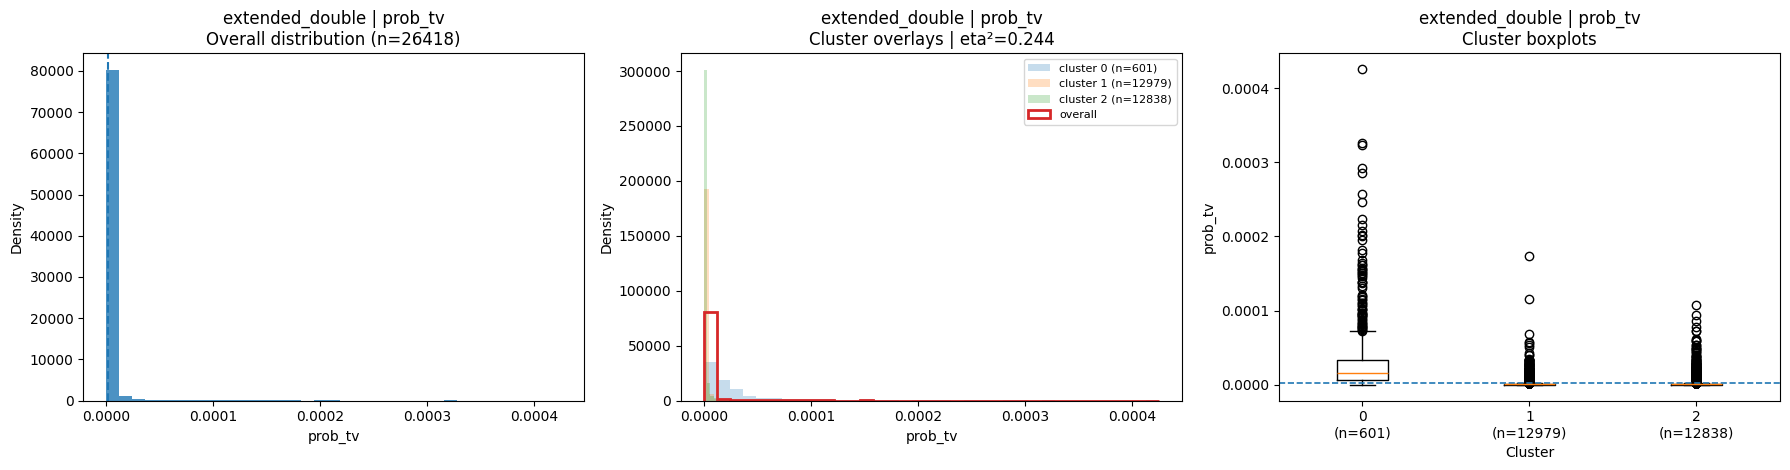

In [24]:
fig, sep = plot_metric_distribution_overall_and_clusters(
    metric_df=metric_df,
    model="extended_double",
    metric="prob_tv",
    model_name_map=model_name_map,
    bins=35,
)

print(sep["eta2"])
print(sep["cluster_stats"])

In [25]:
models_to_show = [
    "original",
    "extended_double",
    "extendedBase",
    "extended_doublemlp_loss",
]

metrics_to_show = [
    "prob_auc",
    "prob_slope",
    "prob_tv",
    "prob_rough2",
    "score_auc",
    "score_tv",
    "sp_corr",
]

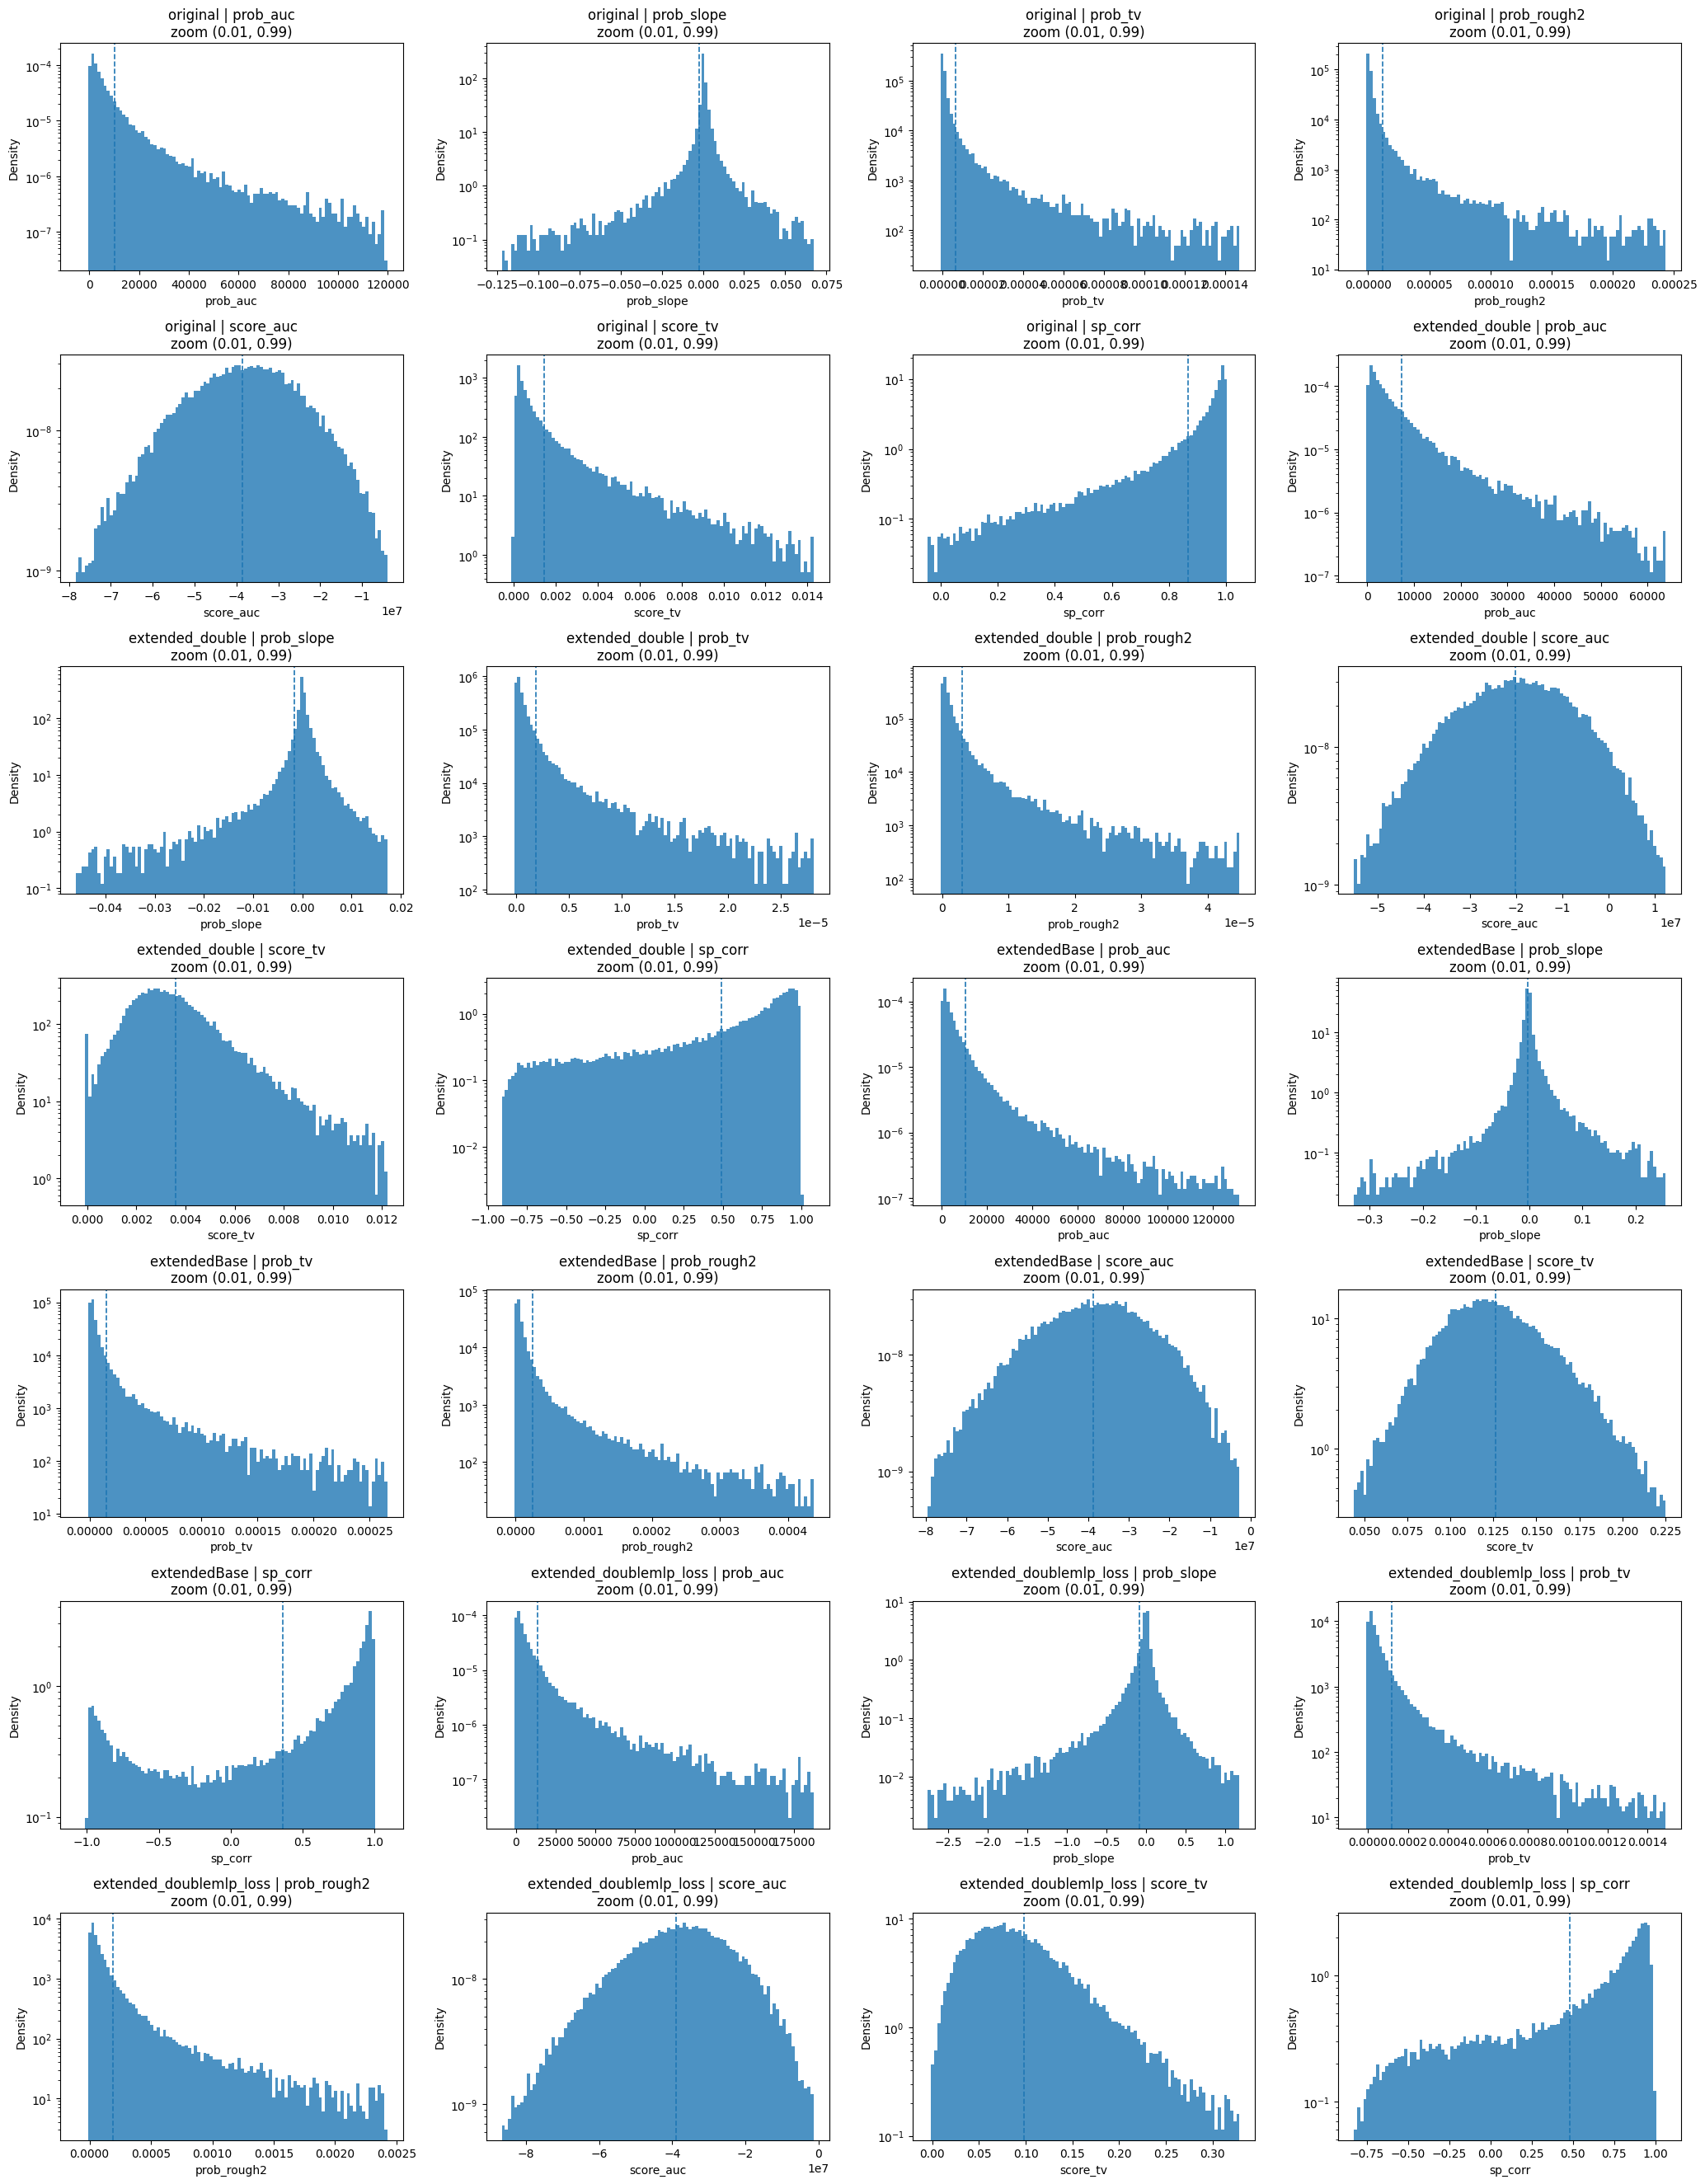

In [26]:
fig = plot_model_metric_grid(
    metric_df=metric_df,
    models=models_to_show,
    metrics=metrics_to_show,
    model_name_map=model_name_map,
    mode="overall",
    bins=100,
    max_cols=4,
)

C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDep

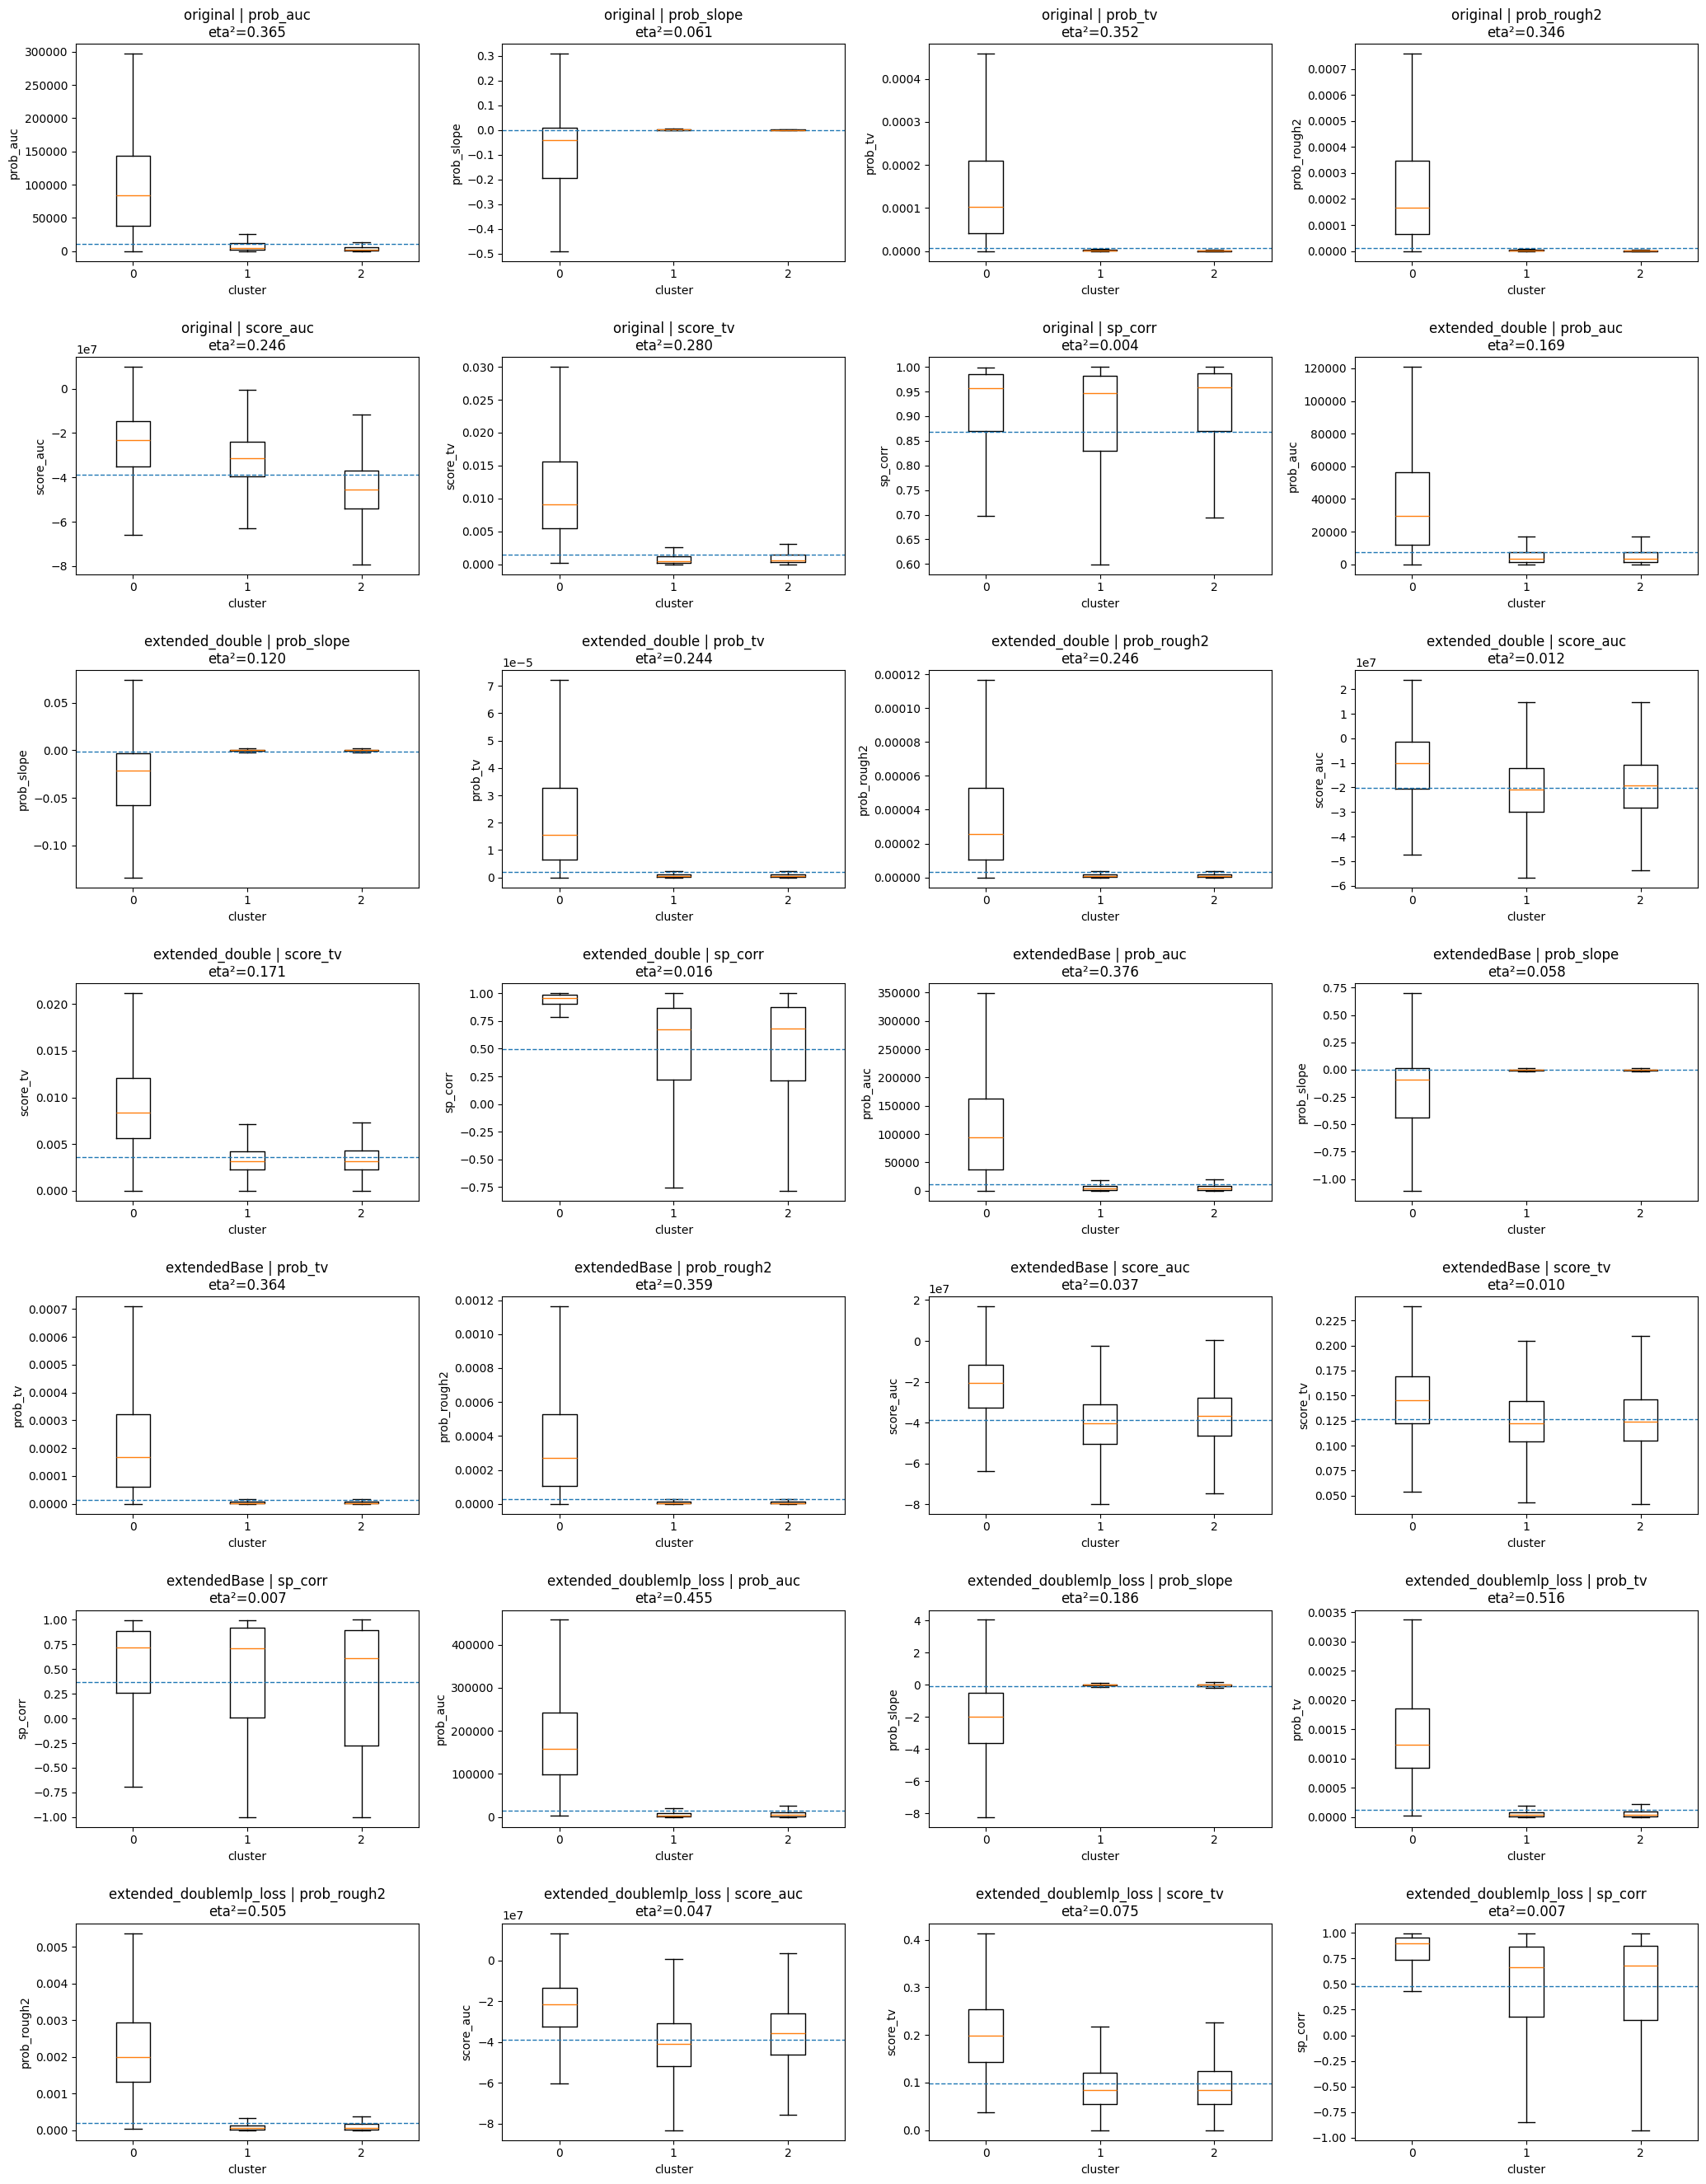

In [27]:
fig = plot_model_metric_grid(
    metric_df=metric_df,
    models=models_to_show,
    metrics=metrics_to_show,
    model_name_map=model_name_map,
    mode="box",
    max_cols=4,
)

C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True, showfliers=showfliers)
C:\Users\dodok\AppData\Local\Temp\ipykernel_21772\2923688364.py:430: MatplotlibDep

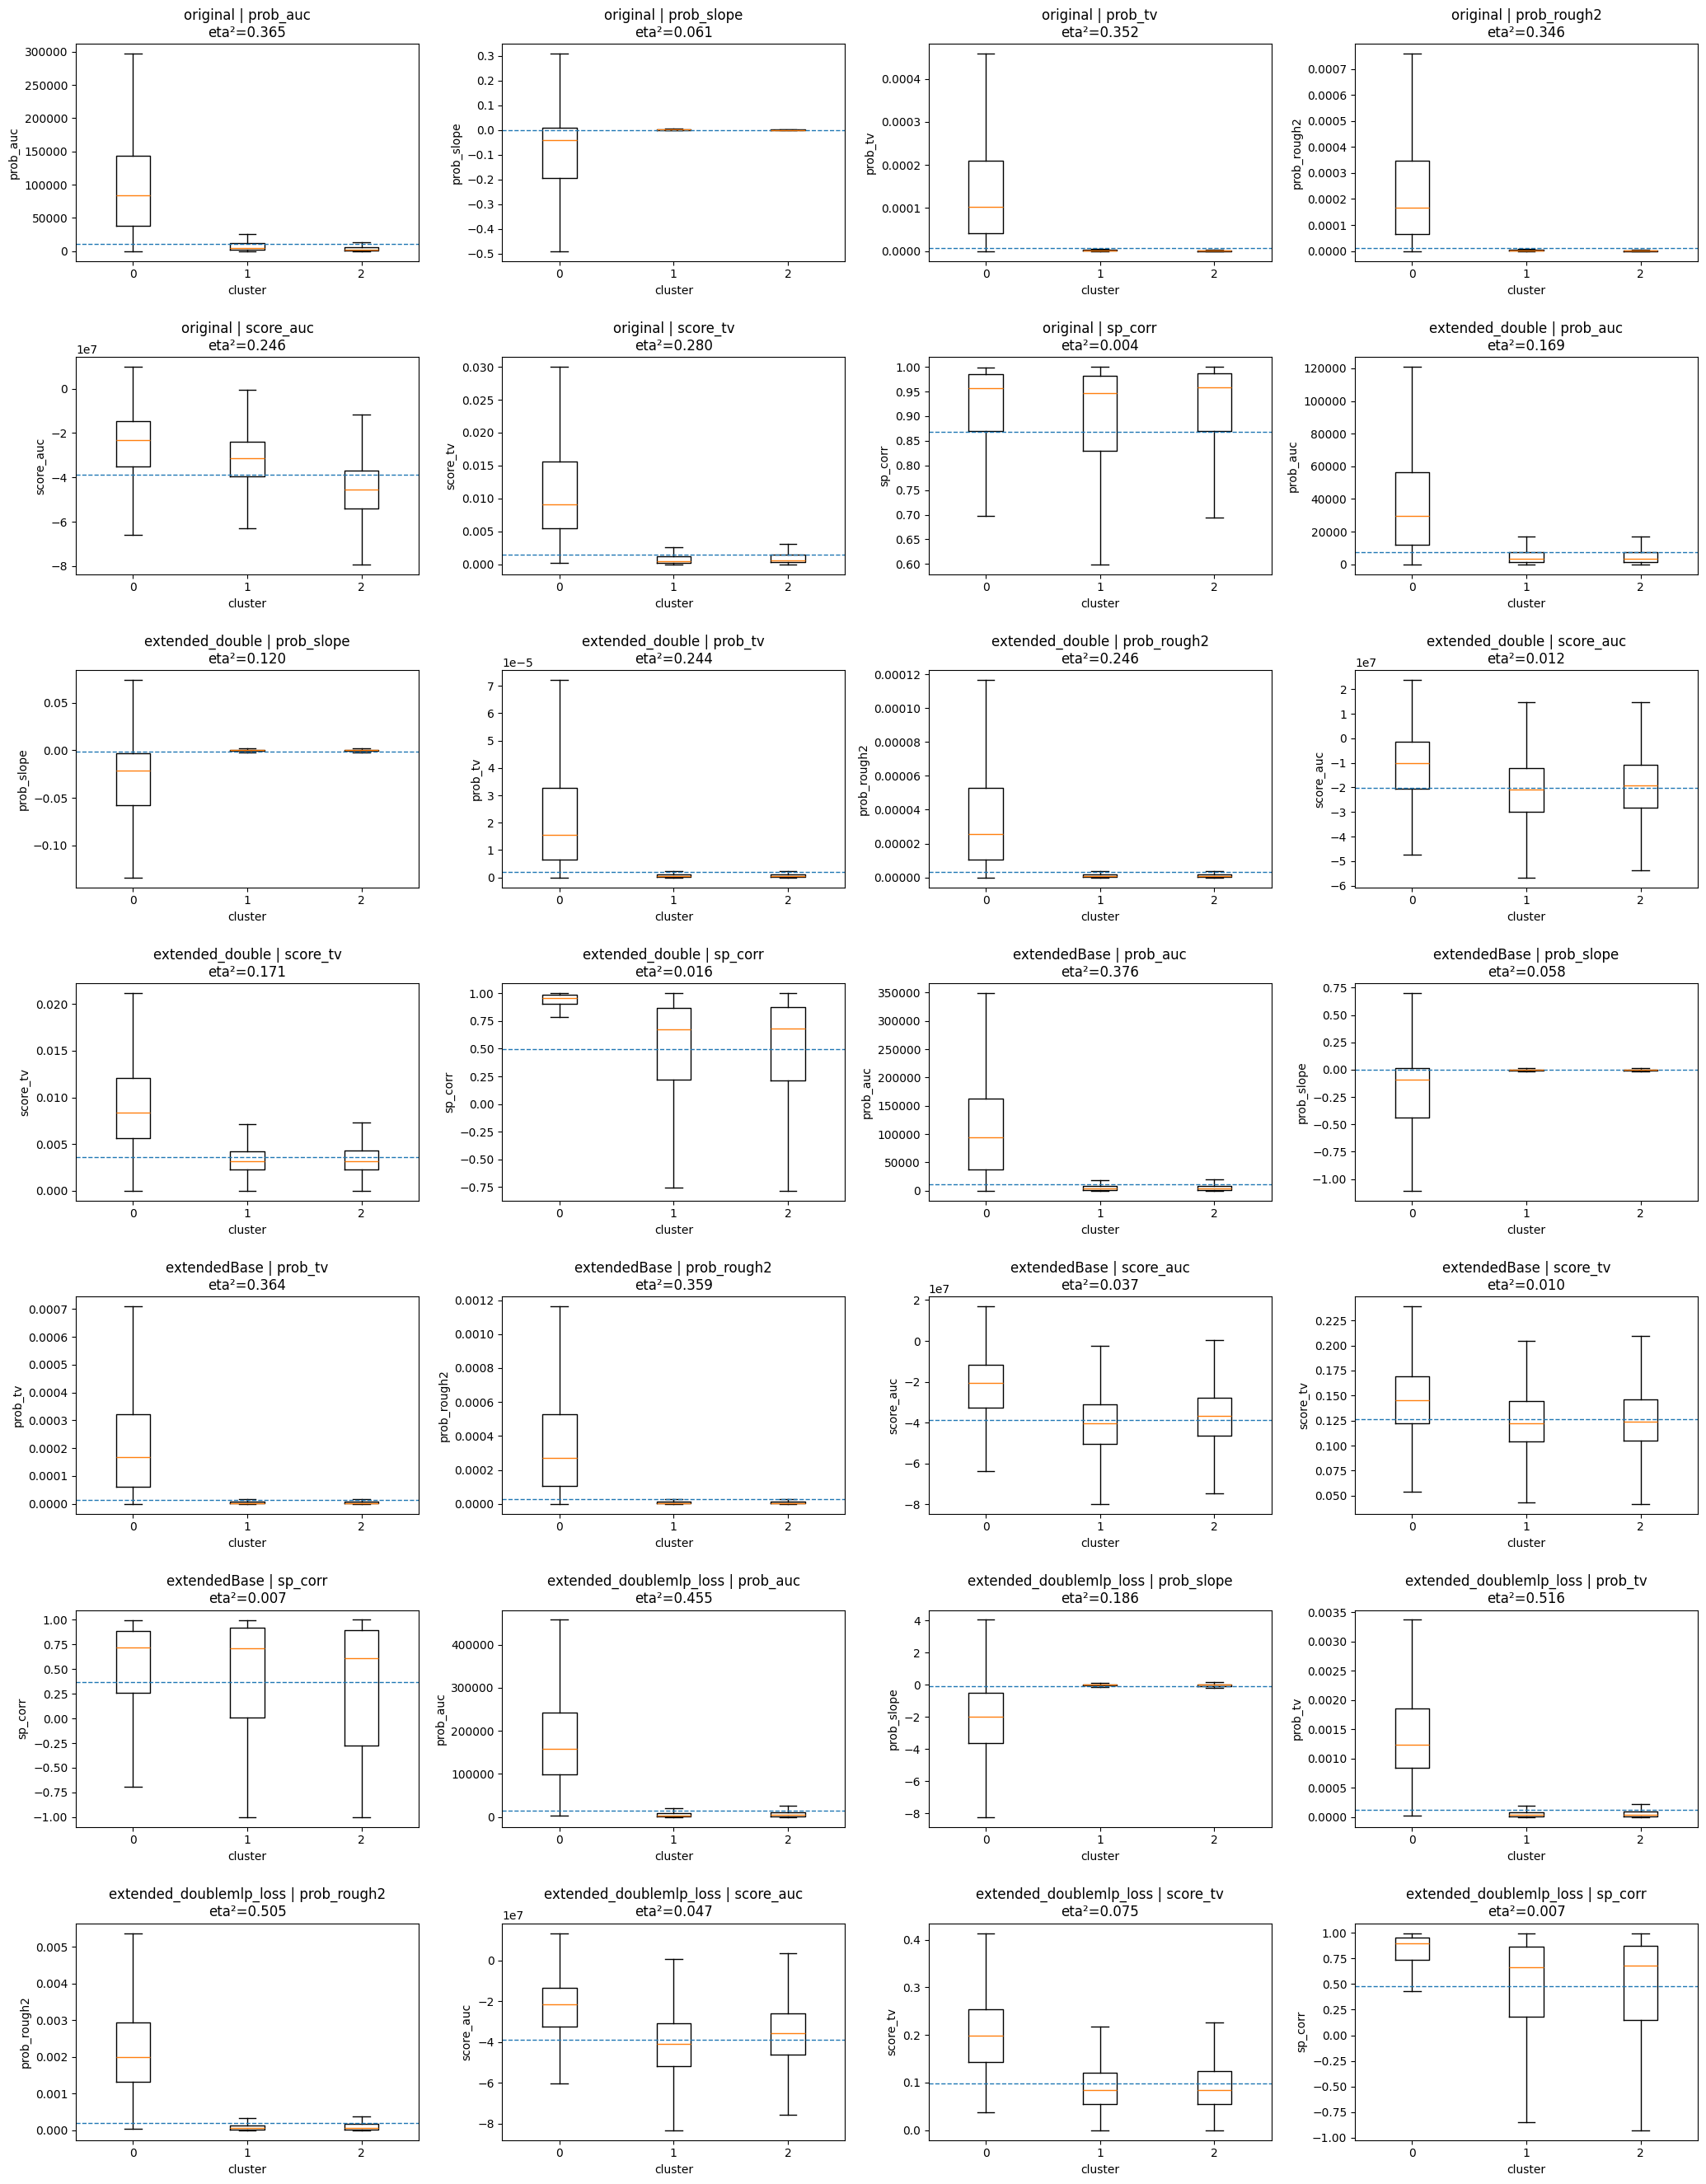

In [28]:
fig = plot_model_metric_grid(
    metric_df=metric_df,
    models=models_to_show,
    metrics=metrics_to_show,
    model_name_map=model_name_map,
    mode="box",
    max_cols=4,
)

In [29]:
sep_df = compute_cluster_separation_table(
    metric_df=metric_df,
    models=models_to_show,
    metrics=metrics_to_show,
    model_name_map=model_name_map,
)

print(sep_df.head(20))

                      model       metric      n      eta2  overall_mean  \
0   extended_doublemlp_loss      prob_tv  26418  0.516317  1.168502e-04   
1   extended_doublemlp_loss  prob_rough2  26418  0.504987  1.921381e-04   
2   extended_doublemlp_loss     prob_auc  26418  0.455284  1.383584e+04   
3              extendedBase     prob_auc  26418  0.376085  1.051124e+04   
4                  original     prob_auc  26418  0.364757  1.011946e+04   
5              extendedBase      prob_tv  26418  0.364147  1.537943e-05   
6              extendedBase  prob_rough2  26418  0.359092  2.537647e-05   
7                  original      prob_tv  26418  0.351825  6.848346e-06   
8                  original  prob_rough2  26418  0.345663  1.153853e-05   
9                  original     score_tv  26418  0.279866  1.464108e-03   
10                 original    score_auc  26418  0.246334 -3.859124e+07   
11          extended_double  prob_rough2  26418  0.245900  3.050369e-06   
12          extended_doub

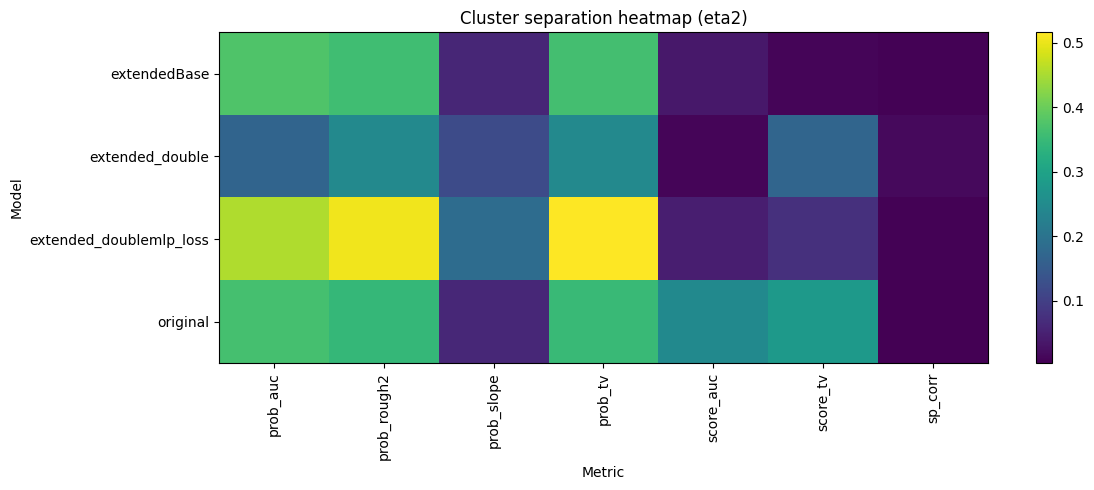

In [30]:
fig = plot_cluster_separation_heatmap(sep_df)

In [31]:
results.keys()


dict_keys(['aligned_df', 'feature_df', 'feature_cols_used', 'cluster_model', 'n_clusters', 'figures', 'cluster_summary', 'model_name_map', 'safe_to_original', 'base_safe', 'extension_safes'])

In [32]:
al_df = results['aligned_df']

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def show_for_user(
    data,
    user_id,
    item_id,
    show=None,
    curve_id="score",
    cluster_id=None,
    df_full=None,
    ts_user_col="user_id",
    ts_item_col="track_id",
    ts_time_col="ts",
):
    times = np.linspace(1654041600, 1661990376, 500)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    found = False

    for key, item in tqdm(data.items()):
        if show is not None and key not in show:
            continue

        user_item = item[(item["user"] == user_id) & (item["item"] == item_id)]
        if user_item.empty:
            continue

        y = np.asarray(user_item[curve_id].iloc[0], dtype=float)

        if len(y) != len(times):
            raise ValueError(
                f"{key}: curve length {len(y)} does not match times length {len(times)}"
            )

        ax.plot(times, y, label=f"{key}_item_{item_id}", linewidth=2)
        found = True

    # optional vertical lines from raw event table
    if df_full is not None:
        ts_values = df_full[
            (df_full[ts_user_col] == user_id) &
            (df_full[ts_item_col] == item_id)
        ][ts_time_col].to_numpy()

        for x in ts_values:
            ax.axvline(
                x,
                color="gray",
                linestyle="--",
                linewidth=1,
                alpha=0.3,
                zorder=0,
            )

    ax.set_title(
        f"User {user_id} - Item {item_id}" +
        (f" - Cluster {cluster_id}" if cluster_id is not None else "")
    )
    ax.set_xlabel("time")
    ax.set_ylabel(curve_id)

    if found:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [34]:
show_list = [
    'original',
    'extendedBase',
    'extended_double',
    # 'extended_doublemlp',
    'extended_doublemlp_loss',
]



100%|██████████| 5/5 [00:00<00:00, 294.12it/s]


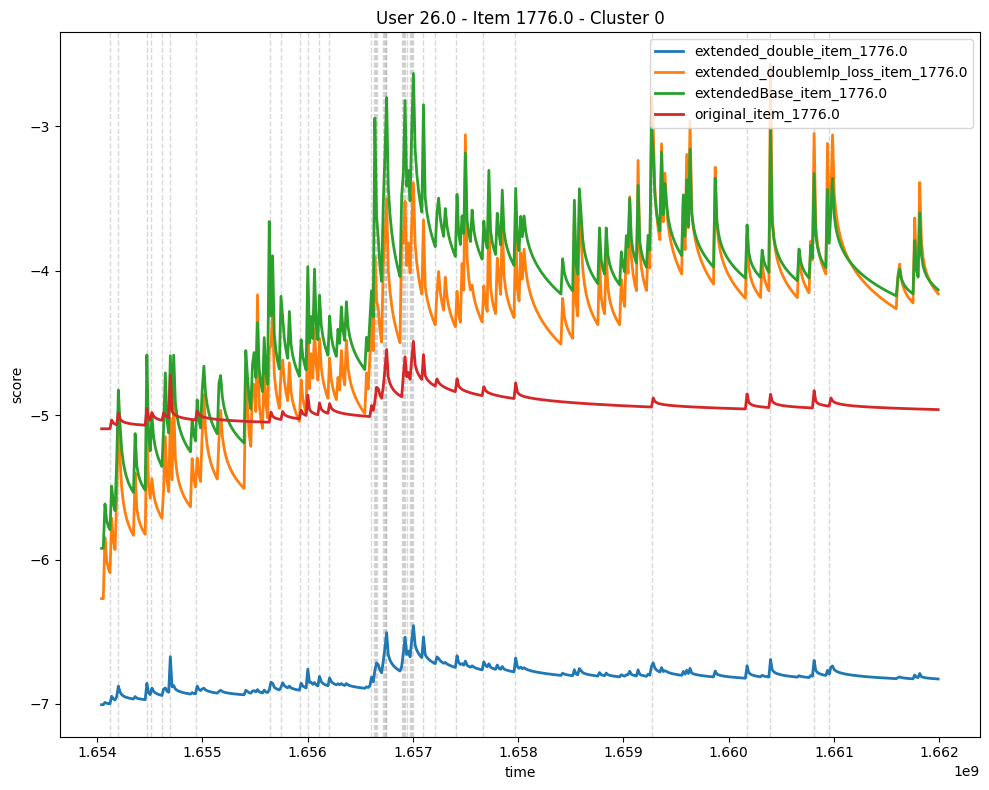

100%|██████████| 5/5 [00:00<00:00, 498.17it/s]


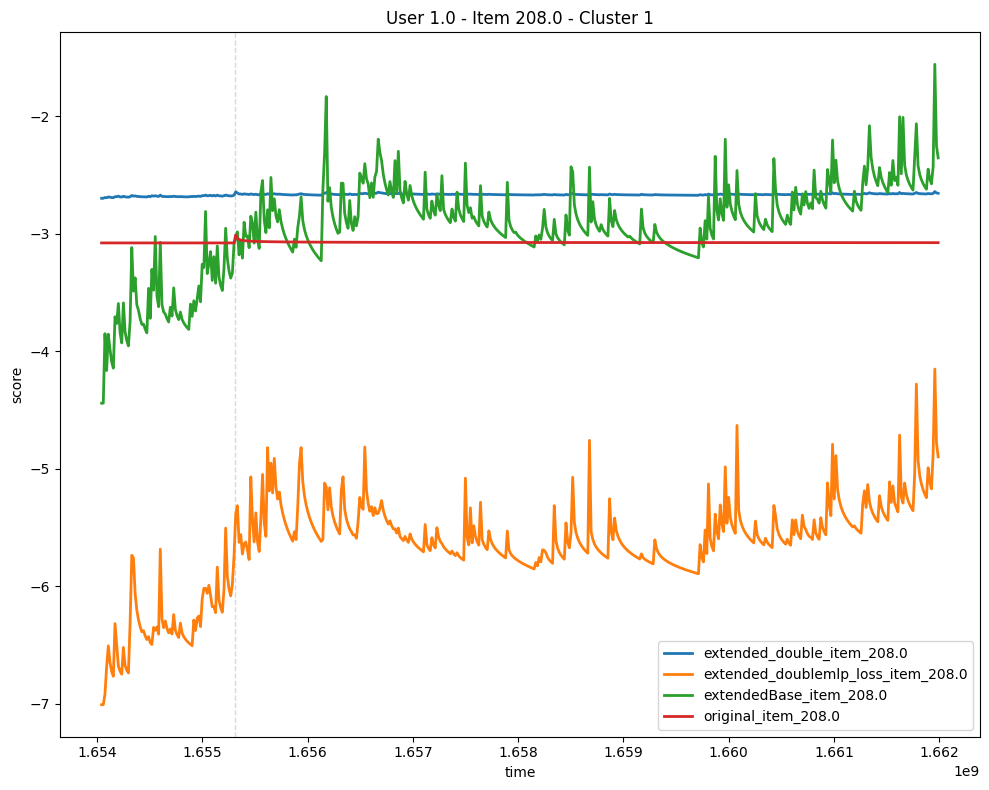

100%|██████████| 5/5 [00:00<00:00, 555.79it/s]


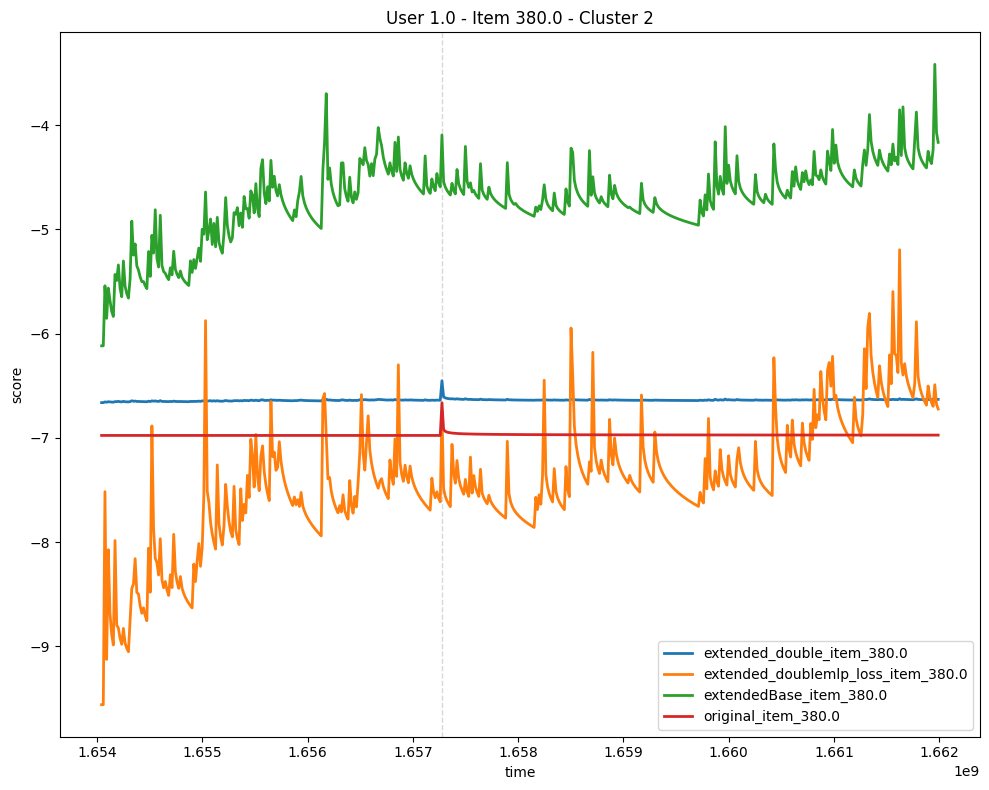

In [35]:
curve_index = 0

for c in range(3):
    tmp = al_df[al_df['cluster'] == c]

    user = tmp.iloc[curve_index, 0]
    item = tmp.iloc[curve_index, 1]

    show_for_user(
        data=data,
        user_id=user,
        item_id=item,
        show=["original", "extended_double", "extendedBase", "extended_doublemlp_loss"],
        curve_id="score",
        cluster_id=c,
        df_full=df_full,
    )

In [36]:
al_df

,user,item,score__original,prob__original,score__extended_double,prob__extended_double,score__extended_doublemlp,prob__extended_doublemlp,score__extended_doublemlp_loss,prob__extended_doublemlp_loss,score__extendedBase,prob__extendedBase,cluster
0,1.0,208.0,"[-3.0778417587280273, -3.0778417587280273, -3....","[0.0012907710624858737, 0.0012907710624858737,...","[-2.698141098022461, -2.698141098022461, -2.69...","[0.000798525579739362, 0.000798525579739362, 0...","[-3.487718105316162, -3.487718105316162, -3.46...","[0.0010720934951677918, 0.0010720934951677918,...","[-7.007225513458252, -7.007225513458252, -6.91...","[0.0004340903542470187, 0.0004340903542470187,...","[-4.44175386428833, -4.44175386428833, -3.8501...","[0.0005786984111182392, 0.0005786984111182392,...",1
1,1.0,380.0,"[-6.9756178855896, -6.9756178855896, -6.975617...","[2.6185840397374704e-05, 2.6185840397374704e-0...","[-6.660677433013916, -6.660677433013916, -6.65...","[1.5183824871201068e-05, 1.5183824871201068e-0...","[-6.115856170654297, -6.115856170654297, -4.83...","[7.741886656731367e-05, 7.741886656731367e-05,...","[-9.558518409729004, -9.558518409729004, -7.51...","[3.385069430805743e-05, 3.385069430805743e-05,...","[-6.116215705871582, -6.116215705871582, -5.53...","[0.00010845327778952196, 0.0001084532777895219...",2
2,2.0,594.0,"[-5.504396915435791, -5.504396915435791, -5.50...","[0.00019638522644527256, 0.0001963852264452725...","[-1.5342309474945068, -1.5342309474945068, -1....","[0.000540337001439184, 0.000540337001439184, 0...","[-8.33913803100586, -8.33913803100586, -8.3391...","[0.0001678132830420509, 0.0001678132830420509,...","[-3.3148856163024902, -3.3148856163024902, -3....","[0.0012313683982938528, 0.0012313683982938528,...","[-5.898530960083008, -5.898530960083008, -5.89...","[0.0004183173005003482, 0.0004183173005003482,...",2
3,2.0,673.0,"[-3.4202611446380615, -3.4202611446380615, -3....","[0.0015784741844981909, 0.0015784741844981909,...","[-0.021777361631393433, -0.021777361631393433,...","[0.0024519688449800014, 0.0024519688449800014,...","[-4.424111366271973, -4.424111366271973, -4.42...","[0.008415904827415943, 0.008415904827415943, 0...","[-3.12184739112854, -3.12184739112854, -3.1218...","[0.0014935624785721302, 0.0014935624785721302,...","[-3.7139828205108643, -3.7139828205108643, -3....","[0.003717432264238596, 0.003717432264238596, 0...",2
4,3.0,71.0,"[-4.270654678344727, -4.270654678344727, -4.27...","[0.00039710846613161266, 0.0003971084661316126...","[-2.088559627532959, -2.088559627532959, -2.08...","[0.0009095371933653951, 0.0009095371933653951,...","[-4.488868236541748, -4.488868236541748, -4.48...","[0.0010777079733088613, 0.0010777079733088613,...","[-5.777590274810791, -5.777590274810791, -5.77...","[0.0015390930930152535, 0.0015390930930152535,...","[-3.49381685256958, -3.49381685256958, -3.4938...","[0.0010393043048679829, 0.0010393043048679829,...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26413,13207.0,1055.0,"[-5.34928035736084, -5.34928035736084, -5.3492...","[0.0003548462700564414, 0.0003548462700564414,...","[-3.9270572662353516, -3.9270572662353516, -3....","[9.905597107717767e-05, 9.905597107717767e-05,...","[-9.996683120727539, -9.996683120727539, -9.99...","[1.6910671547520906e-05, 1.6910671547520906e-0...","[-5.042675971984863, -5.042675971984863, -5.04...","[0.0004266807809472084, 0.0004266807809472084,...","[-9.181081771850586, -9.181081771850586, -9.18...","[0.00010113628377439454, 0.0001011362837743945...",1
26414,13208.0,1311.0,"[-2.351283550262451, -2.351283550262451, -2.35...","[0.002085225423797965, 0.002085225423797965, 0...","[1.0181750059127808, 1.0181750059127808, 1.023...","[0.0013506037648767233, 0.0013506037648767233,...","[-6.347343921661377, -6.347343921661377, -5.56...","[0.0008481089025735855, 0.0008481089025735855,...","[-6.60112190246582, -6.60112190246582, -5.7346...","[0.0009076346177607775, 0.0009076346177607775,...","[-2.841411828994751, -2.841411828994751, -2.57..

100%|██████████| 5/5 [00:00<00:00, 128.20it/s]


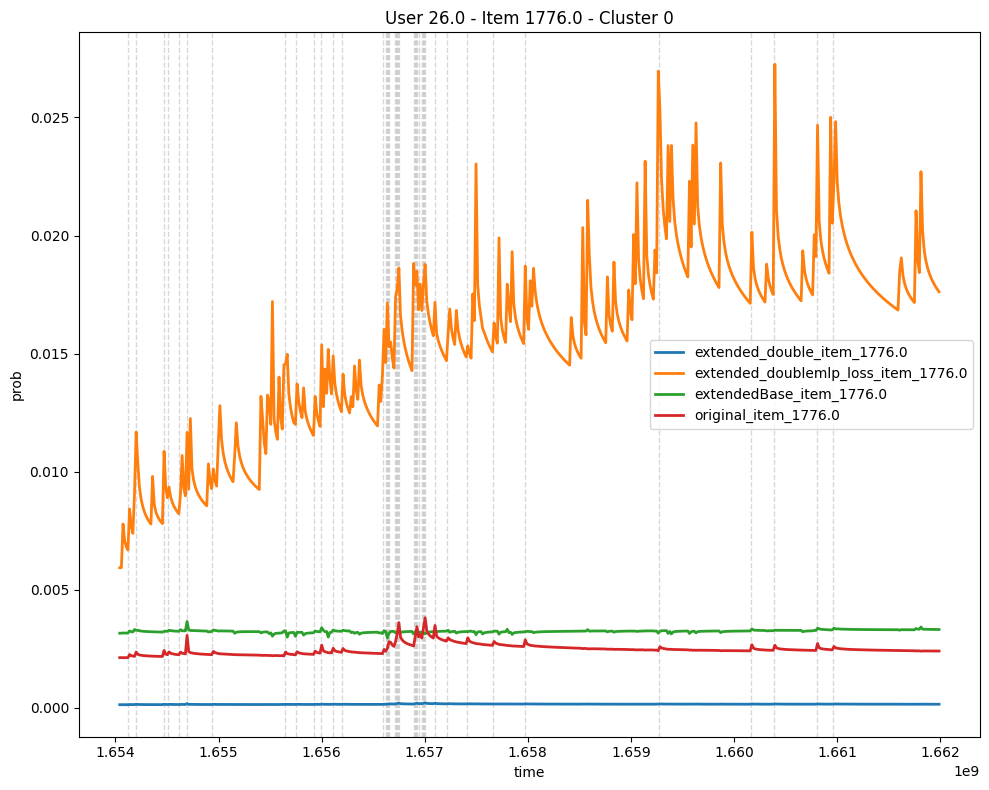

100%|██████████| 5/5 [00:00<00:00, 500.10it/s]


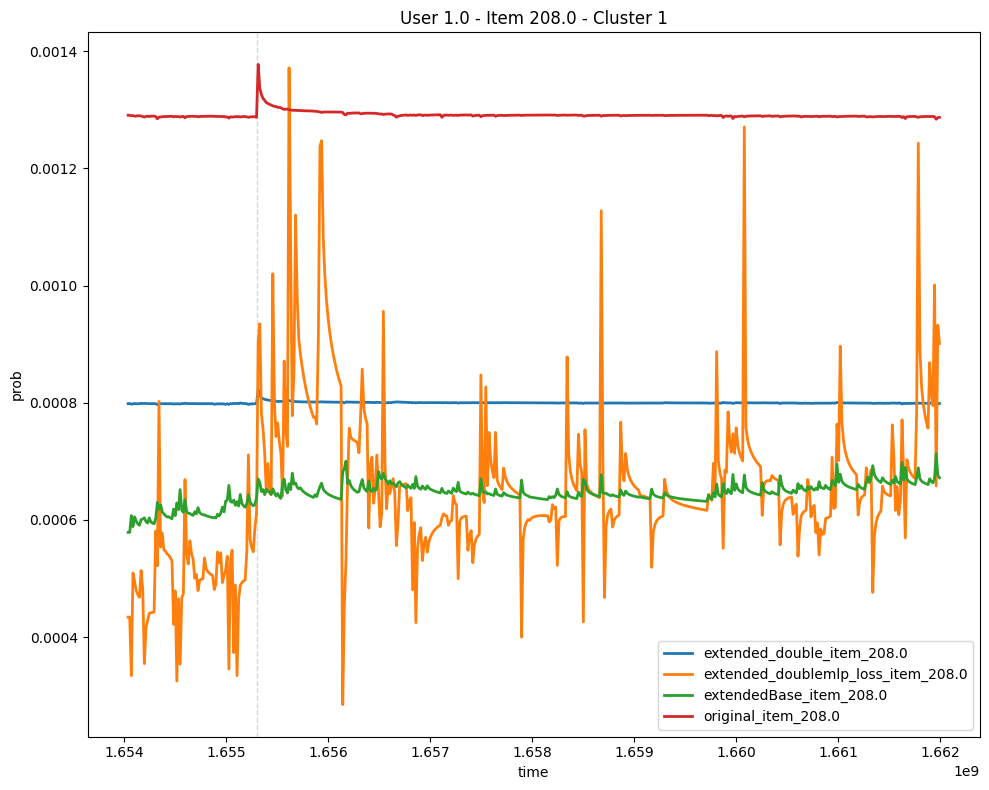

100%|██████████| 5/5 [00:00<00:00, 475.02it/s]


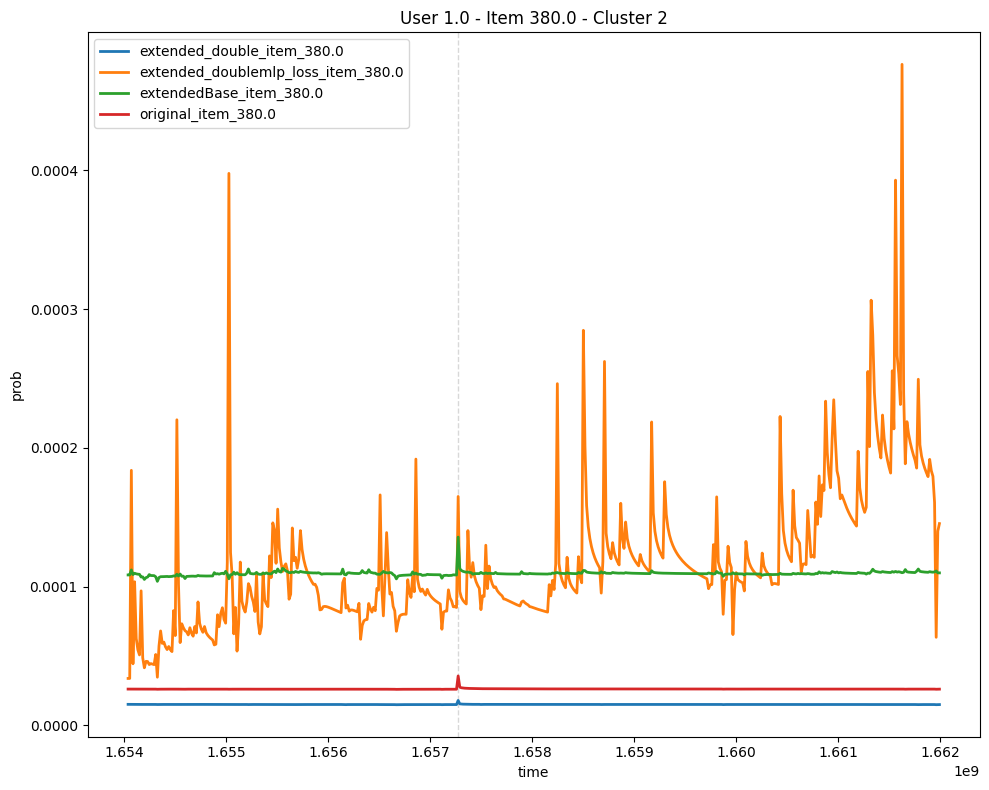

In [37]:
curve_index = 0

for c in range(3):
    tmp = al_df[al_df['cluster'] == c]

    user = tmp.iloc[curve_index, 0]
    item = tmp.iloc[curve_index, 1]


    show_for_user(
        data=data,
        user_id=user,
        item_id=item,
        show=["original", "extended_double", "extendedBase", "extended_doublemlp_loss"],
        curve_id="prob",
        cluster_id=c,
        df_full=df_full,
    )

In [38]:
for c in range(3):
    tmp = al_df[al_df['cluster'] == c]

    user = tmp.iloc[curve_index, 0]
    item = tmp.iloc[curve_index, 1]

In [39]:
slope_diffs = results['feature_df'].groupby('user')['extended_doublemlp_loss_score_slope'].apply(lambda x: max(x) - min(x))

In [40]:
slope_diffs.idxmax()

np.float64(804.0)

In [41]:
al_df[al_df['user'] == 804]['item']

1606     571.0
1607    2864.0
Name: item, dtype: float64

100%|██████████| 5/5 [00:00<00:00, 384.59it/s]


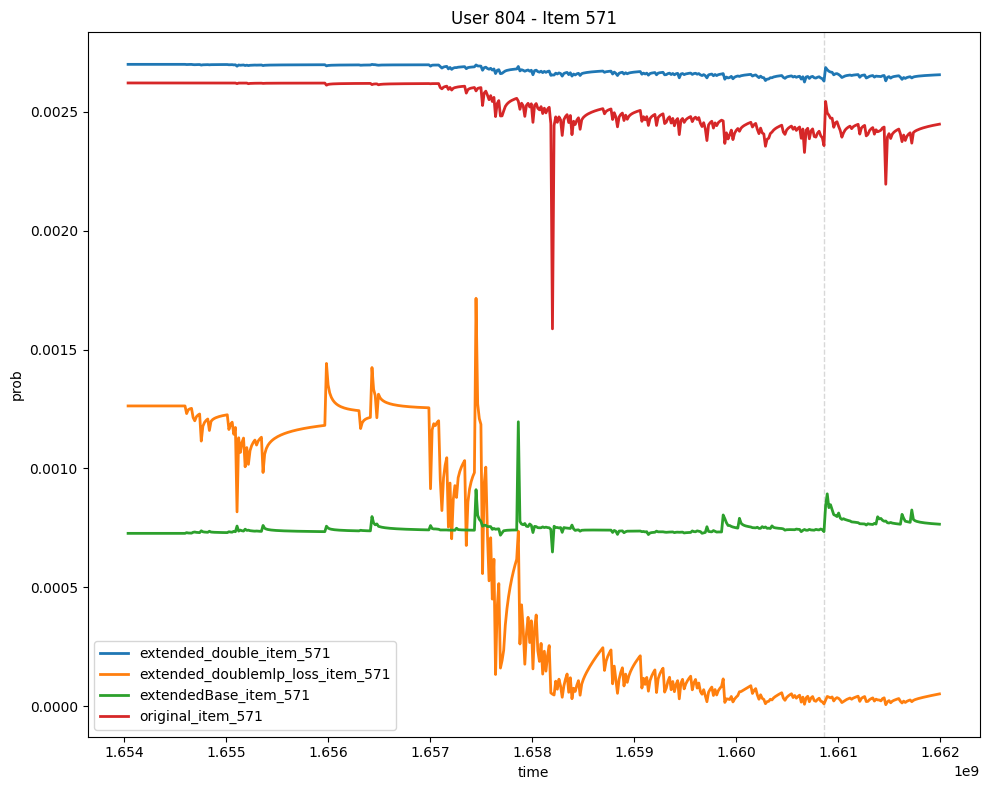

In [42]:
show_for_user(
        data=data,
        user_id=804,
        item_id=571,
        show=["original", "extended_double", "extendedBase", "extended_doublemlp_loss"],
        curve_id="prob",
        df_full=df_full,
    )

100%|██████████| 5/5 [00:00<00:00, 433.86it/s]


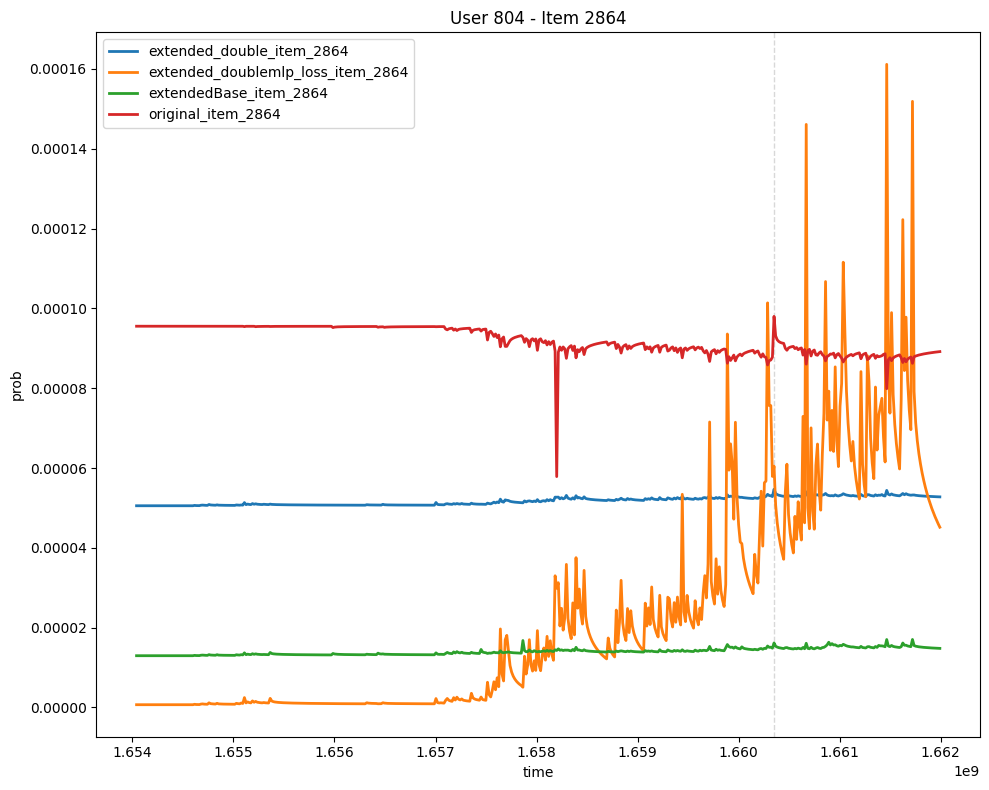

In [43]:
show_for_user(
        data=data,
        user_id=804,
        item_id=2864,
        show=["original", "extended_double", "extendedBase", "extended_doublemlp_loss"],
        curve_id="prob",
        df_full=df_full,
    )

In [44]:
from src.models.optimized.extendedMLDistLoss import Ex2VecExtendedMLP

weights = torch.load(r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\train_notebooks\weights\extended_doublemlp_loss\weights.pt', map_location='cpu', weights_only=False)

smooth = weights['model_state_dict']['smooth'].cpu().numpy()
force = weights['model_state_dict']['force'].cpu().numpy()

max_history = 3500
user_count = df_full['user_id'].max()
item_count = df_full['track_id'].max()

device = 'cpu'
config = {'n_users': user_count, 'n_items': item_count, 'latent_d': 64,
          'pretrained_embeddings_path': r'Z:/Skola/ING/Recommenders/repo/Ex2VecExtended/split_data/track_embeddings.parquet',
          'item_mapping': r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\split_data\item_mapping.json',
          'mlp_dist_conf': {
            'emb_dim': 128,
            'hidden_dims':[256, 128],
            'block_size':512,
            'activation':torch.nn.ReLU,
            'dropout':0.1,
            'positive_output':True
          }}


model = Ex2VecExtendedMLP(config)
model.load_state_dict(weights["model_state_dict"], strict=False)
model.to(device)

model.eval()
item_dist_matrix = model.metric(model.embedding_item_extension.weight).detach().cpu().numpy()

In [45]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def get_dist_weight(dist, s, f):
    return sigmoid(s / (1 + dist) - f * s) / sigmoid(s - f * s)

def get_weighted_dist(dist, s, f):
    return 1 / (1 + dist) * get_dist_weight(dist, s, f)

In [46]:
sim_matrix = get_weighted_dist(item_dist_matrix, smooth, force)
# sim_matrix = item_dist_matrix

In [47]:
sim_matrix[(sim_matrix != 1) & (sim_matrix > 1e-4)].min()

np.float32(0.00010000042)

In [48]:
x = np.linspace(0, 1e-2, 1000)

In [49]:
(0.2491 ** -0.5) * 5.6309

11.282126137063946

In [50]:
(0.2491 ** -0.5) * 0.001

0.002003609749252153

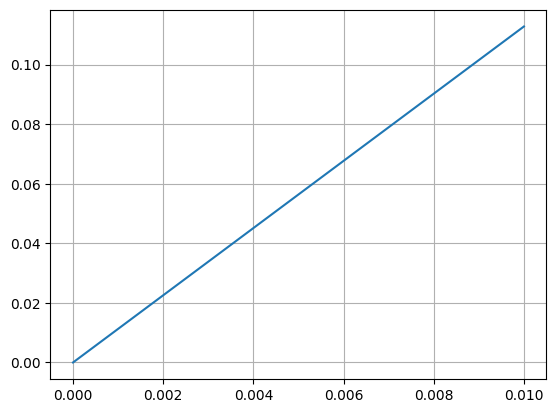

In [51]:
plt.plot(x, (0.2491 ** -0.5) * 5.6309 * x)
plt.grid()

In [52]:
weights['model_state_dict']['user_lamb.weight'].argmax()

tensor(10377)

In [53]:
10377

10377

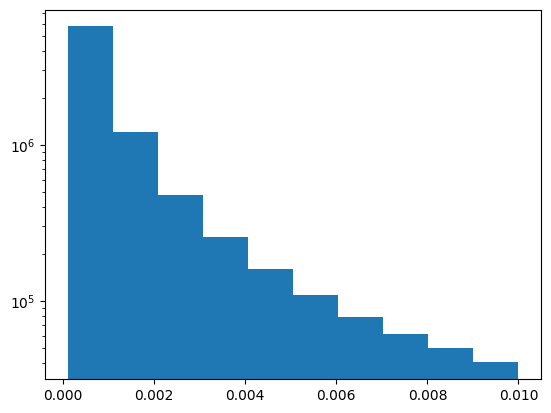

In [54]:
plt.hist(sim_matrix[(sim_matrix != 1) & (sim_matrix > 1e-4)], range=(1e-4, 0.01))
plt.yscale('log')

In [55]:
sim_matrix.shape

(3028, 3028)

In [56]:
df_full

,user_id,track_id,ts
0,1,1,1654072390
1,1,2,1654072708
2,1,3,1654072940
3,1,4,1654073406
4,1,5,1654073608
...,...,...,...
16658776,13209,373,1661709626
16658777,13209,437,1661710190
16658778,13209,1341,1661710386
16658779,13209,1047,1661710596


In [57]:
# user: 804
# items: 571, 2864

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
import datetime
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
import matplotlib.gridspec as gridspec


def plot_dual_interaction_impact(time_vals, probabilities, scores, time_sim, similarities,
                                 cmap='plasma', min_similarity=0.01, target_bins=80, save_path=None):
    """
    Plots two stacked time series with aligned widths, plus a fixed-range histogram
    of interaction similarities.

    Key behavior
    ------------
    - Histogram x-axis is always logarithmic and fixed to [1e-6, 1].
    - Histogram y-axis is logarithmic (counts per bin).
    - Color mapping is logarithmic and uses the same fixed range [1e-6, 1].
    - Similarity values below 1e-6 are clipped into the first histogram bin and
      mapped to the lowest colormap color.
    - Similarity values above 1 are clipped to 1 for coloring/histogram display.

    Notes
    -----
    The function interface is unchanged, so the default `min_similarity=0.01`
    still filters out values below 0.01. To visualize the full low-similarity
    range, call with:
        min_similarity=None
    or:
        min_similarity=0.0
    """

    # ==========================================
    # FIXED DISPLAY RANGES
    # ==========================================
    SIM_DISPLAY_MIN = 1e-4
    SIM_DISPLAY_MAX = 1.0

    # ==========================================
    # INPUT NORMALIZATION & VALIDATION
    # ==========================================
    time_vals = np.asarray(time_vals, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    scores = np.asarray(scores, dtype=float)
    time_sim = np.asarray(time_sim, dtype=float)
    similarities = np.asarray(similarities, dtype=float)

    for name, arr in (
        ("time_vals", time_vals),
        ("probabilities", probabilities),
        ("scores", scores),
        ("time_sim", time_sim),
        ("similarities", similarities),
    ):
        if arr.ndim != 1:
            raise ValueError(f"{name} must be a 1D array-like input.")

    if len(time_vals) == 0:
        raise ValueError("time_vals must not be empty.")

    if len(probabilities) != len(time_vals):
        raise ValueError("probabilities must have the same length as time_vals.")

    if len(scores) != len(time_vals):
        raise ValueError("scores must have the same length as time_vals.")

    if len(time_sim) != len(similarities):
        raise ValueError("time_sim and similarities must have the same length.")

    if not np.all(np.isfinite(time_vals)):
        raise ValueError("time_vals contains NaN or infinite values.")

    if not np.all(np.isfinite(probabilities)):
        raise ValueError("probabilities contains NaN or infinite values.")

    if not np.all(np.isfinite(scores)):
        raise ValueError("scores contains NaN or infinite values.")

    if len(time_sim) > 0:
        valid_interactions = np.isfinite(time_sim) & np.isfinite(similarities)
        dropped = np.count_nonzero(~valid_interactions)
        if dropped > 0:
            print(f"Warning: Dropped {dropped} interaction(s) with NaN/inf values.")
        time_sim = time_sim[valid_interactions]
        similarities = similarities[valid_interactions]

    if target_bins is None or int(target_bins) < 2:
        raise ValueError("target_bins must be an integer >= 2.")
    target_bins = int(target_bins)

    # ==========================================
    # SORT PRIMARY SERIES FOR PLOTTING / INTERPOLATION
    # ==========================================
    sort_main = np.argsort(time_vals)
    time_vals = time_vals[sort_main]
    probabilities = probabilities[sort_main]
    scores = scores[sort_main]

    def _prepare_interp_xy(x, y):
        unique_x, inverse, counts = np.unique(x, return_inverse=True, return_counts=True)
        if len(unique_x) == len(x):
            return x, y
        y_sum = np.bincount(inverse, weights=y)
        unique_y = y_sum / counts
        return unique_x, unique_y

    interp_time_prob, interp_prob = _prepare_interp_xy(time_vals, probabilities)
    interp_time_score, interp_score = _prepare_interp_xy(time_vals, scores)

    # ==========================================
    # FILTER & SORT INTERACTIONS
    # ==========================================
    if min_similarity is not None:
        mask = similarities >= min_similarity
        removed = np.count_nonzero(~mask)
        time_sim = time_sim[mask]
        similarities = similarities[mask]

        if len(similarities) == 0:
            print(f"Warning: No interactions >= {min_similarity}.")
        elif removed > 0 and min_similarity > 0:
            print(
                f"Note: {removed} interaction(s) below min_similarity={min_similarity} were excluded. "
                f"Set min_similarity=None or 0.0 to show the full low-similarity range."
            )

    if len(similarities) > 0:
        sort_interactions = np.argsort(similarities)
        time_sim = time_sim[sort_interactions]
        similarities = similarities[sort_interactions]

    # ==========================================
    # DATETIME CONVERSION
    # ==========================================
    dates_vals = [datetime.datetime.fromtimestamp(ts) for ts in time_vals]
    dates_sim = [datetime.datetime.fromtimestamp(ts) for ts in time_sim] if len(time_sim) > 0 else []

    # ==========================================
    # FIGURE SETUP
    # ==========================================
    fig = plt.figure(figsize=(14, 12), facecolor='white')
    gs = gridspec.GridSpec(
        3, 2,
        width_ratios=[40, 1],
        height_ratios=[3, 3, 1.8],
        wspace=0.02,
        hspace=0.28
    )

    ax_prob = fig.add_subplot(gs[0, 0])
    ax_cbar = fig.add_subplot(gs[0, 1])
    ax_score = fig.add_subplot(gs[1, 0], sharex=ax_prob)
    ax_hist = fig.add_subplot(gs[2, 0])

    # ==========================================
    # FIXED LOG COLOR NORMALIZATION
    # ==========================================
    cmap_obj = plt.get_cmap(cmap)
    color_norm = LogNorm(vmin=SIM_DISPLAY_MIN, vmax=SIM_DISPLAY_MAX, clip=True)

    if len(similarities) > 0:
        sim_for_color = np.clip(similarities, SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)
        event_colors = cmap_obj(color_norm(sim_for_color))
    else:
        event_colors = np.empty((0, 4))

    # ==========================================
    # AXIS LIMITS FOR TIME SERIES
    # ==========================================
    if len(dates_vals) == 1:
        delta = datetime.timedelta(seconds=1)
        xlim_left = dates_vals[0] - delta
        xlim_right = dates_vals[0] + delta
    else:
        xlim_left = dates_vals[0]
        xlim_right = dates_vals[-1]

    # ==========================================
    # TIME SERIES RENDERING
    # ==========================================
    def draw_curve(ax, y_vals, ylabel, interp_x, interp_y, title=None, show_x_labels=False):
        y_vals = np.asarray(y_vals, dtype=float)

        if len(y_vals) == 0:
            raise ValueError(f"{ylabel} series must not be empty.")

        if len(y_vals) != len(time_vals):
            raise ValueError(f"{ylabel} series must have the same length as time_vals.")

        y_min = np.min(y_vals)
        y_max = np.max(y_vals)
        y_range = y_max - y_min
        if y_range == 0:
            y_range = 1e-5

        ymin = y_min - (y_range * 0.10)
        ymax = y_max + (y_range * 0.15)

        ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

        ax.plot(
            dates_vals, y_vals,
            color='#151515',
            linewidth=2.5,
            alpha=1.0,
            path_effects=[pe.Stroke(linewidth=5.5, foreground='white'), pe.Normal()],
            zorder=4
        )

        if len(time_sim) > 0:
            rug_height = ymin + (y_range * 0.04)
            ax.vlines(
                x=dates_sim,
                ymin=ymin,
                ymax=rug_height,
                colors=event_colors,
                linewidth=2.5,
                alpha=0.35,
                linestyle='-',
                zorder=2
            )
            ax.axhline(y=rug_height, color='#dddddd', linewidth=1, zorder=1)

            in_range = (time_sim >= interp_x[0]) & (time_sim <= interp_x[-1])
            if np.any(in_range):
                valid_dates_sim = np.array(dates_sim, dtype=object)[in_range]
                valid_time_sim = time_sim[in_range]
                valid_event_colors = event_colors[in_range]

                curve_at_events = np.interp(valid_time_sim, interp_x, interp_y)

                ax.scatter(valid_dates_sim, curve_at_events, c='white', s=45, zorder=5)
                ax.scatter(
                    valid_dates_sim, curve_at_events,
                    c=valid_event_colors,
                    s=18,
                    alpha=0.95,
                    zorder=6
                )

        ax.set_xlim(xlim_left, xlim_right)
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color='#555555', labelpad=10)

        if title:
            ax.set_title(title, fontsize=16, fontweight='bold', pad=15, color='#222222')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#cccccc')
        ax.tick_params(axis='y', length=0, colors='#555555')

        if show_x_labels:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
            ax.tick_params(axis='x', colors='#555555', rotation=30)
            for label in ax.get_xticklabels():
                label.set_ha('right')
        else:
            ax.tick_params(axis='x', length=0, labelbottom=False)

    draw_curve(
        ax_prob,
        probabilities,
        ylabel="Predicted probability",
        interp_x=interp_time_prob,
        interp_y=interp_prob,
        title="Interaction Similarity vs. Probability and Score Over Time",
        show_x_labels=False
    )

    draw_curve(
        ax_score,
        scores,
        ylabel="Raw score",
        interp_x=interp_time_score,
        interp_y=interp_score,
        show_x_labels=True
    )
    ax_score.set_xlabel("Time", fontsize=11, fontweight='bold', color='#555555', labelpad=10)

    # ==========================================
    # COLORBAR
    # ==========================================
    sm = ScalarMappable(norm=color_norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cbar)
    cbar.set_label('Interaction similarity (log color scale)', fontsize=10, fontweight='bold', color='#555555')
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors='#555555', size=0)
    cbar.set_ticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())

    # ==========================================
    # FIXED-RANGE LOG HISTOGRAM
    # ==========================================
    clipped_low_count = 0
    clipped_high_count = 0

    ax_hist.set_xscale('log')
    ax_hist.set_yscale('log')
    ax_hist.set_xlim(SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)

    if len(similarities) > 0:
        sims_for_hist = np.asarray(similarities, dtype=float)

        clipped_low_count = int(np.count_nonzero(sims_for_hist < SIM_DISPLAY_MIN))
        clipped_high_count = int(np.count_nonzero(sims_for_hist > SIM_DISPLAY_MAX))

        sims_for_hist = np.clip(sims_for_hist, SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)

        bin_edges = np.logspace(
            np.log10(SIM_DISPLAY_MIN),
            np.log10(SIM_DISPLAY_MAX),
            target_bins + 1
        )

        counts, bins, patches = ax_hist.hist(
            sims_for_hist,
            bins=bin_edges,
            edgecolor='white',
            linewidth=0.35,
            zorder=3
        )

        bin_centers = np.sqrt(bins[:-1] * bins[1:])
        bin_centers = np.clip(bin_centers, SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)

        for center, patch in zip(bin_centers, patches):
            patch.set_facecolor(cmap_obj(color_norm(center)))
            patch.set_alpha(0.92)

        positive_counts = counts[counts > 0]
        if len(positive_counts) > 0:
            ymin_hist = max(np.min(positive_counts) * 0.8, 0.8)
            ymax_hist = np.max(positive_counts) * 1.25
            if ymax_hist <= ymin_hist:
                ymax_hist = ymin_hist * 10
            ax_hist.set_ylim(ymin_hist, ymax_hist)
        else:
            ax_hist.set_ylim(0.8, 10)

    else:
        ax_hist.set_ylim(0.8, 10)
        ax_hist.text(
            0.5, 0.5,
            "No interaction similarities to display",
            transform=ax_hist.transAxes,
            ha='center', va='center',
            fontsize=11, color='#666666'
        )

    # ==========================================
    # HISTOGRAM STYLING
    # ==========================================
    ax_hist.grid(axis='y', color='#eeeeee', linestyle='--', linewidth=1, zorder=0)
    ax_hist.grid(axis='x', color='#f3f3f3', linestyle=':', linewidth=0.8, zorder=0)

    ax_hist.xaxis.set_major_locator(LogLocator(base=10.0))
    ax_hist.xaxis.set_major_formatter(LogFormatterSciNotation())
    ax_hist.yaxis.set_major_locator(LogLocator(base=10.0))
    ax_hist.yaxis.set_major_formatter(LogFormatterSciNotation())

    ax_hist.set_xlabel(
        "Interaction similarity (log scale; fixed range 1e-4 to 1)",
        fontsize=11,
        fontweight='bold',
        color='#555555',
        labelpad=10
    )
    ax_hist.set_ylabel(
        "Interactions per similarity bin (log count scale)",
        fontsize=10,
        fontweight='bold',
        color='#555555',
        labelpad=10
    )

    clip_notes = []
    if clipped_low_count > 0:
        clip_notes.append(f"≤1e-4 folded into first bin: {clipped_low_count}")
    if clipped_high_count > 0:
        clip_notes.append(f"≥1 folded into last bin: {clipped_high_count}")

    if clip_notes:
        ax_hist.text(
            0.99, 0.96,
            "\n".join(clip_notes),
            transform=ax_hist.transAxes,
            ha='right', va='top',
            fontsize=9, color='#777777',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.88)
        )

    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.spines['left'].set_visible(False)
    ax_hist.spines['bottom'].set_color('#cccccc')
    ax_hist.tick_params(axis='both', length=0, colors='#555555')

    # ==========================================
    # OUTPUT
    # ==========================================
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [59]:
# weights['model_state_dict']['user_lamb.weight'][u]

NameError: name 'u' is not defined

user_lambda:       1.3978370428085327
user_change_slope: 2.800719738006592


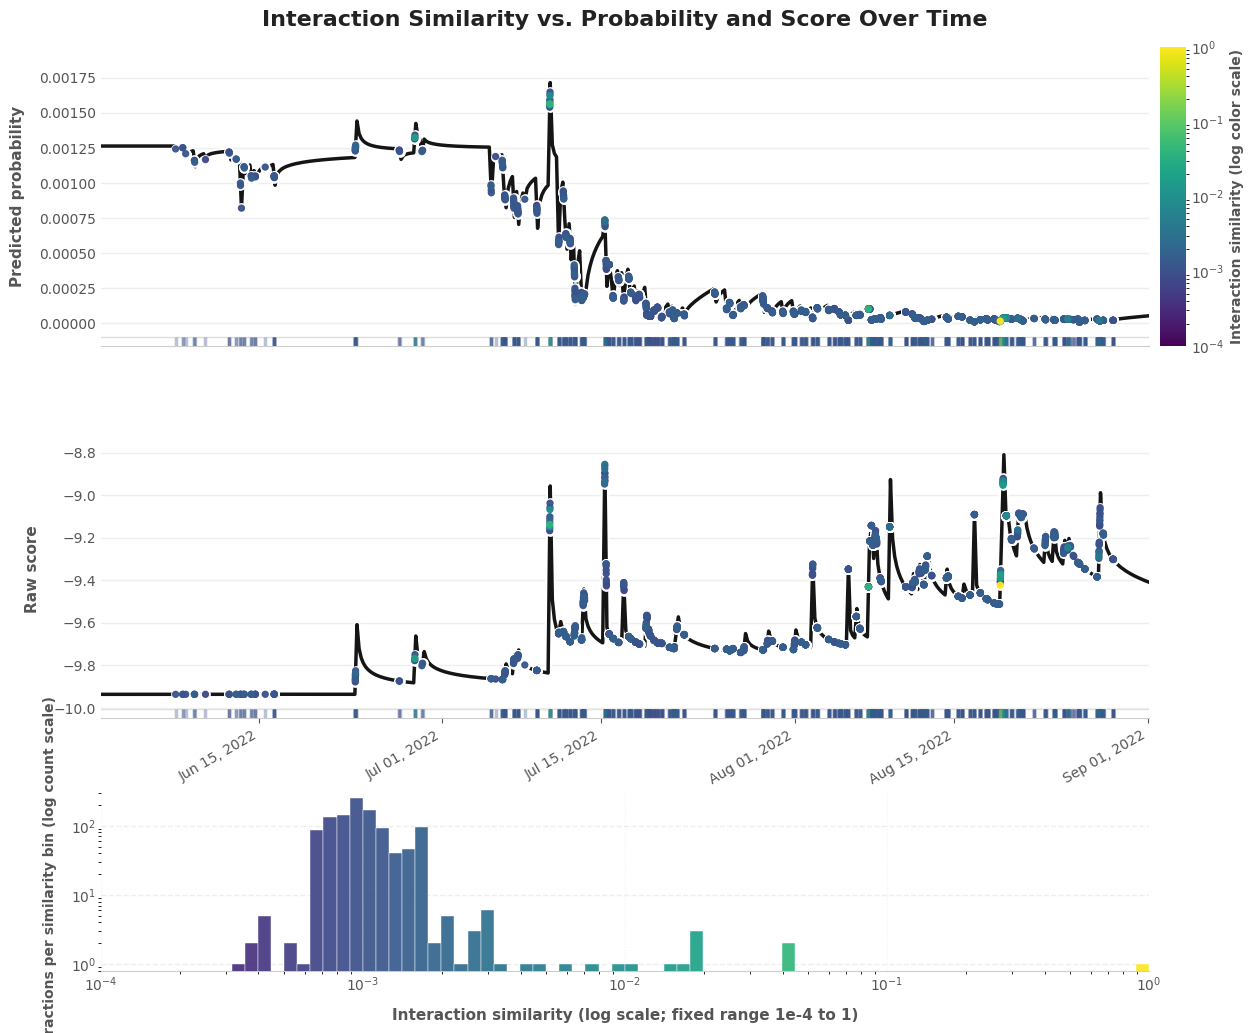

In [60]:
import copy

u = 804
i = 571

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")


items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       1.3978370428085327
user_change_slope: 2.800719738006592


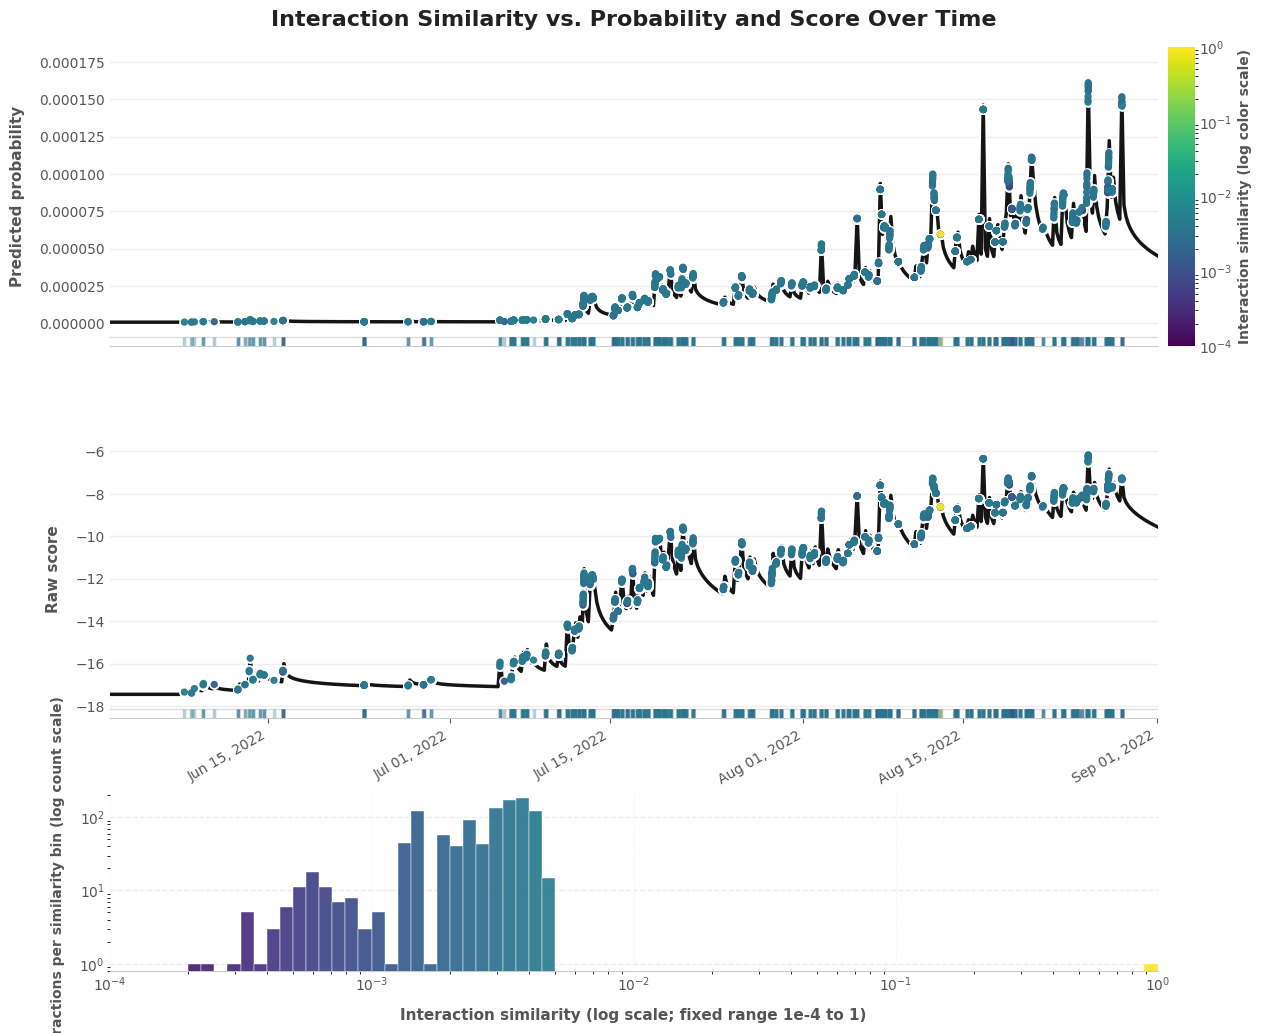

In [61]:
import copy

u = 804
i = 2864

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

In [62]:
slope_diffs = results['feature_df'].groupby('user')['extended_doublemlp_loss_score_slope'].apply(lambda x: max(x) - min(x))

In [63]:
slopes_items = results['feature_df'].groupby(['user']).agg(
                slope=('extended_doublemlp_loss_score_slope', lambda x: max(x) - min(x)),
                items=('item', list)
            )
slopes_items = slopes_items.sort_values('slope', ascending=False)

In [64]:
slopes_items

,slope,items
user,,
804.0,2286.774695,"[571.0, 2864.0]"
10377.0,1722.167701,"[933.0, 2165.0]"
13201.0,1496.204082,"[985.0, 1047.0]"
9308.0,1481.570415,"[1640.0, 2953.0]"
2653.0,1457.564830,"[57.0, 950.0]"
...,...,...
10216.0,0.065007,"[828.0, 953.0]"
10326.0,0.051478,"[449.0, 985.0]"
3822.0,0.038225,"[2863.0, 2895.0]"


user_lambda:       1.8922302722930908
user_change_slope: 3.791290760040283


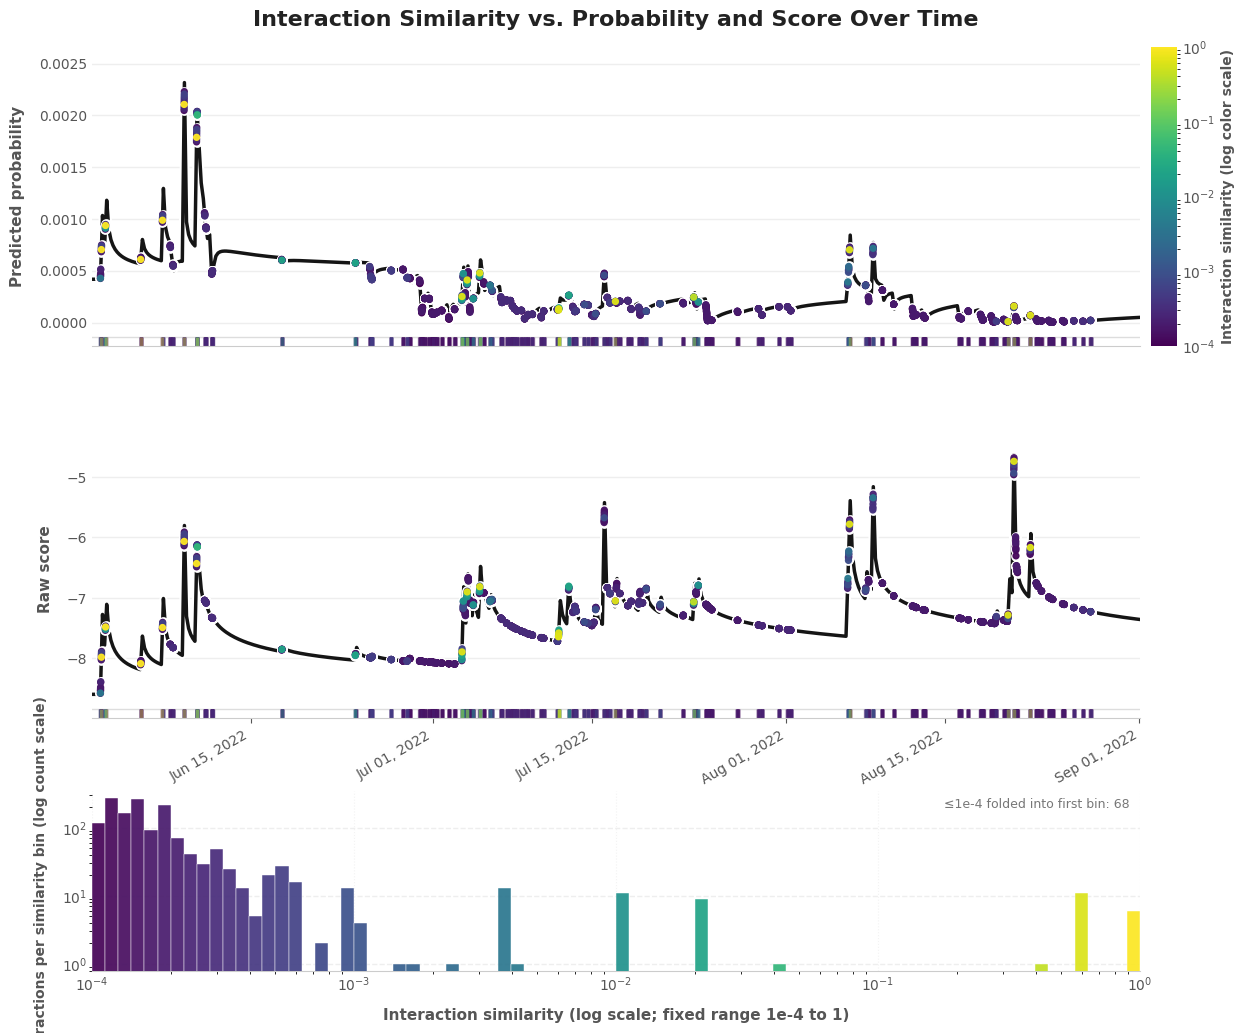

In [65]:
import copy

u = 13201
i = 985

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       1.8922302722930908
user_change_slope: 3.791290760040283


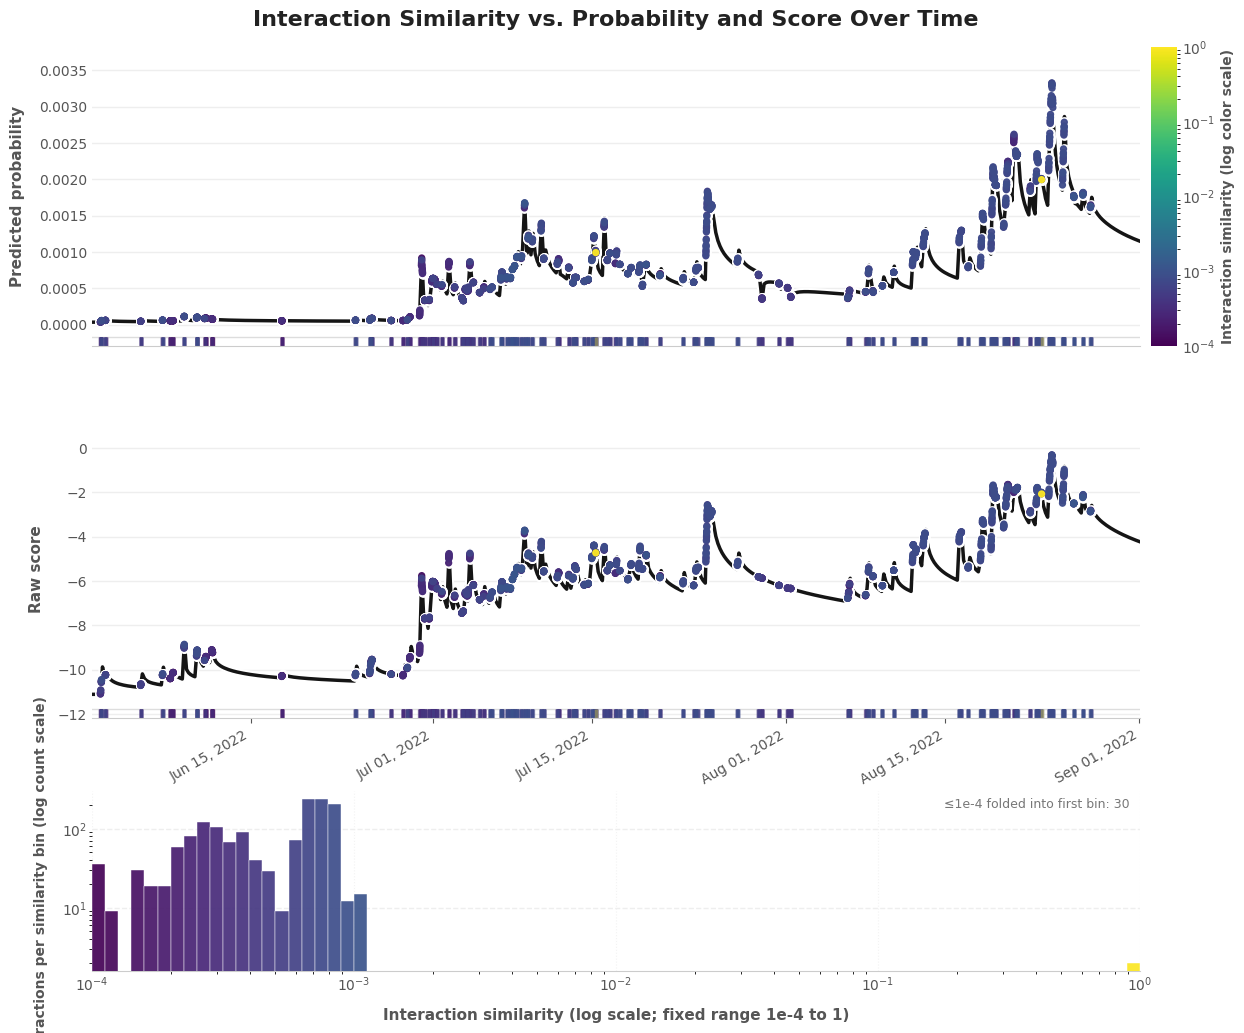

In [66]:
import copy

u = 13201
i = 1047

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       1.3978370428085327
user_change_slope: 2.800719738006592


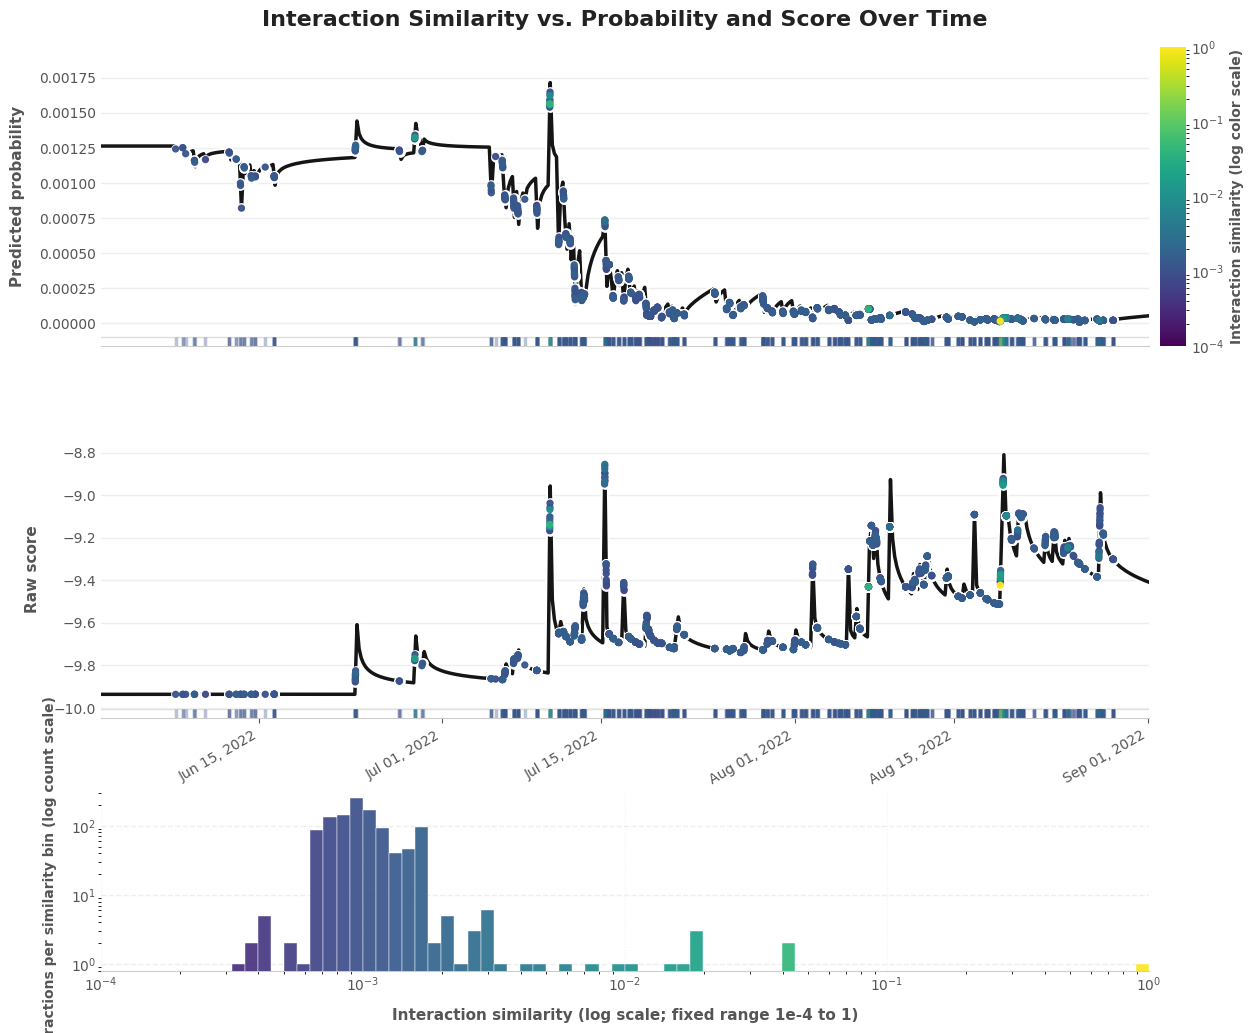

In [67]:
import copy

u = 804
i = 571

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       1.3978370428085327
user_change_slope: 2.800719738006592


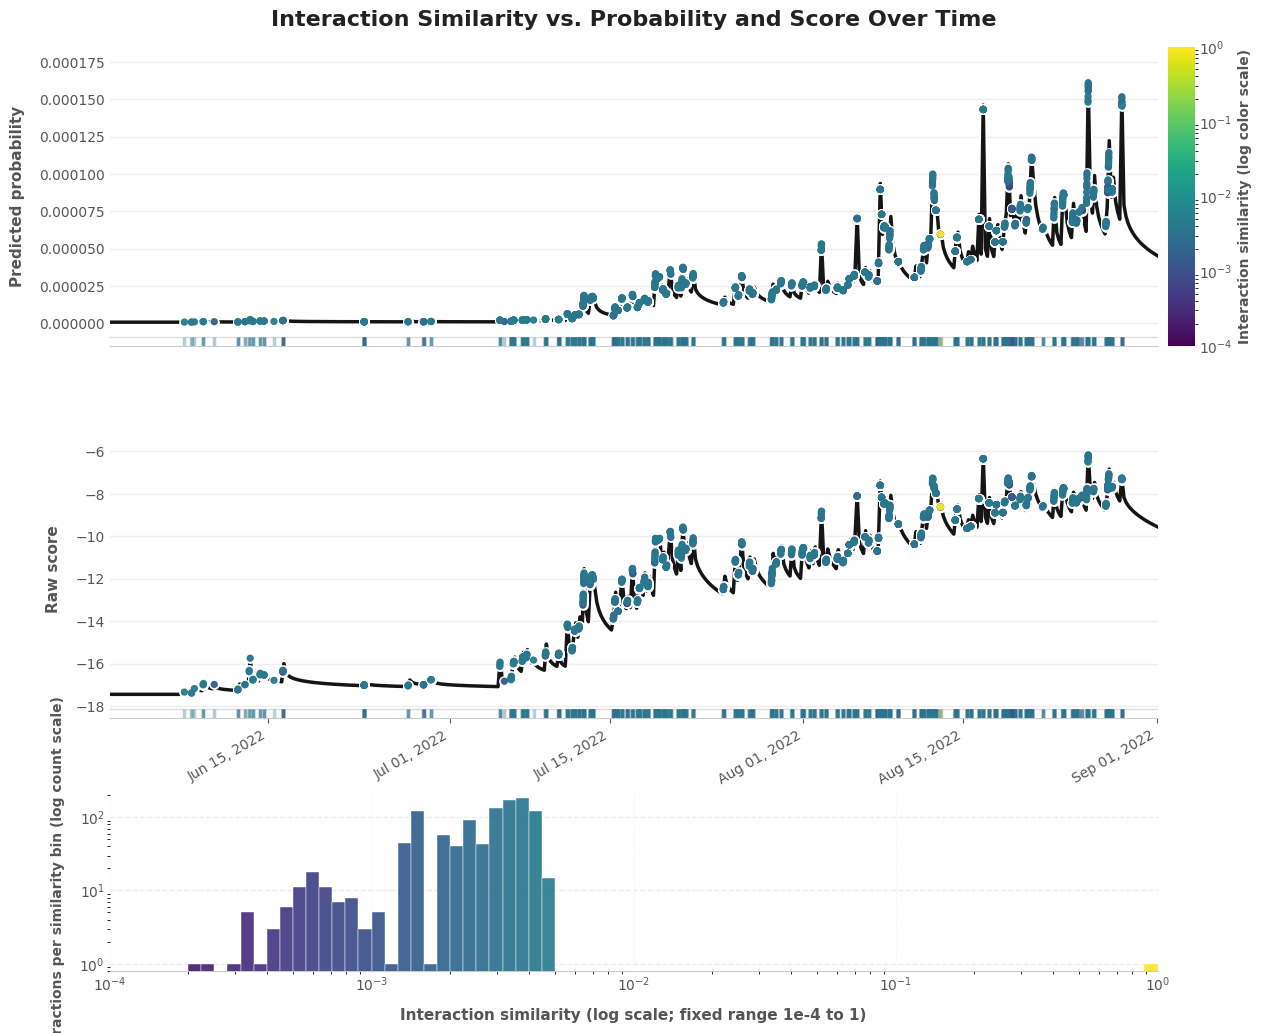

In [68]:
import copy

u = 804
i = 2864

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       0.001
user_change_slope: 0.002003609749252153


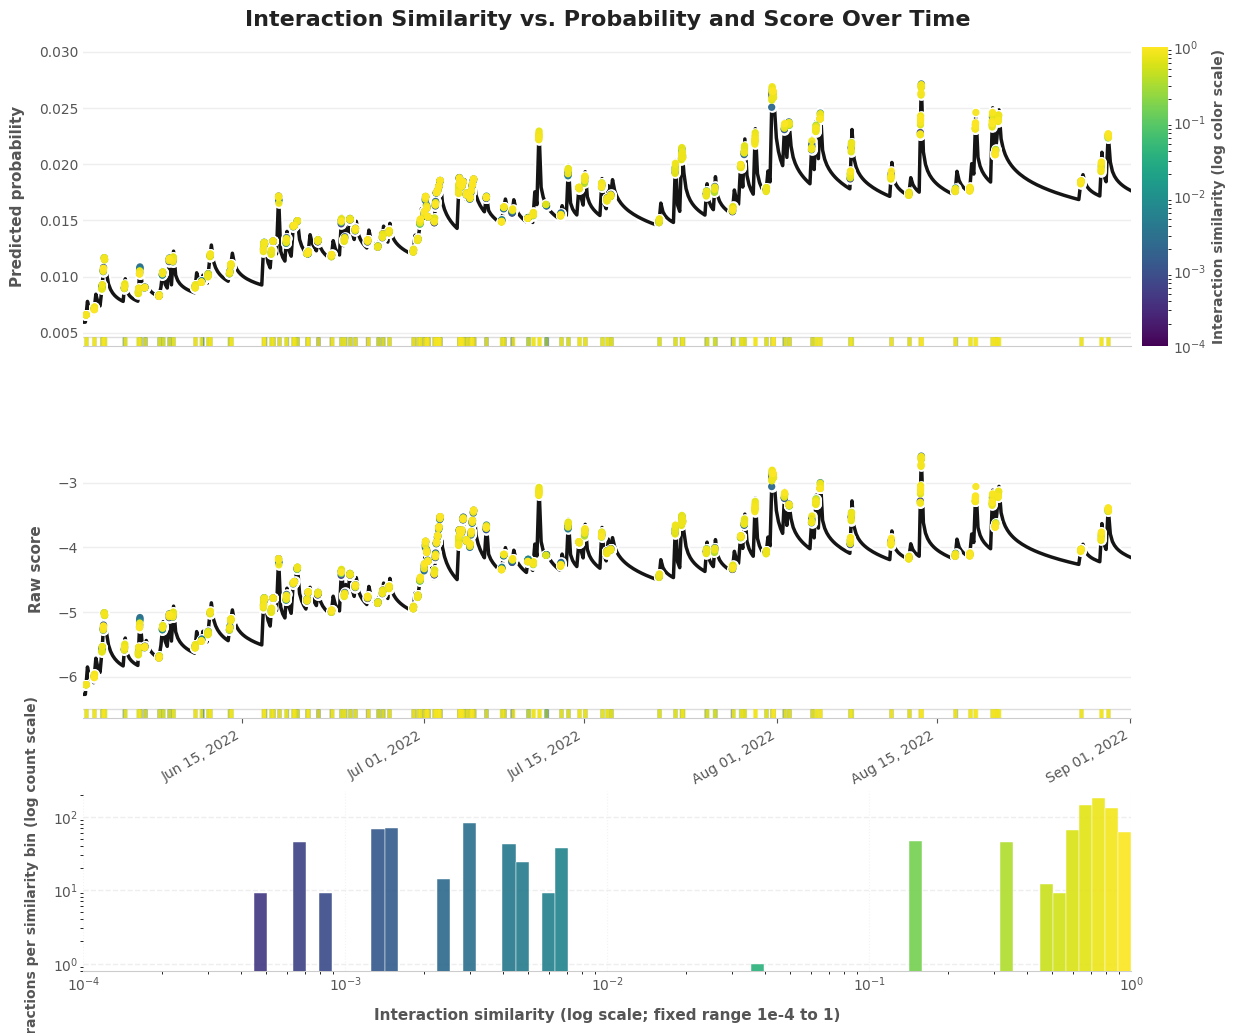

In [69]:
import copy

u = 26
i = 1776

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       0.4615156948566437
user_change_slope: 0.9246972799301147


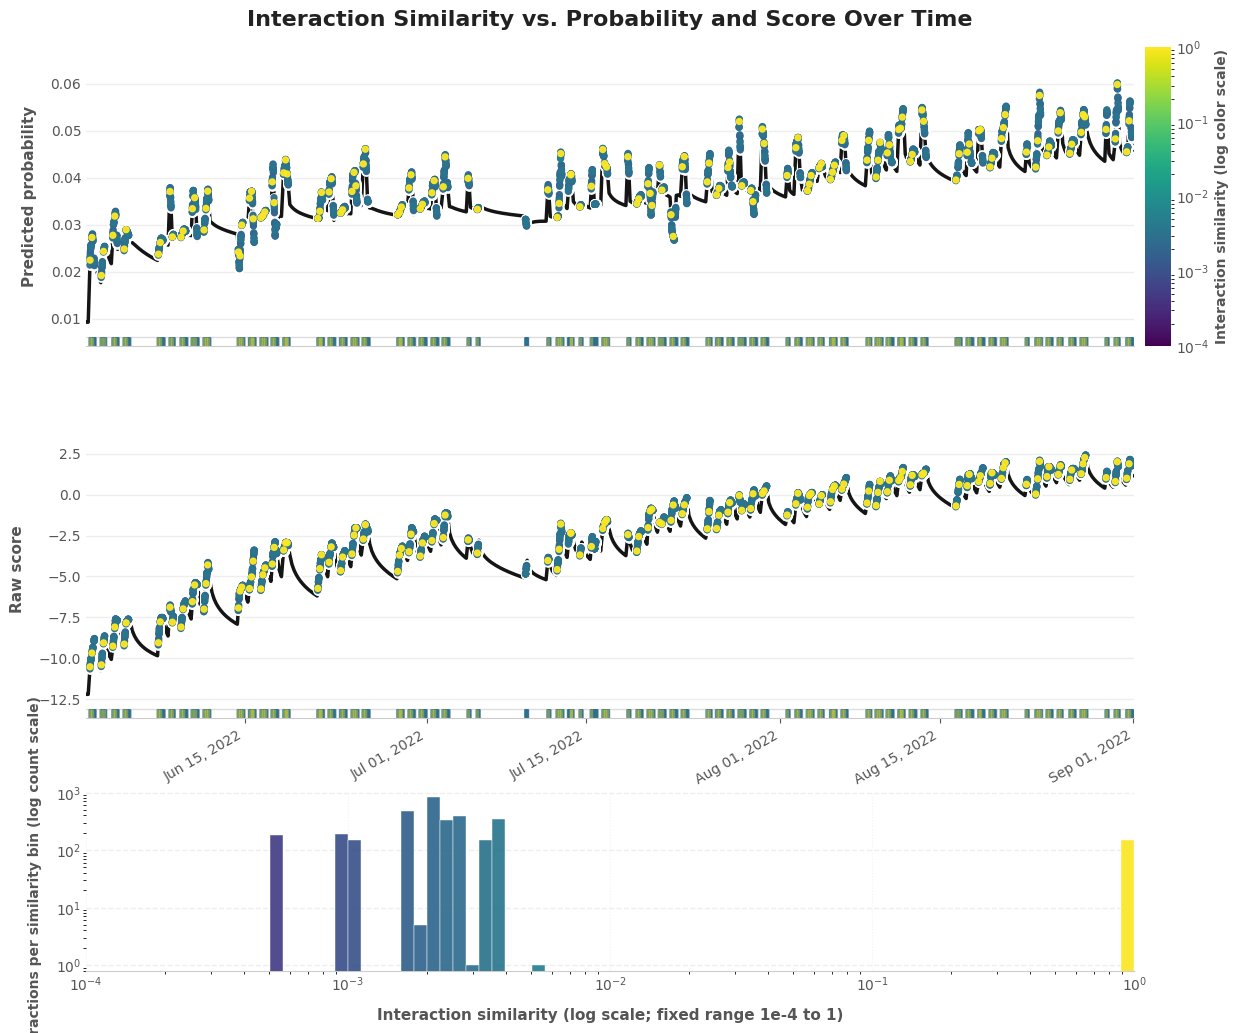

In [70]:
import copy

u = 5812
i = 248

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       3.332132577896118
user_change_slope: 6.676292896270752


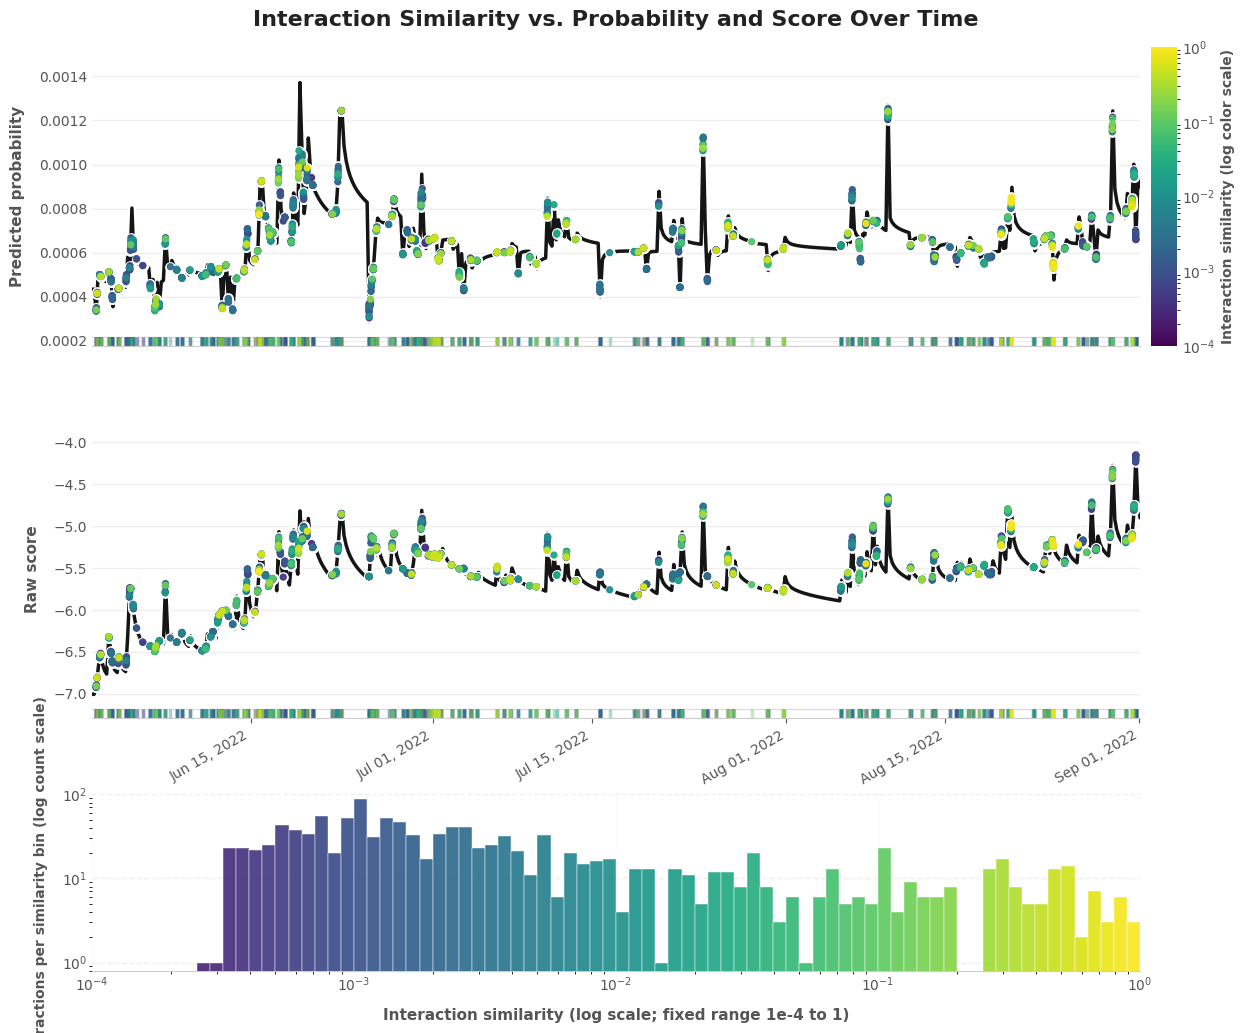

In [71]:
import copy

u = 1
i = 208

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

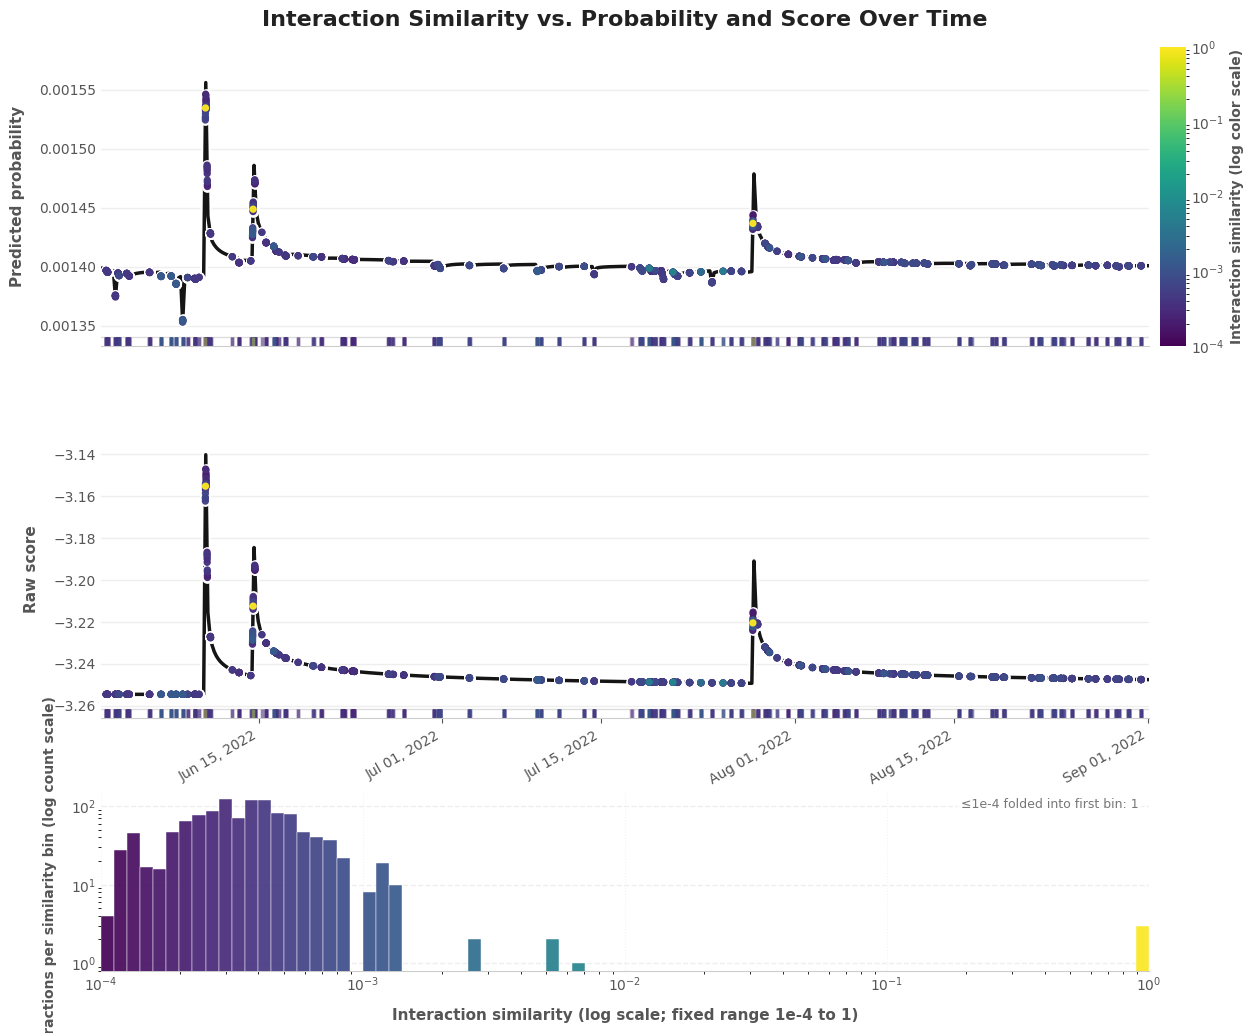

In [72]:
import copy

u = 10377
i = 933

# print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
# print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['original'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       5.630908966064453
user_change_slope: 11.282143592834473


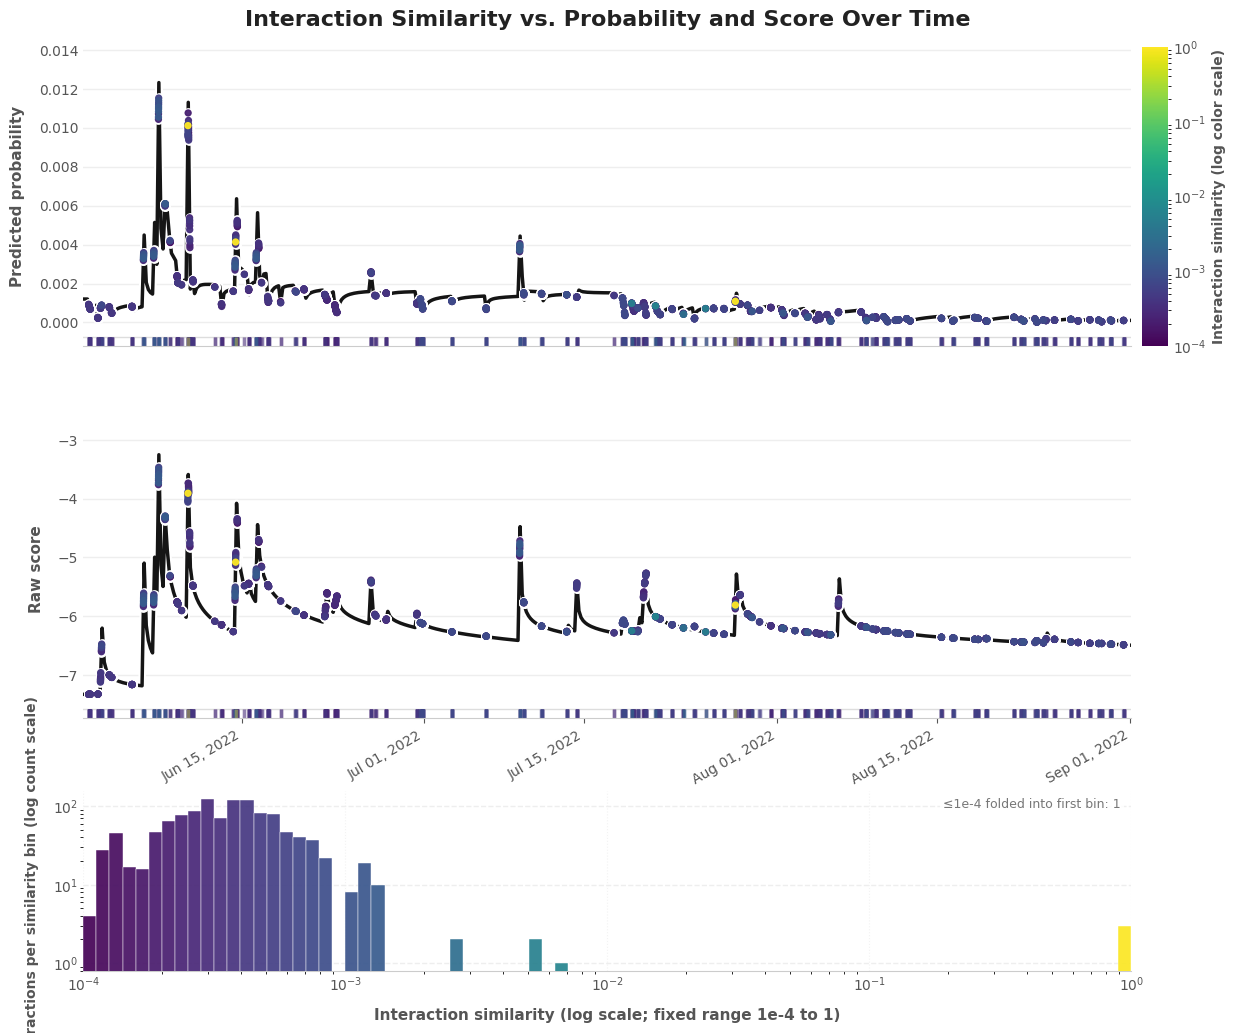

In [73]:
import copy

u = 10377
i = 933

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

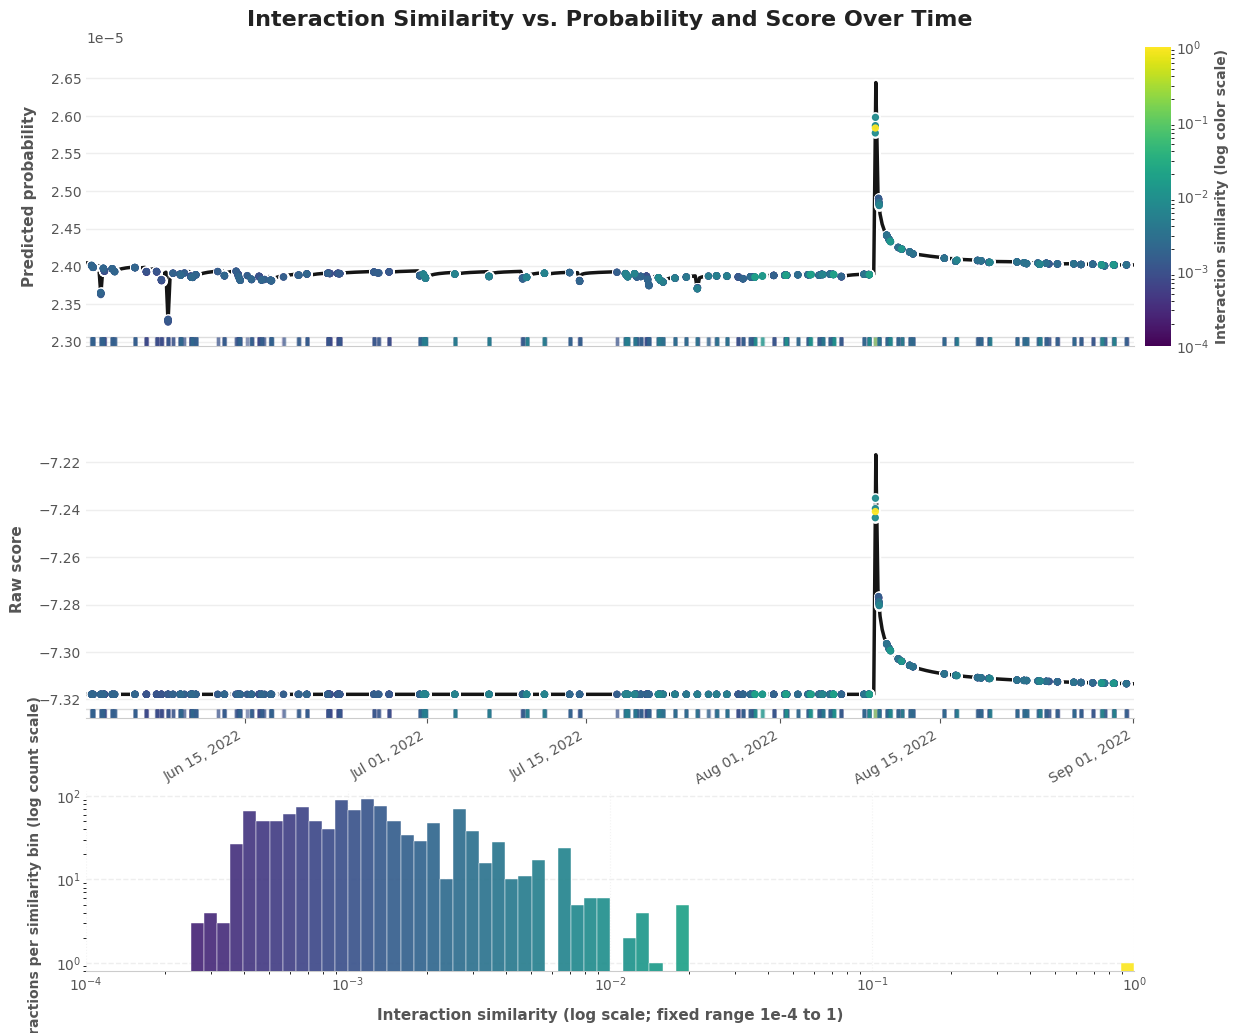

In [74]:
import copy

u = 10377
i = 2165

# print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
# print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['original'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       5.630908966064453
user_change_slope: 11.282143592834473


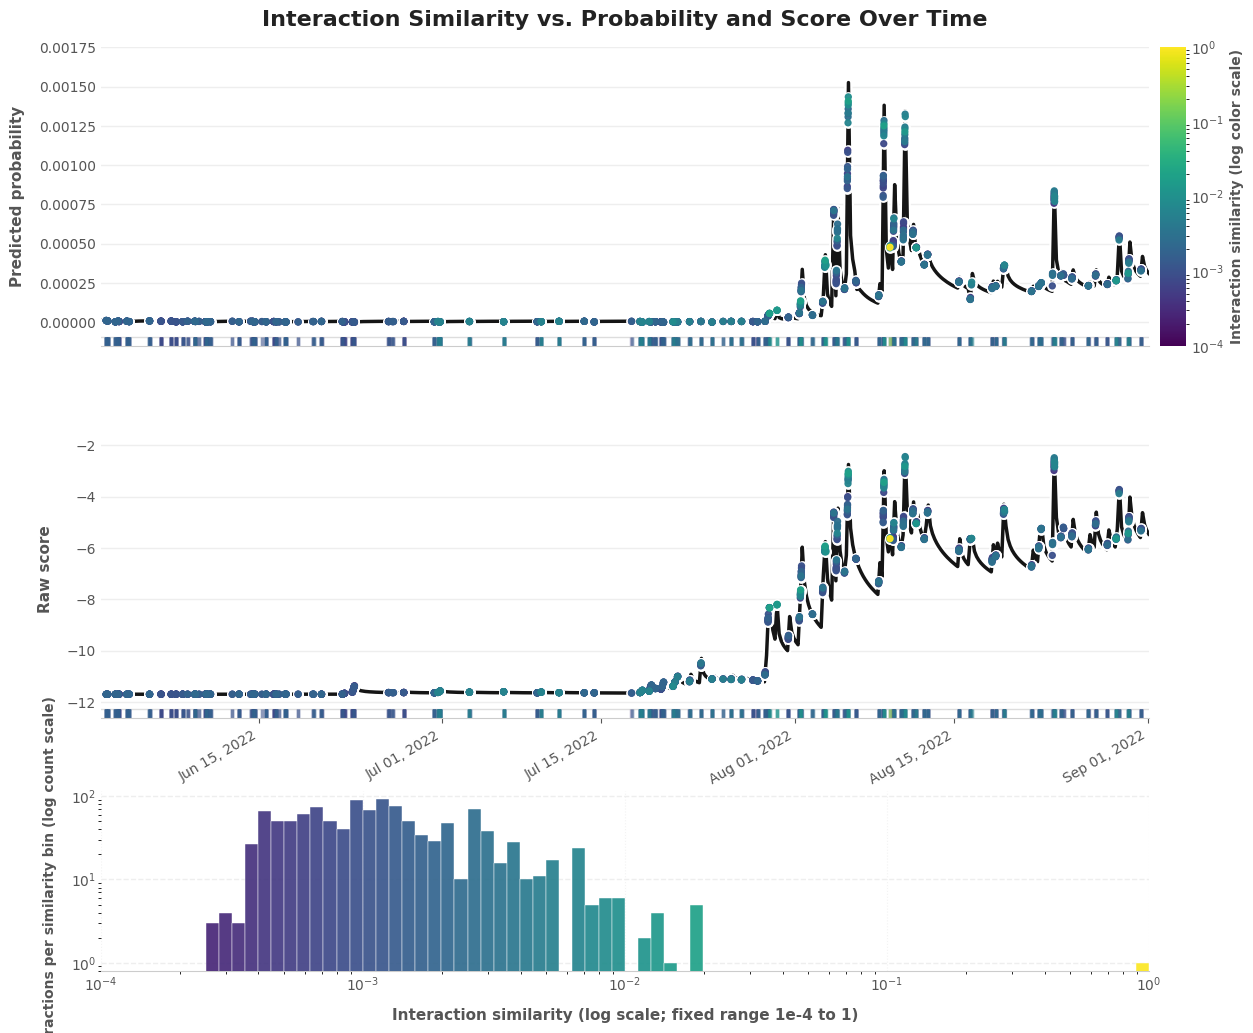

In [75]:
import copy

u = 10377
i = 2165

print(f"user_lambda:       {weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")
print(f"user_change_slope: {(0.2491 ** -0.5) * weights['model_state_dict']['user_lamb.weight'][u].numpy()[0]}")



items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(data['extended_doublemlp_loss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

In [76]:
df = copy.deepcopy(data['extended_doublemlp_loss'])

In [77]:
df[df['user']==10377]

,user,item,score,prob,model
20752,10377.0,933.0,"[-7.3285441398620605, -7.3285441398620605, -7....","[0.001203179475851357, 0.001203179475851357, 0...",extended_doublemlp_loss
20753,10377.0,2165.0,"[-11.70553207397461, -11.70553207397461, -11.7...","[1.51157164509641e-05, 1.51157164509641e-05, 1...",extended_doublemlp_loss
